In [1]:
import pickle   
import numpy as np
import matplotlib.pyplot as plt


## Loading data

In [2]:
atttention_file_path = 'open_rfcrate_box_results/ablation_widar3G6_rfcrate_vanilla_rf_crate_small_0116105758_indomain_results.pkl'
with open(atttention_file_path, 'rb') as handle:
    attentions_results = pickle.load(handle)
print(attentions_results.keys())

dict_keys(['input', 'attentions', 'qkv', 'feature', 'label', 'attr'])


In [3]:
heads = 12 # the number of heads in the attention layer

inputs = attentions_results['input']  # (384, 90, 256, 121)  # (num_sample, links*subcarriers, time_bins, frequency_bins)
print('inputs.shape', inputs.shape)
attentions = attentions_results['attentions']  # (384, 33, 576) # (num_sample, patch_index (CLS, ...), num_heads * dim)
print('attentions.shape', attentions.shape)
attentions = attentions.reshape(384, 33, heads, -1)  # (384, 33, 12, 48)
attentions_CLS = attentions[:, 0, :, :]  # (384, 12, 48)
attentions = attentions[:, 1:, :, :]  # (384, 32, 12, 48)
print('attentions_CLS.shape', attentions_CLS.shape)
print('attentions.shape', attentions.shape)
qkv = attentions_results['qkv'] # (12, 32, 32, 576) # Shape: [num_batch, batch_size, patch_index, num_heads* dim]
num_batch, batch_size, patch_index, num_heads_dim = qkv.shape
qkv = qkv.reshape(num_batch * batch_size, patch_index, num_heads_dim)  # (736, 32, 576)
qkv = qkv.reshape(num_batch * batch_size, patch_index, heads, -1)  # (736, 32, 12, 48)f
print('qkv.shape', qkv.shape)
feature = attentions_results['feature']  # (384, 33, 576) # (num_sample, patch_index (CLS, ...), num_heads * dim)
print('feature.shape', feature.shape)
num_sample, patch_index, num_heads_dim = feature.shape
feature = feature.reshape(num_sample, patch_index, heads, -1)  # (384, 33, 12, 48)
feature_CLS = feature[:, 0, :, :]  # (384, 12, 48)
feature = feature[:, 1:, :, :]  # (384, 32, 12, 48)
print('feature_CLS.shape', feature_CLS.shape)
print('feature.shape', feature.shape)
labels = attentions_results['label']   # (384,) # (num_sample) 
print('labels.shape', labels.shape)
raw_attr = attentions_results['attr']
B3, bs = raw_attr.shape
B = B3 // 3
attr = raw_attr.reshape(B, 3, bs).transpose(1, 0, 2).reshape(3, -1)
print('attr.shape', attr.shape)



inputs.shape (384, 90, 256, 121)
attentions.shape (384, 33, 576)
attentions_CLS.shape (384, 12, 48)
attentions.shape (384, 32, 12, 48)
qkv.shape (384, 32, 12, 48)
feature.shape (384, 33, 576)
feature_CLS.shape (384, 12, 48)
feature.shape (384, 32, 12, 48)
labels.shape (384,)
attr.shape (3, 384)


## Feature distibution cross gestures

In [5]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

try:
    from Datasets.widar3 import SORTED_GES_LIST
except Exception:
    SORTED_GES_LIST = [
        'Slide', 'Push&Pull', 'Clap', 'Sweep',
        'Draw-Zigzag', 'Draw-O'
    ]

# Label-to-gesture decoding for Widar3G6-style setup (default start index 0)
gesture_start_idx = 0
unique_labels = np.sort(np.unique(labels.astype(int)))
label_to_gesture_name = {
    int(lbl): SORTED_GES_LIST[gesture_start_idx + i] if (gesture_start_idx + i) < len(SORTED_GES_LIST) else f'class_{int(lbl)}'
    for i, lbl in enumerate(unique_labels)
}

class_counts = pd.Series(labels.astype(int)).value_counts().sort_index()
class_balance_df = pd.DataFrame({
    'label': class_counts.index.astype(int),
    'gesture': [label_to_gesture_name[int(lbl)] for lbl in class_counts.index],
    'sample_count': class_counts.values,
})
class_balance_df['ratio'] = class_balance_df['sample_count'] / class_balance_df['sample_count'].sum()

print('Label to gesture mapping:')
print(label_to_gesture_name)
print('\nClass balance:')
print(class_balance_df)

class_names_ordered = [label_to_gesture_name[int(lbl)] for lbl in unique_labels]


user_id_list = attr[0,:]
user_id_set = set(user_id_list)
orientation_list = attr[1,:]
orientation_set = set(orientation_list)
rx_list = attr[2,:]
rx_set = set(rx_list)

print(len(user_id_set))
print(len(orientation_set))
print(len(rx_set))

print(user_id_set)
print(orientation_set)
print(rx_set)



Label to gesture mapping:
{0: 'Slide', 1: 'Push&Pull', 2: 'Clap', 3: 'Sweep', 4: 'Draw-Zigzag(Horizontal)', 5: 'Draw-O(Horizontal)'}

Class balance:
   label                  gesture  sample_count     ratio
0      0                    Slide            58  0.151042
1      1                Push&Pull            67  0.174479
2      2                     Clap            59  0.153646
3      3                    Sweep            65  0.169271
4      4  Draw-Zigzag(Horizontal)            68  0.177083
5      5       Draw-O(Horizontal)            67  0.174479
4
5
6
{8, 9, 3, 7}
{1, 2, 3, 4, 5}
{1, 2, 3, 4, 5, 6}


#### CLS feature distribution cross gestures

In [7]:
from sklearn.manifold import TSNE
import torch
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
from matplotlib.patches import Ellipse

def normalize_safe(x):
    x = np.asarray(x)
    x_min = np.min(x)
    x_max = np.max(x)
    if np.isclose(x_max - x_min, 0):
        return np.zeros_like(x, dtype=np.float64)
    return (x - x_min) / (x_max - x_min)



def add_confidence_ellipse(ax, x, y, n_std=2.0, edgecolor='k', facecolor='none', alpha=0.18, lw=2):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    if np.linalg.det(cov) <= 0:
        return
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    center = (np.mean(x), np.mean(y))
    ell = Ellipse(center, width, height, angle=theta,
                  edgecolor=edgecolor, facecolor=facecolor,
                  alpha=alpha, lw=lw)
    ax.add_patch(ell)


def robust_cov_ellipse_params(x, y, n_std=2.0, q=0.90, reg=1e-6):
    """
    Fit ellipse after trimming outliers by Mahalanobis distance.
    q: keep central q fraction (e.g., 0.85~0.95)
    """
    pts = np.column_stack([x, y])
    if pts.shape[0] < 5:
        return None
    # Initial robust-ish center (median)
    center = np.median(pts, axis=0)
    # Initial covariance from all points (regularized)
    cov = np.cov((pts - center).T) + reg * np.eye(2)
    inv_cov = np.linalg.inv(cov)
    # Mahalanobis distance^2
    d2 = np.einsum('ni,ij,nj->n', pts - center, inv_cov, pts - center)
    # Keep central q points
    thr = np.quantile(d2, q)
    inliers = pts[d2 <= thr]
    if inliers.shape[0] < 5:
        return None
    # Refit on inliers
    center = inliers.mean(axis=0)
    cov = np.cov((inliers - center).T) + reg * np.eye(2)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    vx, vy = vecs[:, 0]
    theta = np.degrees(np.arctan2(vy, vx))
    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])
    return center, width, height, theta, inliers
def add_robust_ellipse(ax, x, y, color, n_std=2.0, q=0.90, alpha=0.14, lw=2):
    out = robust_cov_ellipse_params(x, y, n_std=n_std, q=q)
    if out is None:
        return
    center, width, height, theta, inliers = out
    ell = Ellipse(
        xy=center, width=width, height=height, angle=theta,
        edgecolor=color, facecolor=color, alpha=alpha, lw=lw
    )
    ax.add_patch(ell)

(384, 12, 48)
X.shape:  (384, 576)
tsne_perplexity:  30


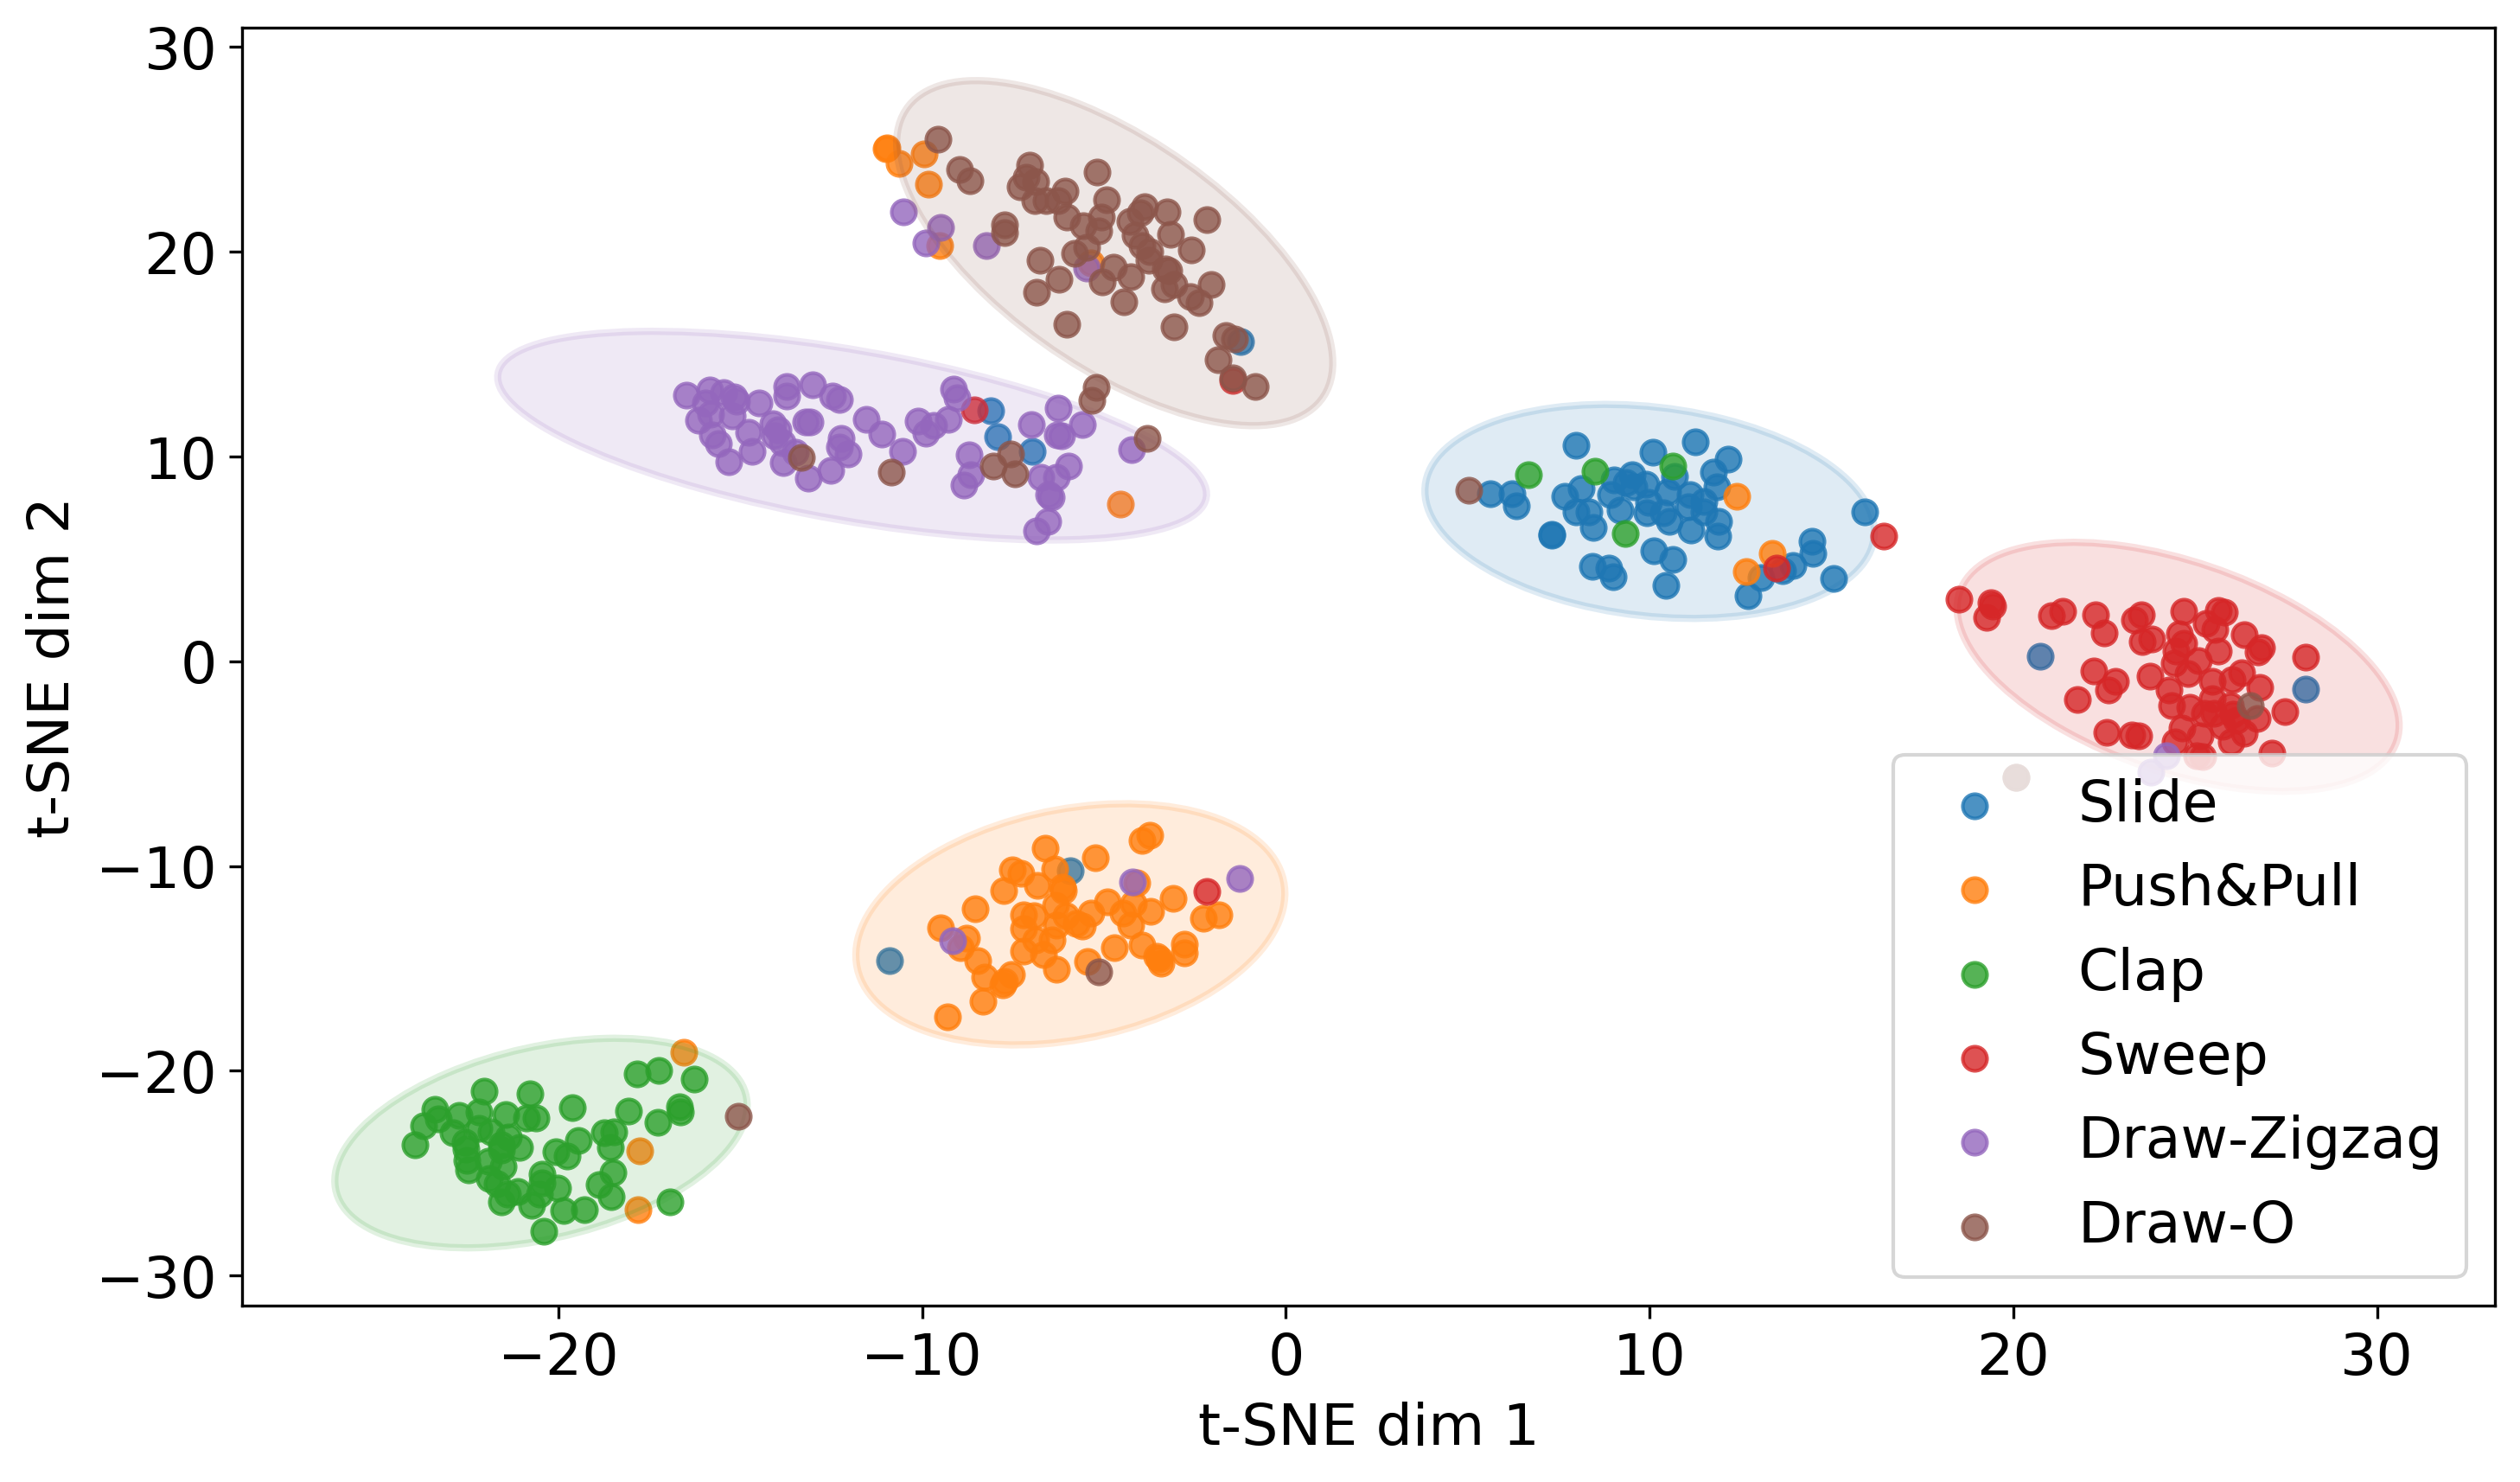

In [ ]:


y = labels.astype(int)
feature_selected = feature_CLS[:, :, :]
print(feature_selected.shape)

X = []
for i in range(feature_selected.shape[0]):
    feature_sample = feature_selected[i, :, :]  # (head, dim)
    feature_sample = feature_sample.reshape(-1)
    X.append(normalize_safe(feature_sample.real))

X = np.asarray(X)
num_classes = len(unique_labels)
num_heads = X.shape[1]


print("X.shape: ", X.shape)
tsne_perplexity = min(30, max(5, X.shape[0] // 10))
print("tsne_perplexity: ", tsne_perplexity)
tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    early_exaggeration=32,    # sweep this
    learning_rate=200,
    n_iter=4000,
    init='pca',
    random_state=42,
)
X_tsne = tsne.fit_transform(X)

# set fontsize
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
for cls in unique_labels:
    idx = y == cls
    color = None  # let matplotlib choose
    sc = ax.scatter(X_tsne[idx, 0], X_tsne[idx, 1], alpha=0.8, s=45,
                    label=label_to_gesture_name[int(cls)], color=color)
    c = sc.get_facecolor()[0]
    # add_confidence_ellipse(ax, X_tsne[idx, 0], X_tsne[idx, 1],
    #                        n_std=1.2, edgecolor=c, facecolor=c, alpha=0.2, lw=0)
    add_robust_ellipse(ax, X_tsne[idx, 0], X_tsne[idx, 1], color=c, n_std=3.0, q=0.80)

# plt.title('R2 movement mapping: t-SNE of interpretable head-density features')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

(384, 12, 48)
X.shape:  (384, 576)
tsne_perplexity:  30


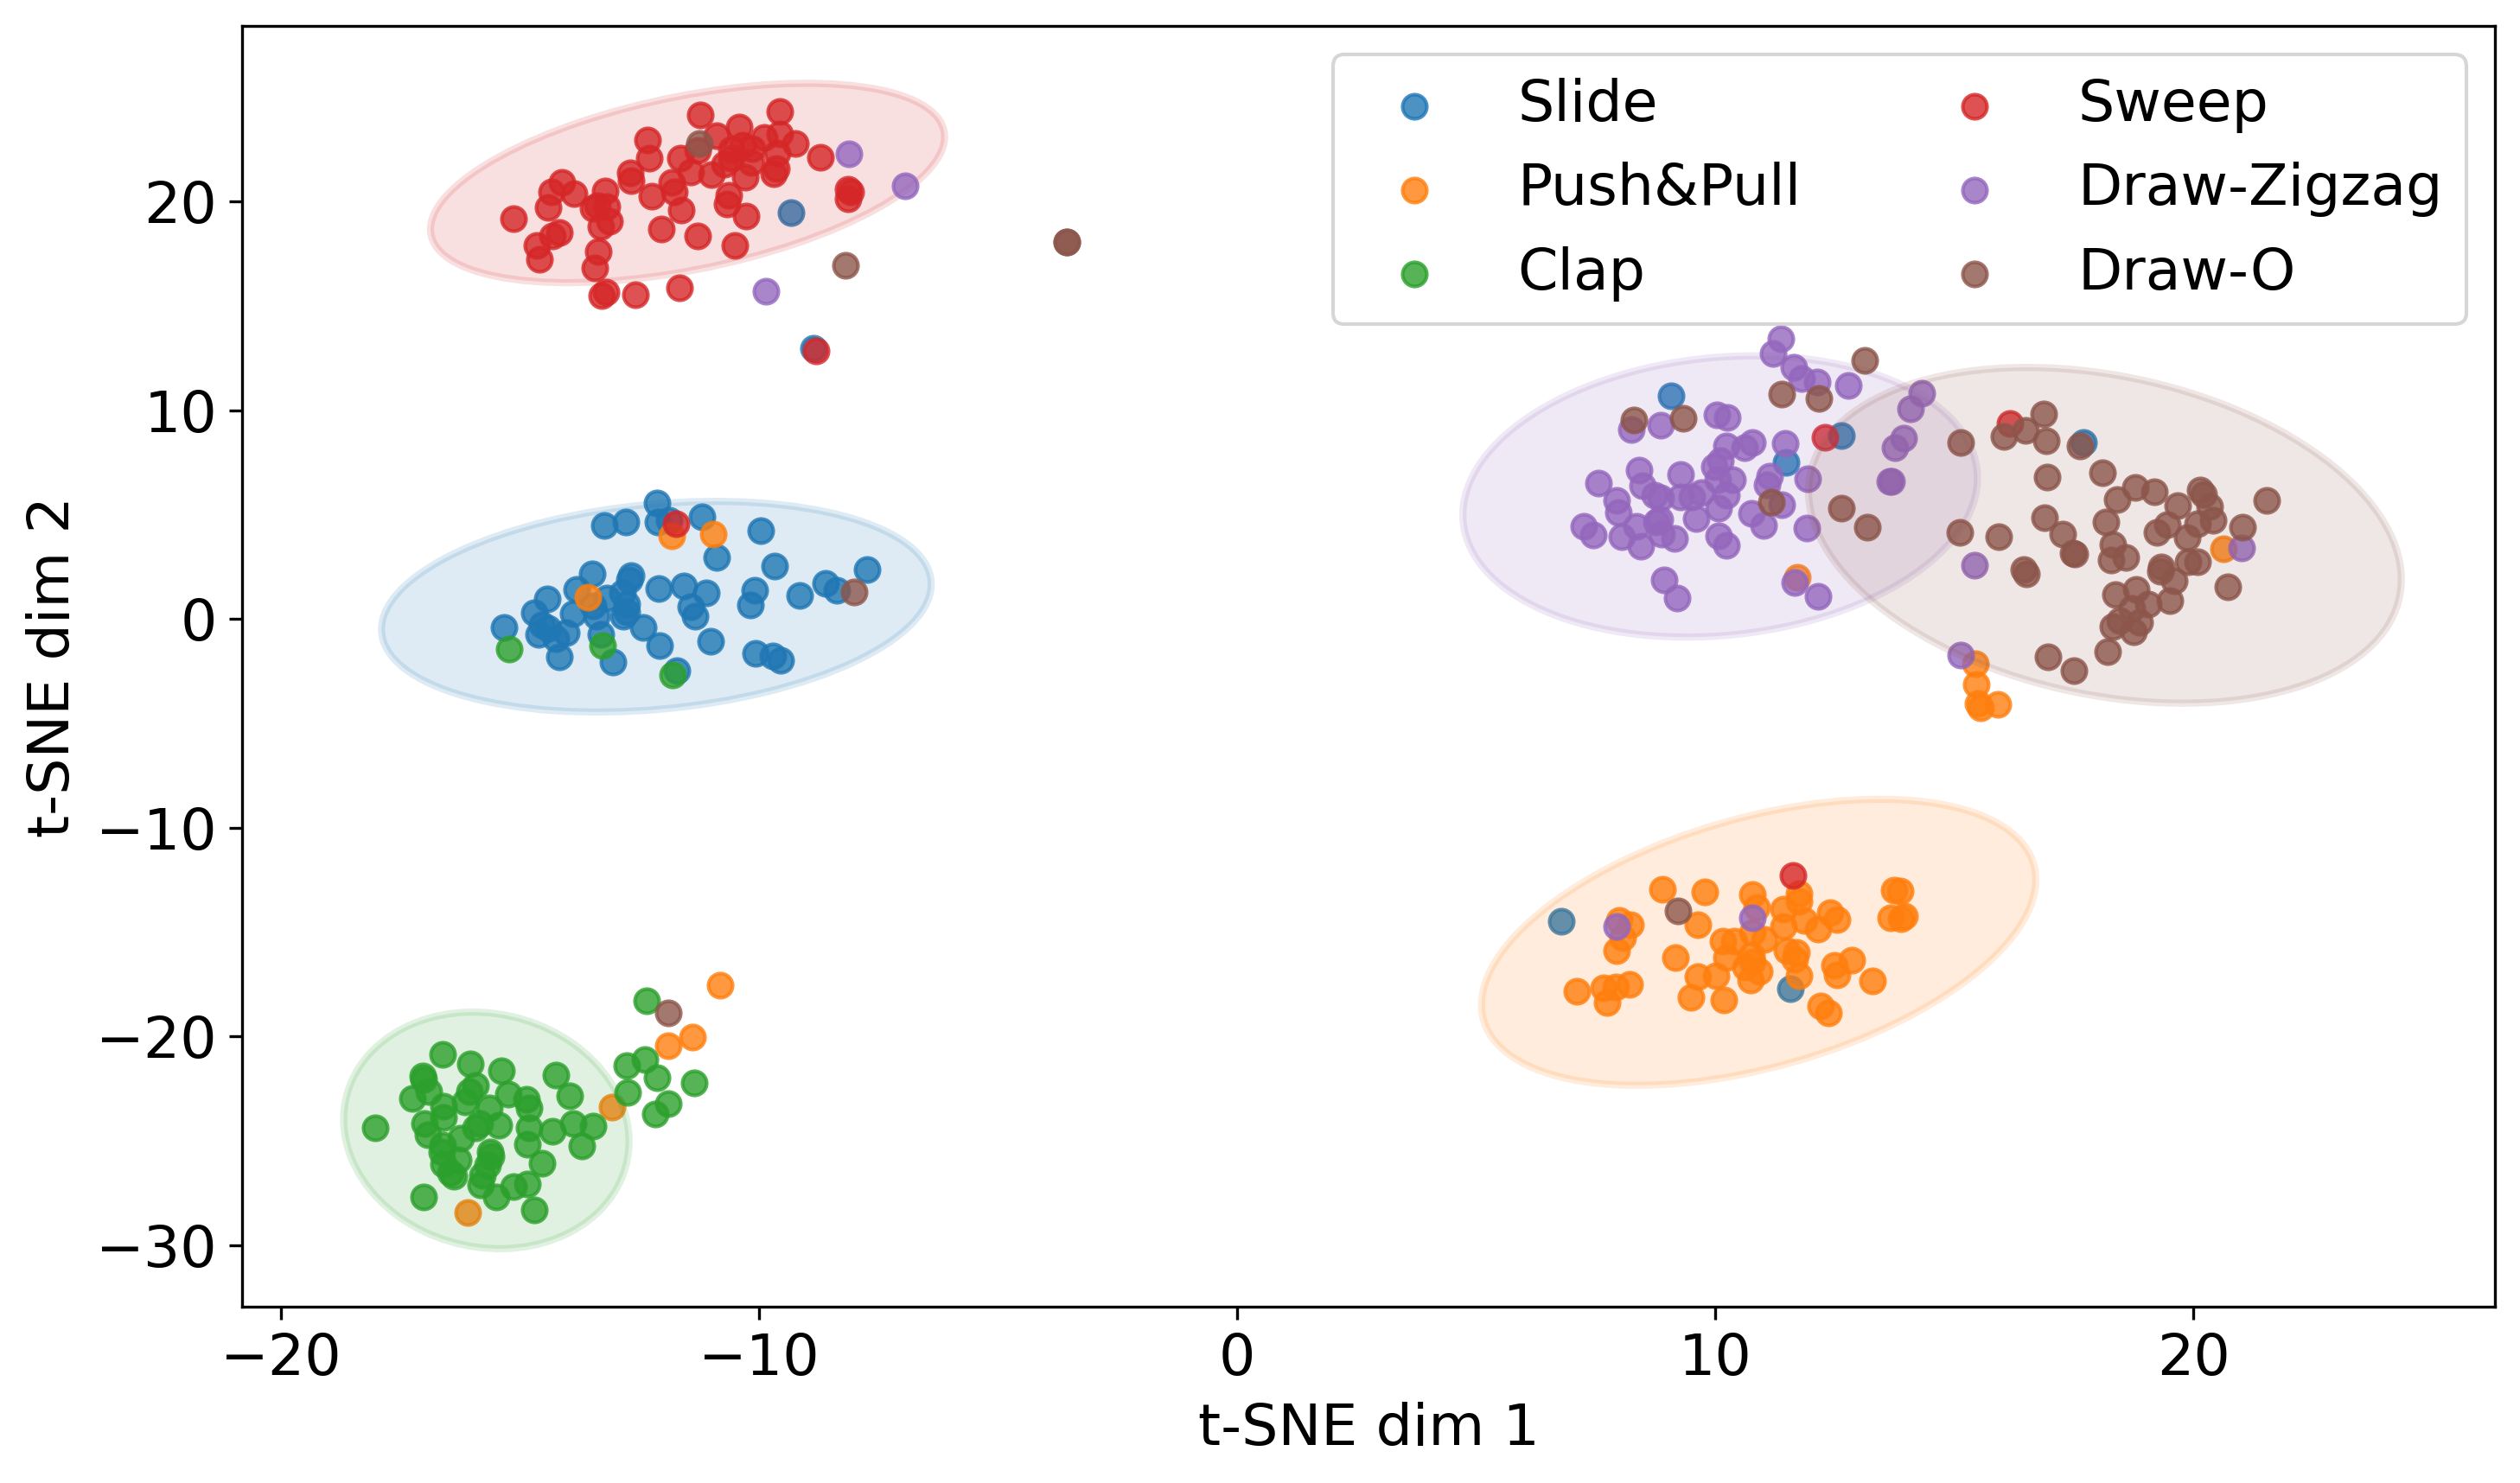

In [17]:

y = labels.astype(int)
feature_selected = feature_CLS[:, :, :]
print(feature_selected.shape)

X = []
for i in range(feature_selected.shape[0]):
    feature_sample = feature_selected[i, :, :]  # (head, dim)
    feature_sample = feature_sample.reshape(-1)
    X.append(normalize_safe(feature_sample.imag))

X = np.asarray(X)
num_classes = len(unique_labels)
num_heads = X.shape[1]



print("X.shape: ", X.shape)
tsne_perplexity = min(30, max(5, X.shape[0] // 10))
print("tsne_perplexity: ", tsne_perplexity)
tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    early_exaggeration=32,    # sweep this
    learning_rate=200,
    n_iter=4000,
    init='pca',
    random_state=42,
)
X_tsne = tsne.fit_transform(X)

# set fontsize
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
for cls in unique_labels:
    idx = y == cls
    color = None  # let matplotlib choose
    sc = ax.scatter(X_tsne[idx, 0], X_tsne[idx, 1], alpha=0.8, s=45,
                    label=label_to_gesture_name[int(cls)], color=color)
    c = sc.get_facecolor()[0]
    # add_confidence_ellipse(ax, X_tsne[idx, 0], X_tsne[idx, 1],
    #                        n_std=1.2, edgecolor=c, facecolor=c, alpha=0.2, lw=0)
    add_robust_ellipse(ax, X_tsne[idx, 0], X_tsne[idx, 1], color=c, n_std=3.0, q=0.80)

# plt.title('R2 movement mapping: t-SNE of interpretable head-density features')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
# plt.legend(loc='upper right')
# set to two columns legend
plt.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

(384, 12, 48)
X.shape:  (384, 1152)
tsne_perplexity:  30


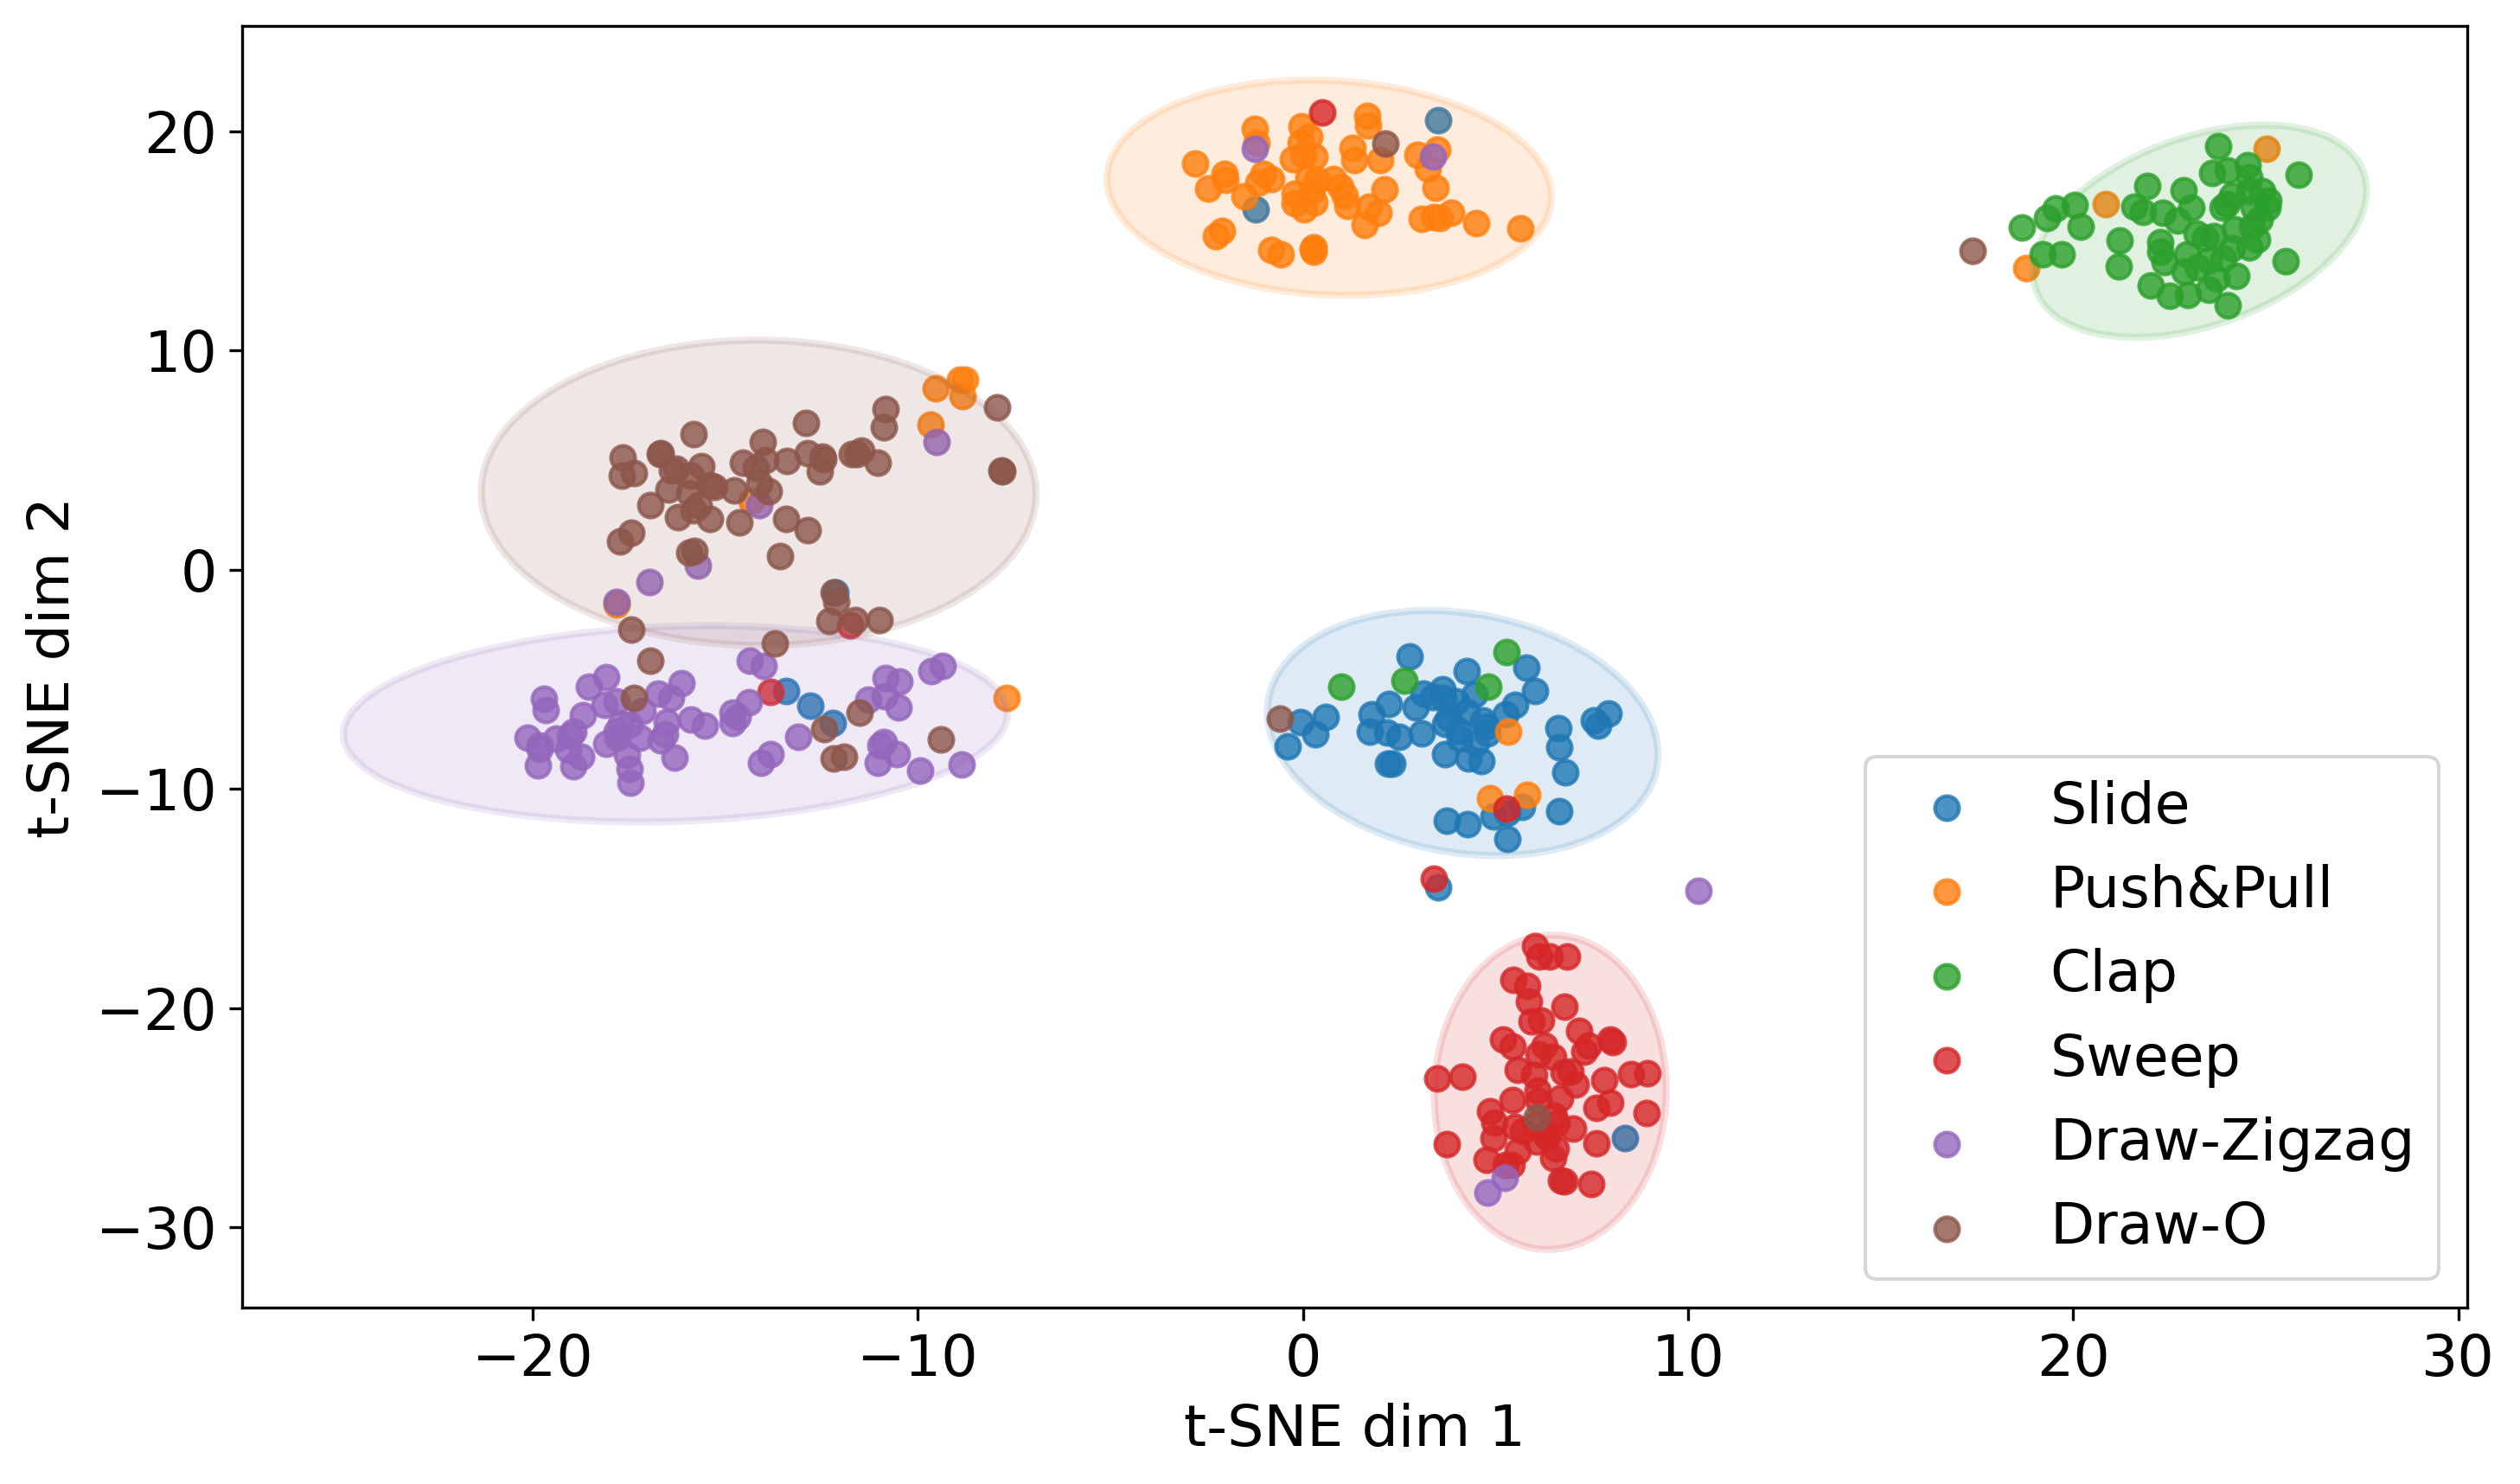

In [7]:

y = labels.astype(int)
feature_selected = feature_CLS[:, :, :]
print(feature_selected.shape)

X = []
for i in range(feature_selected.shape[0]):
    feature_sample = feature_selected[i, :, :]  # (head, dim)
    feature_sample = feature_sample.reshape(-1)
    X.append(normalize_safe(np.concatenate([feature_sample.real, feature_sample.imag])))

X = np.asarray(X)
num_classes = len(unique_labels)
num_heads = X.shape[1]


print("X.shape: ", X.shape)
tsne_perplexity = min(30, max(5, X.shape[0] // 10))
print("tsne_perplexity: ", tsne_perplexity)
tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    early_exaggeration=32,    # sweep this
    learning_rate=200,
    n_iter=4000,
    init='pca',
    random_state=42,
)
X_tsne = tsne.fit_transform(X)

# set fontsize
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
for cls in unique_labels:
    idx = y == cls
    color = None  # let matplotlib choose
    sc = ax.scatter(X_tsne[idx, 0], X_tsne[idx, 1], alpha=0.8, s=45,
                    label=label_to_gesture_name[int(cls)], color=color)
    c = sc.get_facecolor()[0]
    # add_confidence_ellipse(ax, X_tsne[idx, 0], X_tsne[idx, 1],
    #                        n_std=1.2, edgecolor=c, facecolor=c, alpha=0.2, lw=0)
    add_robust_ellipse(ax, X_tsne[idx, 0], X_tsne[idx, 1], color=c, n_std=3.0, q=0.80)

# plt.title('R2 movement mapping: t-SNE of interpretable head-density features')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.legend(loc='lower right')
# set to two columns legend
# plt.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

#### CLS feature subspace density distribution

(384, 12)
Top heads by movement separability:
    head  between_var  within_var  separability
0      0     0.084604    0.050573      1.672908
5      5     0.121998    0.094352      1.293003
3      3     0.084167    0.081128      1.037467
11    11     0.088847    0.093065      0.954677
1      1     0.065864    0.080417      0.819031
8      8     0.091871    0.119638      0.767905
7      7     0.066390    0.103829      0.639418
9      9     0.034707    0.072205      0.480670
Nearest-centroid balanced accuracy (head-density features): 0.8134
Linear probe balanced accuracy: mean=0.7970, std=0.0610
X_head.shape:  (384, 12)
tsne_perplexity:  20


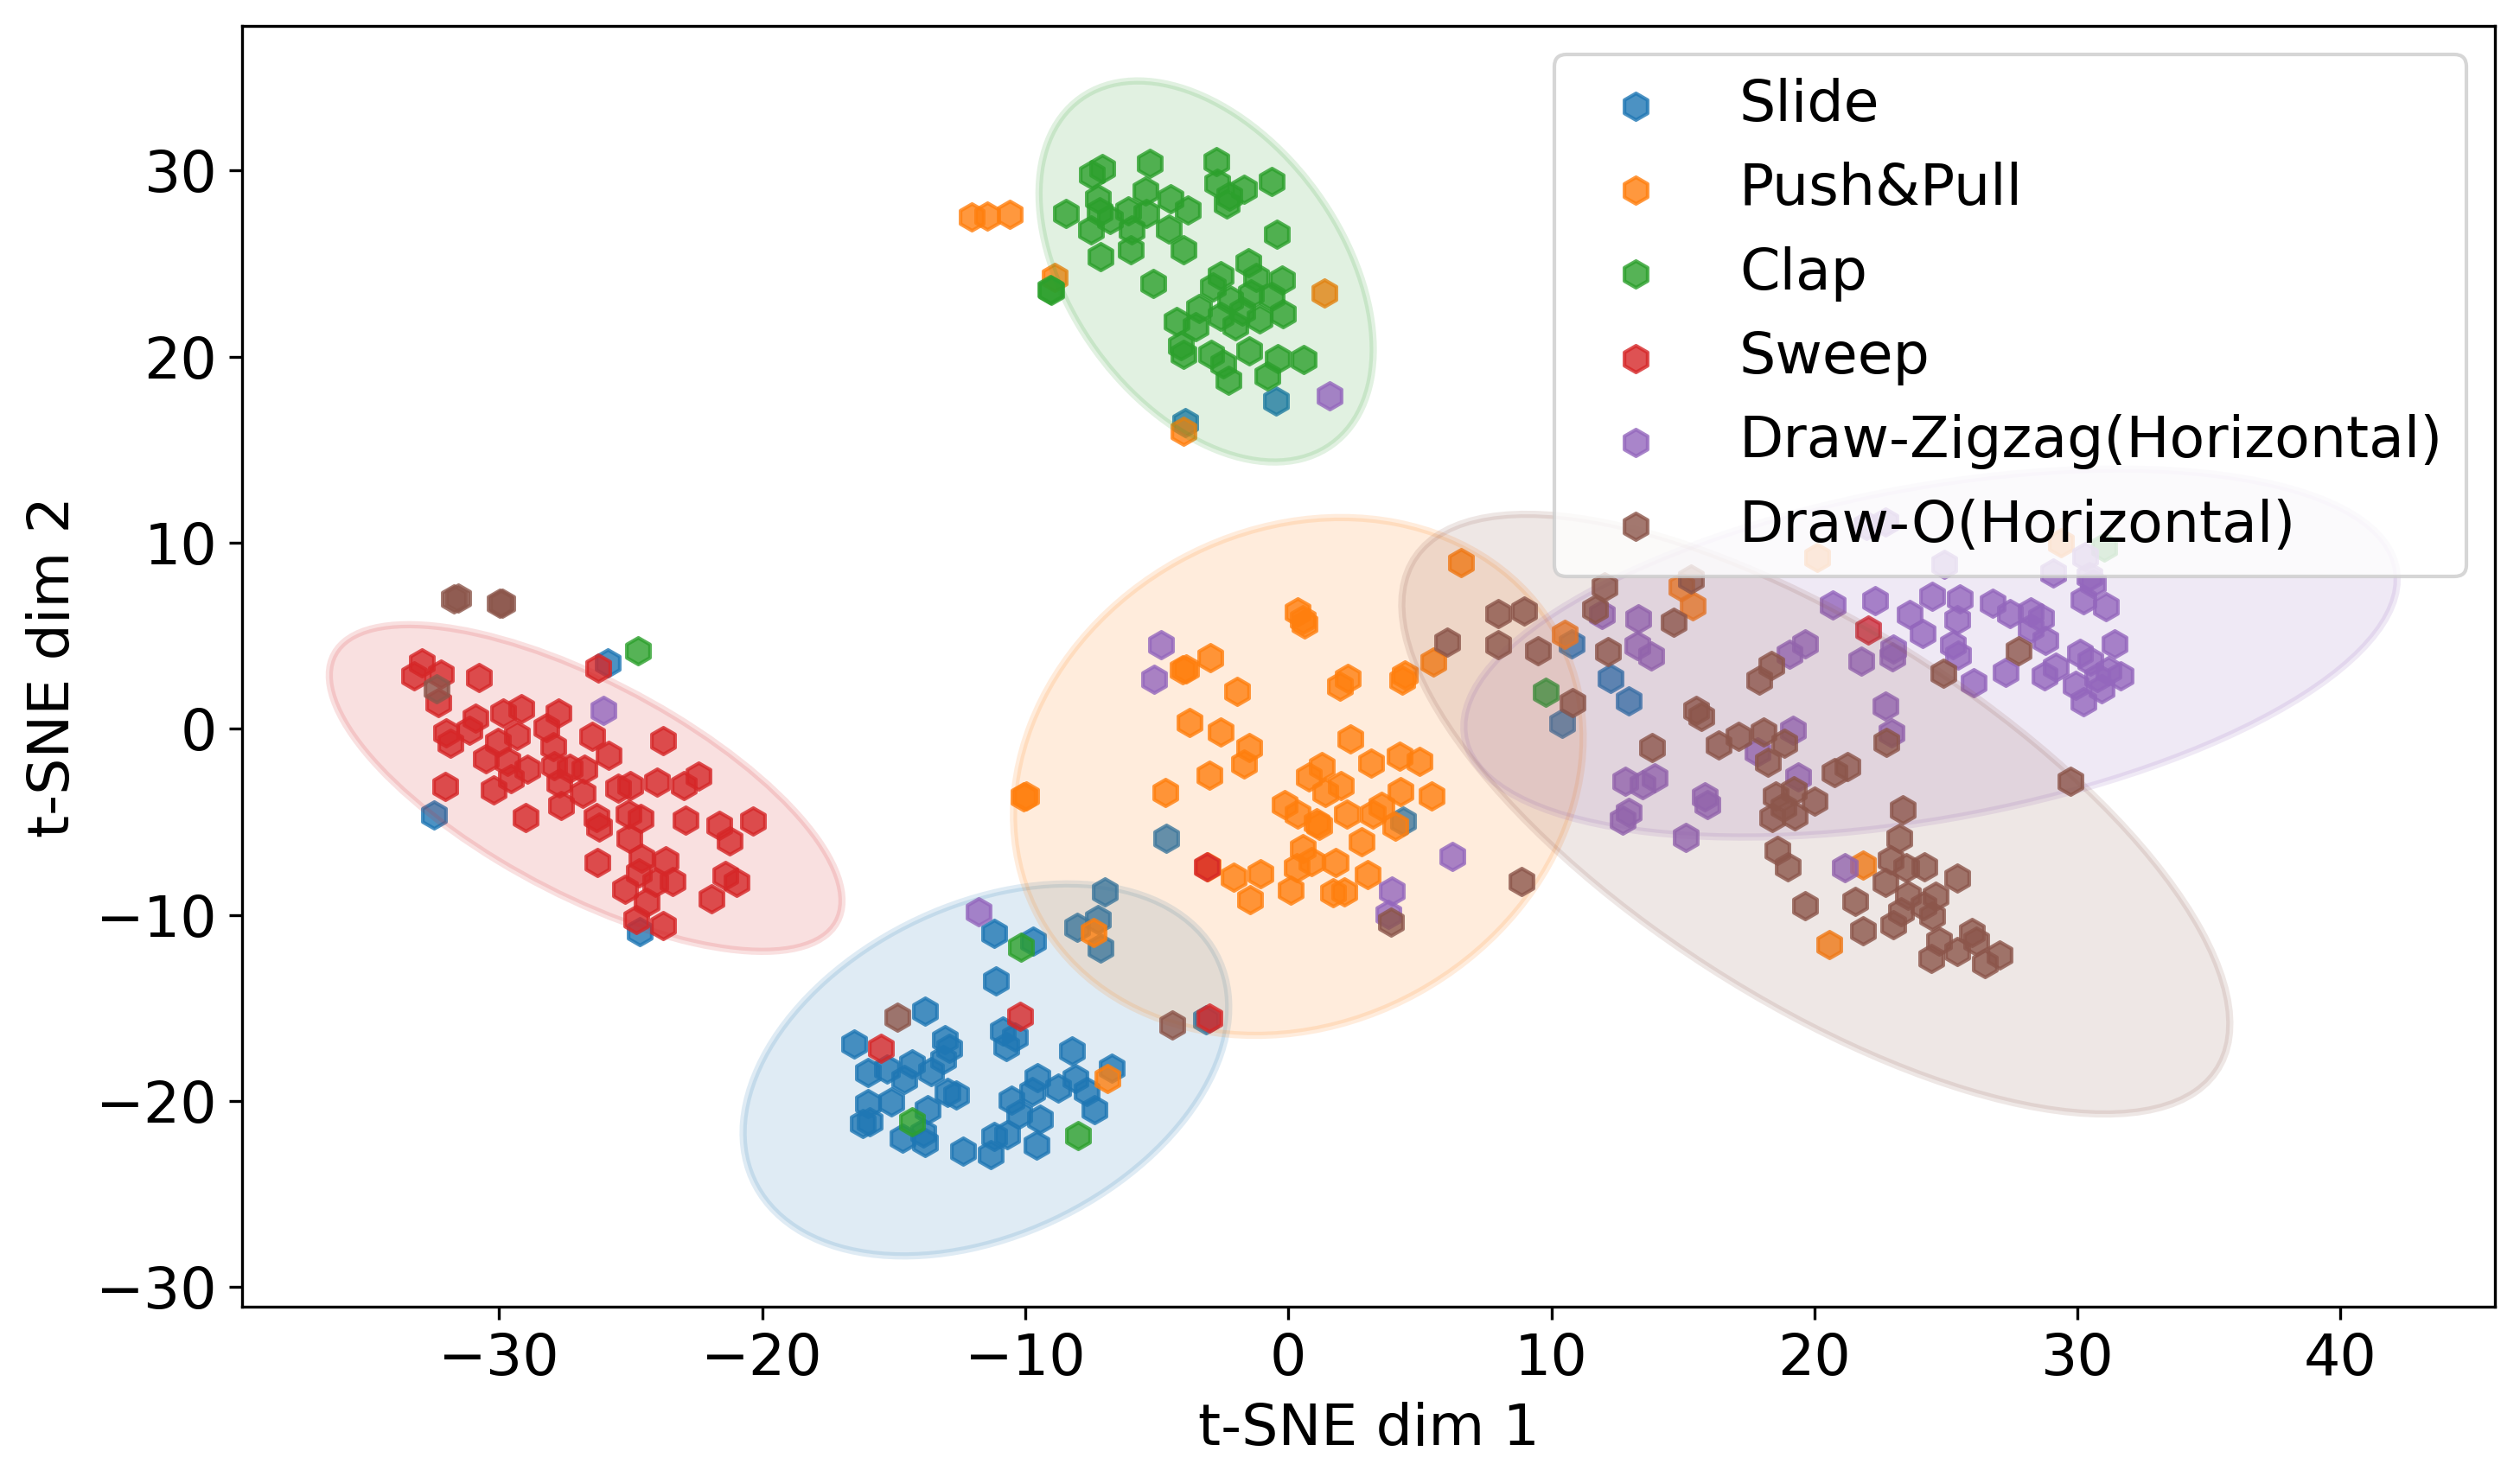

In [8]:
from sklearn.metrics import balanced_accuracy_score


def normalize_safe(x):
    x = np.asarray(x)
    x_min = np.min(x)
    x_max = np.max(x)
    if np.isclose(x_max - x_min, 0):
        return np.zeros_like(x, dtype=np.float64)
    return (x - x_min) / (x_max - x_min)


# Build interpretable per-sample head-density vectors (N x heads)
X_head = []
y = labels.astype(int)

for i in range(feature_CLS.shape[0]):
    feature_sample = feature_CLS[i]  # (head, dim)
    density_real = np.abs(feature_sample.real)  # (head, dim)
    density_real = normalize_safe(np.mean(density_real, axis=1))
    density_imag = np.abs(feature_sample.imag)  # (head, dim)
    density_imag = normalize_safe(np.mean(density_imag, axis=1))
    head_density = density_real**2 + density_imag**2
    X_head.append(head_density)


X_head = np.asarray(X_head)
num_classes = len(unique_labels)
num_heads = X_head.shape[1]

print(X_head.shape)

# Class prototypes and variances
class_centroids = {}
class_within_var = {}
for cls in unique_labels:
    X_cls = X_head[y == cls]
    class_centroids[int(cls)] = X_cls.mean(axis=0)
    class_within_var[int(cls)] = X_cls.var(axis=0)

centroid_matrix = np.vstack([class_centroids[int(cls)] for cls in unique_labels])
within_var_per_head = np.mean(np.vstack([class_within_var[int(cls)] for cls in unique_labels]), axis=0)
between_var_per_head = centroid_matrix.var(axis=0)
separability_per_head = (between_var_per_head + 1e-8) / (within_var_per_head + 1e-8)

movement_mapping_df = pd.DataFrame({
    'head': np.arange(num_heads),
    'between_var': between_var_per_head,
    'within_var': within_var_per_head,
    'separability': separability_per_head,
}).sort_values('separability', ascending=False)

print('Top heads by movement separability:')
print(movement_mapping_df.head(8))

# Nearest-centroid classification on interpretable vectors
centroid_mat = np.vstack([class_centroids[int(cls)] for cls in unique_labels])
dists = np.linalg.norm(X_head[:, None, :] - centroid_mat[None, :, :], axis=2)
y_pred_centroid = unique_labels[np.argmin(dists, axis=1)]
centroid_bal_acc = balanced_accuracy_score(y, y_pred_centroid)
print(f'Nearest-centroid balanced accuracy (head-density features): {centroid_bal_acc:.4f}')

# Linear probe performance using only interpretable head vectors
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
probe = LogisticRegression(max_iter=4000, multi_class='auto')
probe_scores = cross_val_score(probe, X_head, y, cv=cv, scoring='balanced_accuracy')
print(f'Linear probe balanced accuracy: mean={probe_scores.mean():.4f}, std={probe_scores.std():.4f}')


# from sklearn.manifold import TSNE

# t-SNE complements PCA by capturing nonlinear class structure
print("X_head.shape: ", X_head.shape)
tsne_perplexity = min(20, max(5, X_head.shape[0] // 10))
print("tsne_perplexity: ", tsne_perplexity)
tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    learning_rate='auto',
    init='pca',
    random_state=42,
)
X_tsne = tsne.fit_transform(X_head)



# set fontsize
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
for cls in unique_labels:
    idx = y == cls
    color = None  # let matplotlib choose
    sc = ax.scatter(X_tsne[idx, 0], X_tsne[idx, 1], alpha=0.8, s=55,
                    label=label_to_gesture_name[int(cls)], color=color, marker='h')
    c = sc.get_facecolor()[0]
    # add_confidence_ellipse(ax, X_tsne[idx, 0], X_tsne[idx, 1],
    #                        n_std=1.2, edgecolor=c, facecolor=c, alpha=0.2, lw=0)
    add_robust_ellipse(ax, X_tsne[idx, 0], X_tsne[idx, 1], color=c, n_std=3.0, q=0.80)

# plt.title('R2 movement mapping: t-SNE of interpretable head-density features')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.legend(loc='upper right')
# set to two columns legend
# plt.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()


## Subspace specialization

### Orthogonal-subspace specialization (head-level)

(6, 12)
(6, 12)
Top specialized heads:
   head  entropy_norm  dominance       hhi  gini_impurity  dominant_label  \
0     5      0.885408   0.318831  0.230016       0.769984               4   
1     0      0.911561   0.349517  0.222819       0.777181               2   
2     7      0.891228   0.280358  0.227131       0.772869               3   
3     2      0.933851   0.325163  0.206991       0.793009               5   
4    11      0.924943   0.271948  0.209536       0.790464               5   
5     8      0.945185   0.272623  0.198061       0.801939               5   
6     1      0.951649   0.296974  0.197732       0.802268               2   
7     3      0.965700   0.270105  0.187944       0.812056               0   
8     6      0.976350   0.255320  0.180791       0.819209               4   
9     4      0.983185   0.215019  0.176289       0.823711               1   

          dominant_gesture  separability  specialization_score  
0  Draw-Zigzag(Horizontal)      1.293003        

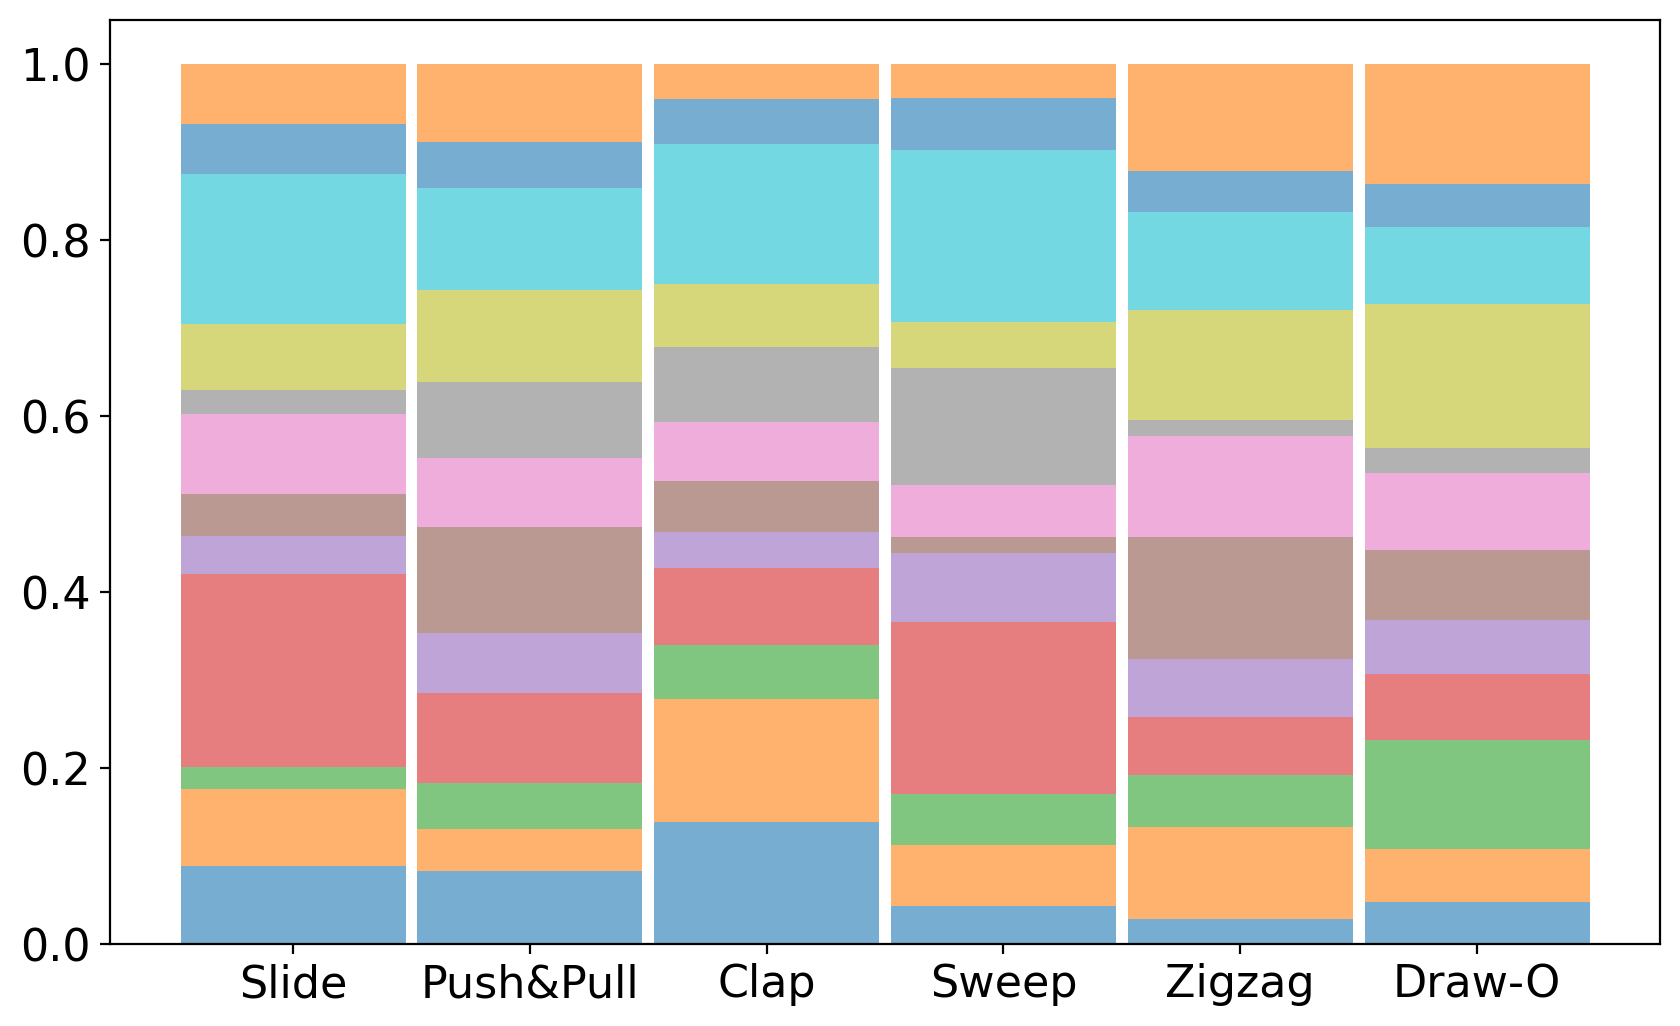

In [15]:
eps = 1e-12

# class_head_mass[c, h] = mean contribution of head h for class c
class_head_mass = np.vstack([
    X_head[y == cls].mean(axis=0)
    for cls in unique_labels
])

# P(head | class)
P_head_given_class = class_head_mass / (class_head_mass.sum(axis=1, keepdims=True) + eps)

print(P_head_given_class.shape)
# P(class | head)
P_class_given_head = class_head_mass / (class_head_mass.sum(axis=0, keepdims=True) + eps)
print(P_class_given_head.shape)

# Per-head specialization metrics
num_cls = P_class_given_head.shape[0]
entropy_per_head = -np.sum(P_class_given_head * np.log(P_class_given_head + eps), axis=0) / np.log(num_cls)
dominance_per_head = P_class_given_head.max(axis=0)
hhi_per_head = np.sum(P_class_given_head ** 2, axis=0)
gini_per_head = 1.0 - np.sum(P_class_given_head ** 2, axis=0)

dominant_class_idx = np.argmax(P_class_given_head, axis=0)
dominant_label = unique_labels[dominant_class_idx]
dominant_gesture = [label_to_gesture_name[int(lbl)] for lbl in dominant_label]

specialization_df = pd.DataFrame({
    'head': np.arange(num_heads),
    'entropy_norm': entropy_per_head,
    'dominance': dominance_per_head,
    'hhi': hhi_per_head,
    'gini_impurity': gini_per_head,
    'dominant_label': dominant_label,
    'dominant_gesture': dominant_gesture,
    'separability': separability_per_head,
})

# Composite specialization score: high dominance, low entropy
specialization_df['specialization_score'] = (
    specialization_df['dominance'] * (1.0 - specialization_df['entropy_norm'])
)
specialization_df = specialization_df.sort_values('specialization_score', ascending=False).reset_index(drop=True)

print('Top specialized heads:')
print(specialization_df.head(10))
print(specialization_df['specialization_score'])

# in the new ordered names, if we have 'Draw-', delete it
class_names_ordered_new = []
for name in class_names_ordered:
    if 'Zigzag' not in name:
        class_names_ordered_new.append(name)
        if '(Horizontal)' in name:
            class_names_ordered_new[-1] = class_names_ordered_new[-1].split('(Horizontal)')[0]
    else:
        class_names_ordered_new.append(name.split('Draw-')[1])
        if '(Horizontal)' in name:
            class_names_ordered_new[-1] = class_names_ordered_new[-1].split('(Horizontal)')[0]

print(class_names_ordered_new)
row_norm = P_head_given_class
plt.figure(figsize=(10, 6), dpi=200)
bottom = np.zeros(len(unique_labels))
for h in range(num_heads):
    vals = row_norm[:, h]
    plt.bar(class_names_ordered_new, 
            vals, 
            bottom=bottom, 
            label=f'S{h}', 
            alpha=0.6,
            width=0.95)
    bottom += vals


### White-box utility via interpretable head perturbation

Baseline balanced accuracy: 0.8134
Mask top-2 specialized heads: 0.7925 (drop=0.0208)
Mask bottom-2 specialized heads: 0.8105 (drop=0.0029)
Random mask (mean±std): 0.8008 ± 0.0119

Class-wise recall drops:
   label                  gesture  baseline_recall  mask_highspec_recall  \
0      0                    Slide         0.844828              0.793103   
1      1                Push&Pull         0.731343              0.656716   
2      2                     Clap         0.915254              0.932203   
3      3                    Sweep         0.907692              0.892308   
4      4  Draw-Zigzag(Horizontal)         0.764706              0.779412   
5      5       Draw-O(Horizontal)         0.716418              0.701493   

   mask_lowspec_recall  drop_highspec  drop_lowspec  
0             0.827586       0.051724      0.017241  
1             0.731343       0.074627      0.000000  
2             0.915254      -0.016949      0.000000  
3             0.907692       0.015385      0.

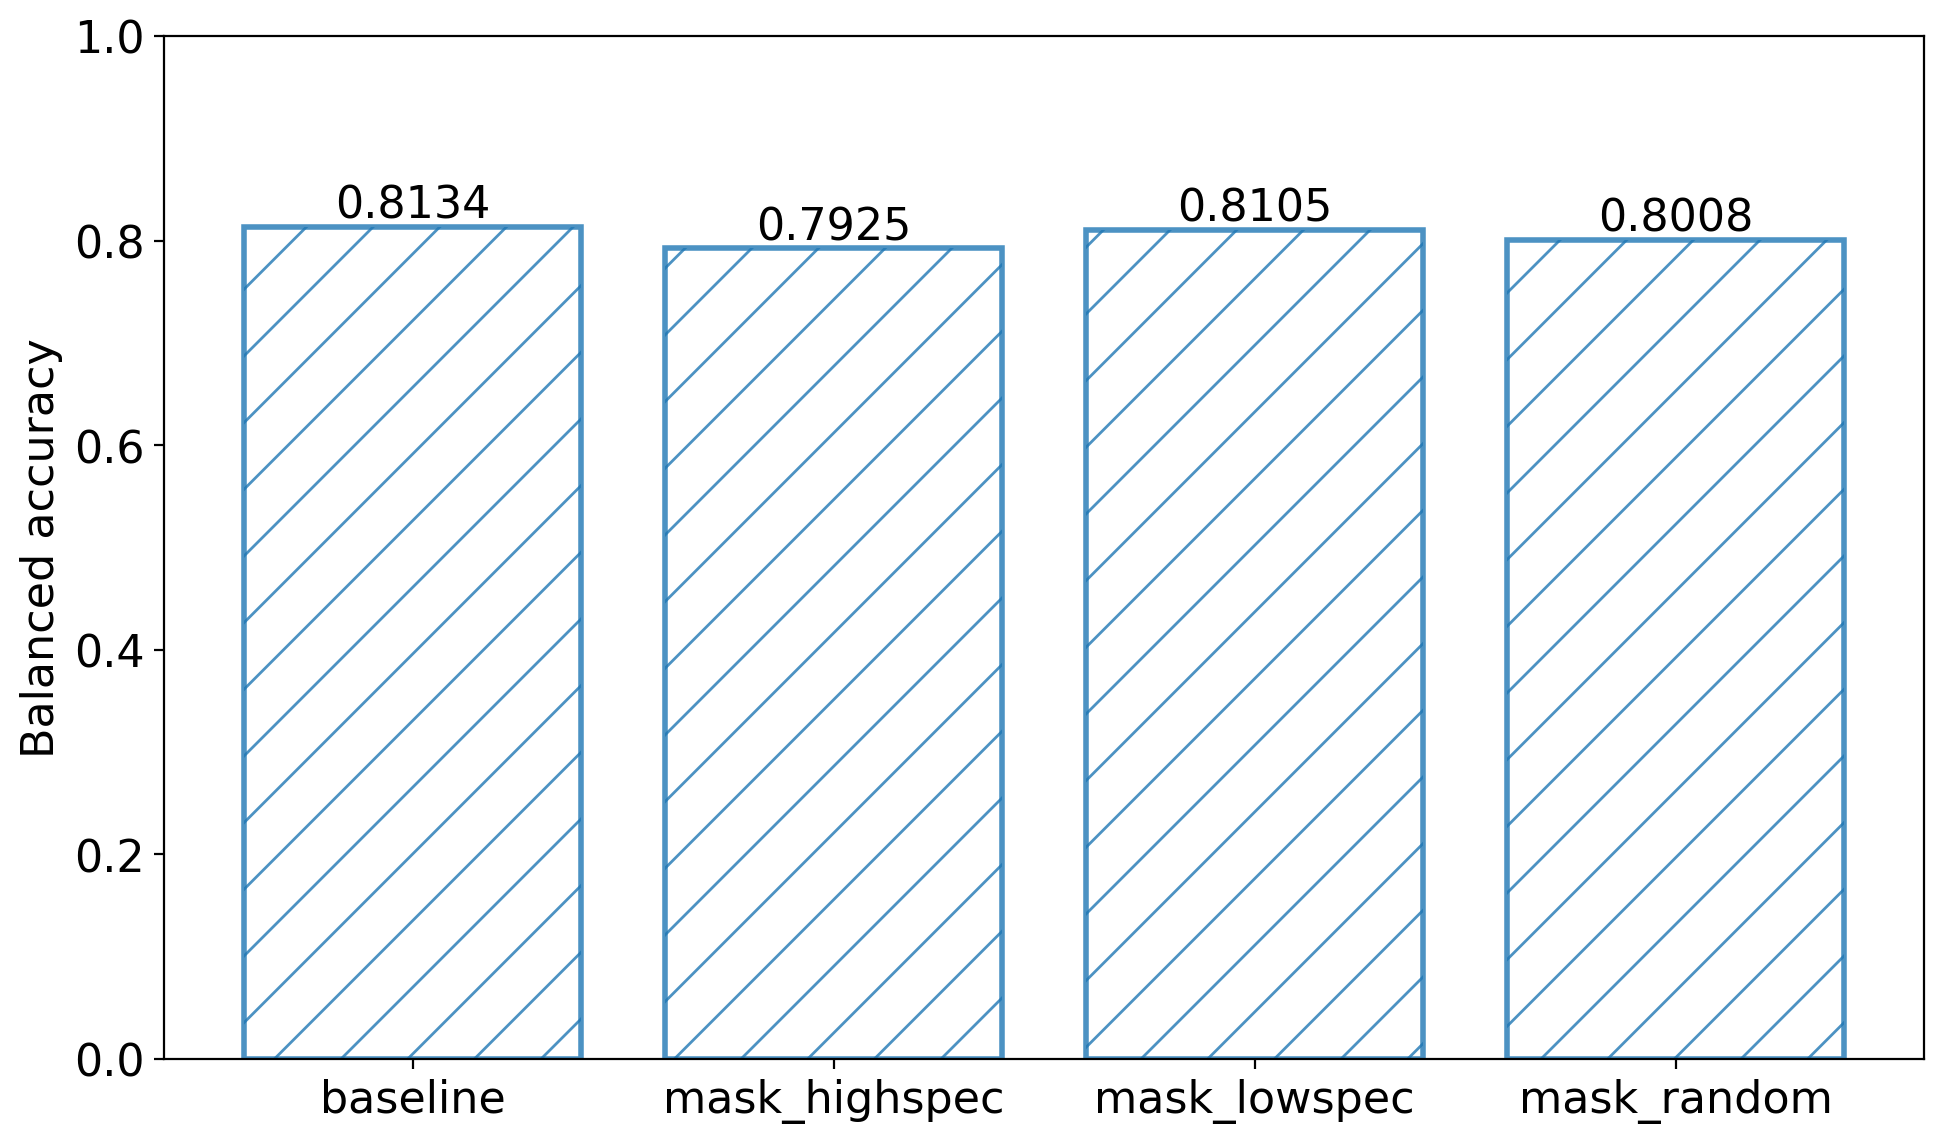

In [10]:
from sklearn.metrics import balanced_accuracy_score


def per_class_recall(y_true, y_pred, labels_sorted):
    recalls = {}
    for cls in labels_sorted:
        idx = y_true == cls
        recalls[int(cls)] = np.mean(y_pred[idx] == y_true[idx]) if np.any(idx) else np.nan
    return recalls


def nearest_centroid_predict(X, y_true, labels_sorted):
    cents = np.vstack([X[y_true == cls].mean(axis=0) for cls in labels_sorted])
    dd = np.linalg.norm(X[:, None, :] - cents[None, :, :], axis=2)
    return labels_sorted[np.argmin(dd, axis=1)]


# Baseline in interpretable head-density space
y_base = nearest_centroid_predict(X_head, y, unique_labels)
base_bal_acc = balanced_accuracy_score(y, y_base)
base_recall = per_class_recall(y, y_base, unique_labels)

# Mask sets from specialization ranking
k = max(1, num_heads // 6)
ranked_heads = specialization_df.sort_values('specialization_score', ascending=False)['head'].values
high_spec_heads = ranked_heads[:k]
low_spec_heads = ranked_heads[-k:]


def mask_heads(X, heads_to_zero):
    X_m = X.copy()
    X_m[:, heads_to_zero] = 0.0
    return X_m


def eval_mask_set(head_set):
    X_m = mask_heads(X_head, head_set)
    y_m = nearest_centroid_predict(X_m, y, unique_labels)
    bal_acc = balanced_accuracy_score(y, y_m)
    recall = per_class_recall(y, y_m, unique_labels)
    return bal_acc, recall

high_acc, high_recall = eval_mask_set(high_spec_heads)
low_acc, low_recall = eval_mask_set(low_spec_heads)

# Random-head baseline
rng = np.random.default_rng(0)
random_acc = []
for _ in range(300):
    rnd = rng.choice(np.arange(num_heads), size=k, replace=False)
    a, _ = eval_mask_set(rnd)
    random_acc.append(a)
random_acc = np.array(random_acc)

print(f'Baseline balanced accuracy: {base_bal_acc:.4f}')
print(f'Mask top-{k} specialized heads: {high_acc:.4f} (drop={base_bal_acc-high_acc:.4f})')
print(f'Mask bottom-{k} specialized heads: {low_acc:.4f} (drop={base_bal_acc-low_acc:.4f})')
print(f'Random mask (mean±std): {random_acc.mean():.4f} ± {random_acc.std():.4f}')

# Class-wise drop table
rows = []
for cls in unique_labels:
    rows.append({
        'label': int(cls),
        'gesture': label_to_gesture_name[int(cls)],
        'baseline_recall': base_recall[int(cls)],
        'mask_highspec_recall': high_recall[int(cls)],
        'mask_lowspec_recall': low_recall[int(cls)],
        'drop_highspec': base_recall[int(cls)] - high_recall[int(cls)],
        'drop_lowspec': base_recall[int(cls)] - low_recall[int(cls)],
    })
r4_recall_drop_df = pd.DataFrame(rows)
print('\nClass-wise recall drops:')
print(r4_recall_drop_df)

# Visual summary
plt.figure(figsize=(10, 6), dpi=200)
labels_plot = ['baseline', 'mask_highspec', 'mask_lowspec', 'mask_random']
vals_plot = [base_bal_acc, high_acc, low_acc, random_acc.mean()]
plt.bar(labels_plot, vals_plot, facecolor='none', edgecolor='tab:blue', linewidth=2, alpha=0.8, hatch='/')
# add text on the top of the bar
for i, v in enumerate(vals_plot):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')
plt.ylabel('Balanced accuracy')
# plt.title('R4 perturbation: specialized-head masking causes larger drop')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Attention-to-movement linkage (class-wise patch focus)

(256, 121)
(32, 1)
Draw-Zigzag


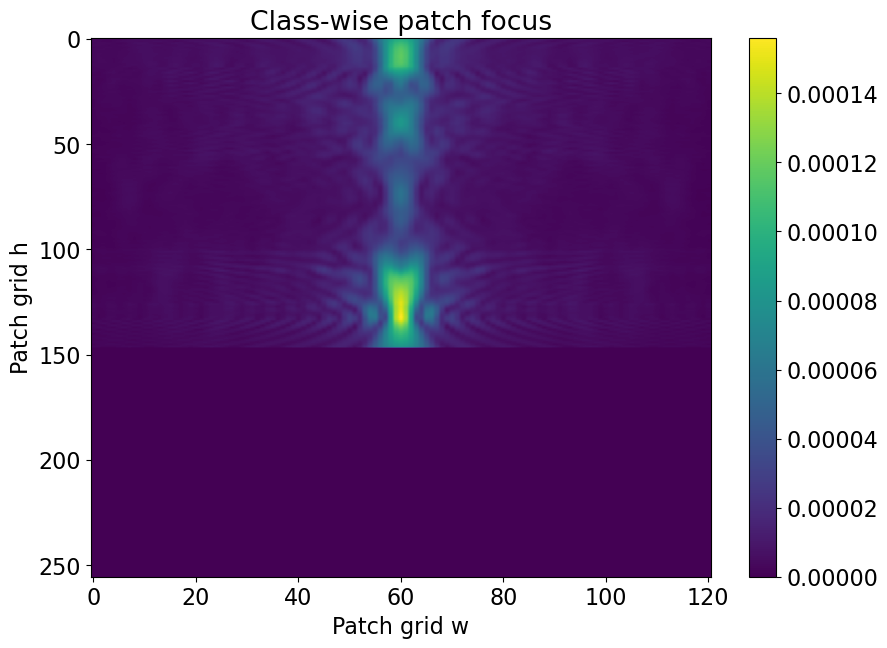

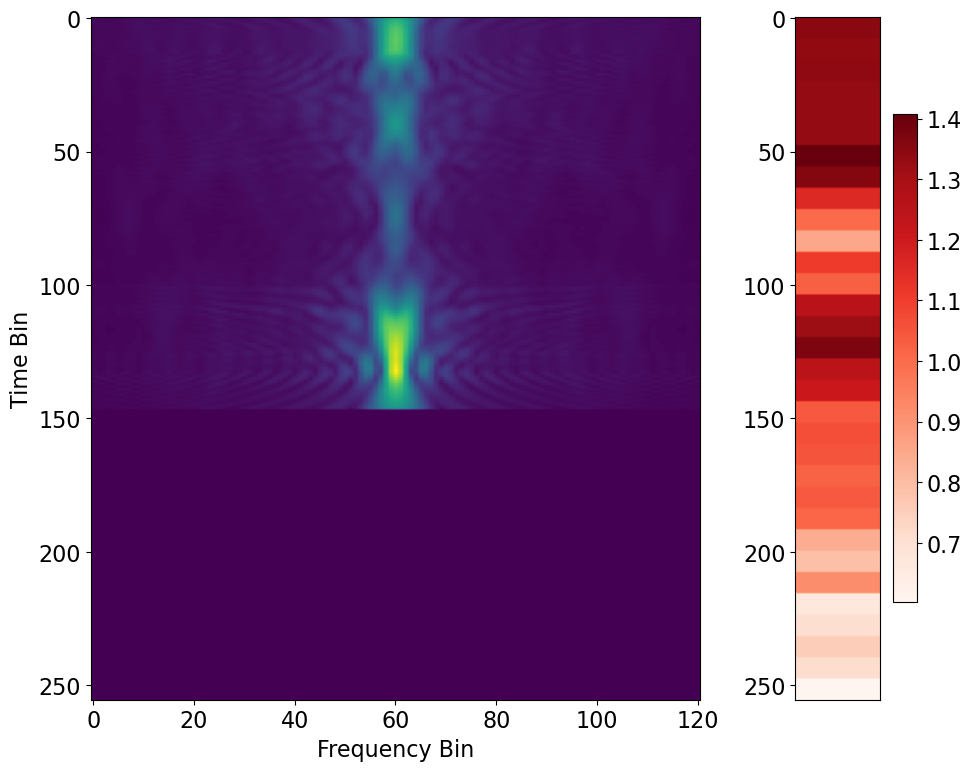

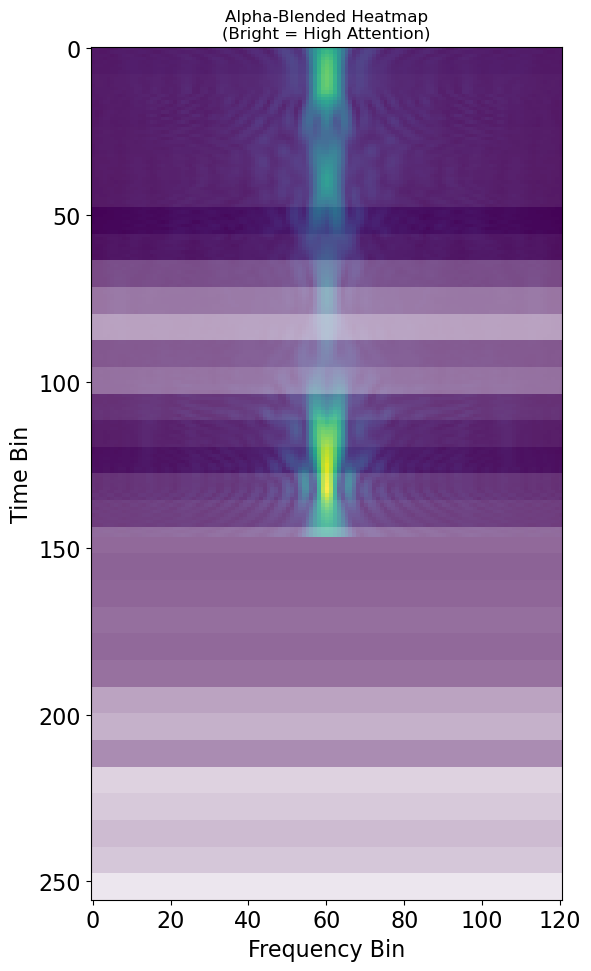

In [23]:
# attentions shape: (N, patch, head, dim) after removing CLS token
attn_patch_score = np.mean(np.abs(attentions), axis=(2, 3))  # (N, patch)
num_patches = attn_patch_score.shape[1]
num_samples = attn_patch_score.shape[0]
grid_h, grid_w = num_patches, 1


for i in range(num_samples):
    patch_map = attn_patch_score[i].reshape(grid_h, grid_w)
    input_map = inputs[i]
    cls_input_amp = np.mean(np.abs(input_map), axis=0)  # average over samples and links
    print(cls_input_amp.shape)
    print(patch_map.shape)
    
    label = y[i]
    label_to_gesture_name[int(label)]
    print(label_to_gesture_name[int(label)])
    
    plt.figure(figsize=(10, 7))
    plt.imshow(cls_input_amp, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title('Class-wise patch focus')
    plt.xlabel('Patch grid w')
    plt.ylabel('Patch grid h')
    plt.show()
    
    
    ################################
    H, W = cls_input_amp.shape
    h = patch_map.shape[0]
    input_heatmap = cls_input_amp
    attention_map = patch_map

    # 2. Rescale Attention Map using NumPy
    # We repeat the 'h' values vertically to match the 'H' dimension of the input
    scale_factor = H // h
    # Repeat each element 'scale_factor' times along the 0-axis (rows)
    attn_resized = np.repeat(attention_map, scale_factor, axis=0)

    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), 
                                gridspec_kw={'width_ratios': [5, 1]})

    # Panel 1: Input Heatmap
    im1 = ax1.imshow(input_heatmap, cmap='viridis', aspect='auto')
    # ax1.set_title("Input Heatmap ($H \\times W$)", fontsize=12)
    ax1.set_ylabel("Time Bin")
    ax1.set_xlabel("Frequency Bin")

    # Panel 2: Attention Vector
    # We use 'hot' or 'magma' for attention to contrast with the input cmap
    im2 = ax2.imshow(attn_resized, cmap='Reds', aspect='auto')
    # ax2.set_title("Attention ($h \\times 1$)", fontsize=12)
    ax2.set_xticks([]) # Remove x-axis as it's a 1D vector

    # Optional: Add a colorbar to help interpret values
    fig.colorbar(im2, ax=ax2, fraction=0.2, pad=0.1)

    plt.tight_layout()
    plt.show()
    
    
    #################
    
    H, W = cls_input_amp.shape
    h = patch_map.shape[0]
    input_heatmap = cls_input_amp
    attention_map = patch_map

    # 2. Rescale attention map to match input shape (H, W)
    scale_factor = H // h
    attn_expanded = np.repeat(attention_map, scale_factor, axis=0)
    # If H is not perfectly divisible by h, pad or crop to match exactly H
    if attn_expanded.shape[0] < H:
        padding = np.zeros((H - attn_expanded.shape[0], 1))
        attn_expanded = np.vstack([attn_expanded, padding])
    attn_full = np.tile(attn_expanded, (1, W))

    # 3. Apply Proper Normalization
    # Normalize the heatmap values to [0, 1] for the colormap
    norm = plt.Normalize(vmin=input_heatmap.min(), vmax=input_heatmap.max())
    cmap = plt.get_cmap('viridis')
    heatmap_rgb = cmap(norm(input_heatmap)) # This returns a (H, W, 4) array

    # 4. Apply Attention to Alpha Channel
    # Normalize attention to [0.1, 1.0] so background is still faintly visible
    attn_min, attn_max = attn_full.min(), attn_full.max()
    attn_alpha = 0.1 + (attn_full - attn_min) * (0.9 / (attn_max - attn_min))

    # Set the 4th channel (Alpha) to our attention values
    heatmap_rgb[:, :, 3] = attn_alpha 

    # 5. Visualization
    fig, ax = plt.subplots(figsize=(6, 10))
    ax.imshow(heatmap_rgb, aspect='auto')
    ax.set_title("Alpha-Blended Heatmap\n(Bright = High Attention)", fontsize=12)
    ax.set_xlabel("Frequency Bin")
    ax.set_ylabel("Time Bin")

    plt.tight_layout()
    plt.show()
    break
# # select based on the user_id, orientation, rx
# selected_user_id = -1
# selected_orientation = -1
# selected_rx = -1

# selected_indexs = np.where((user_id_list == selected_user_id if selected_user_id != -1 else True) & (orientation_list == selected_orientation if selected_orientation != -1 else True) & (rx_list == selected_rx if selected_rx != -1 else True))[0]
# print(len(selected_indexs))


# feature_selected = feature_CLS[selected_indexs, :, :]
# y = y[selected_indexs]


In [24]:

# index_list_class_0 = np.where(y == 0)[0]
# index_list_class_1 = np.where(y == 1)[0]
# index_list_class_2 = np.where(y == 2)[0]
# index_list_class_3 = np.where(y == 3)[0]
# index_list_class_4 = np.where(y == 4)[0]
# index_list_class_5 = np.where(y == 5)[0]

# print(index_list_class_0)
# print(index_list_class_1)
# print(index_list_class_2)
# print(index_list_class_3)
# print(index_list_class_4)
# print(index_list_class_5)


index_list_class_0 = [193, 254, 265, 275]
index_list_class_1 = [60, 134, 207, 239]
index_list_class_2 = [39, 86, 131, 336]
index_list_class_3 = [103, 163, 214, 335]
index_list_class_4 = [118, 202, 218, 286]
index_list_class_5 = [102, 172, 271, 299]

# attentions shape: (N, patch, head, dim) after removing CLS token
attn_patch_score = np.mean(np.abs(attentions), axis=(2, 3))  # (N, patch)
num_patches = attn_patch_score.shape[1]
num_samples = attn_patch_score.shape[0]
grid_h, grid_w = num_patches, 1


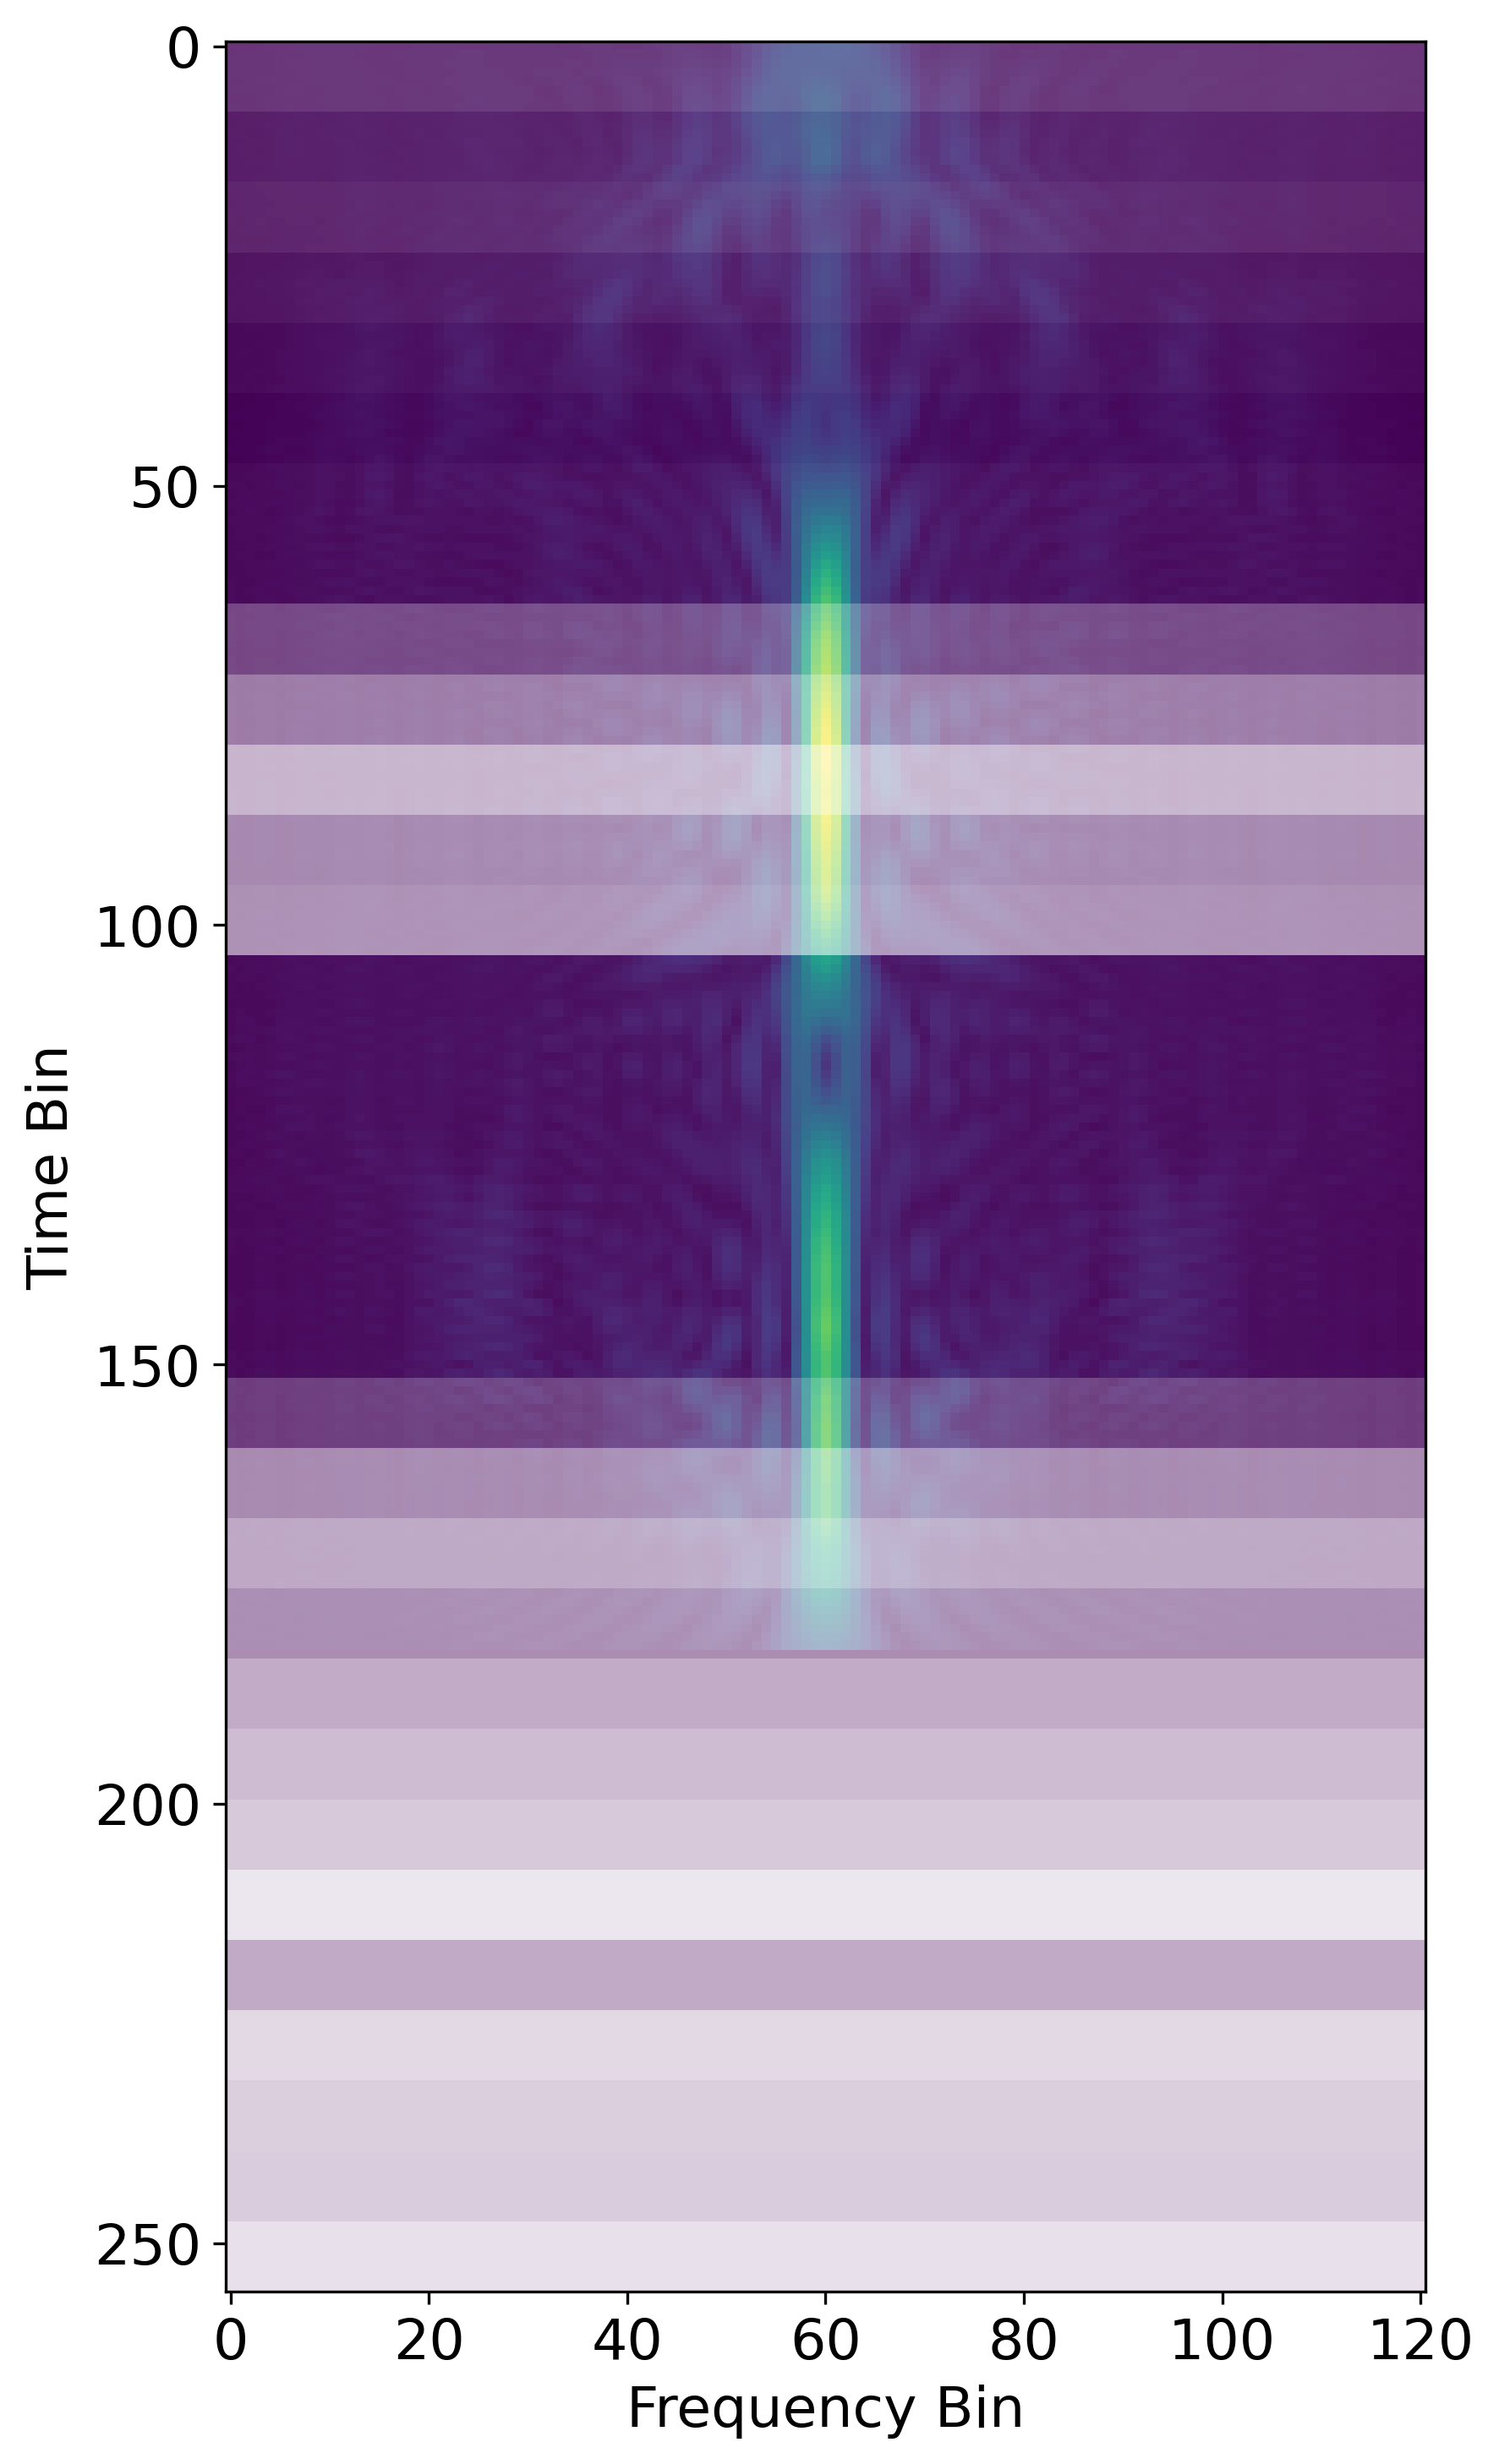

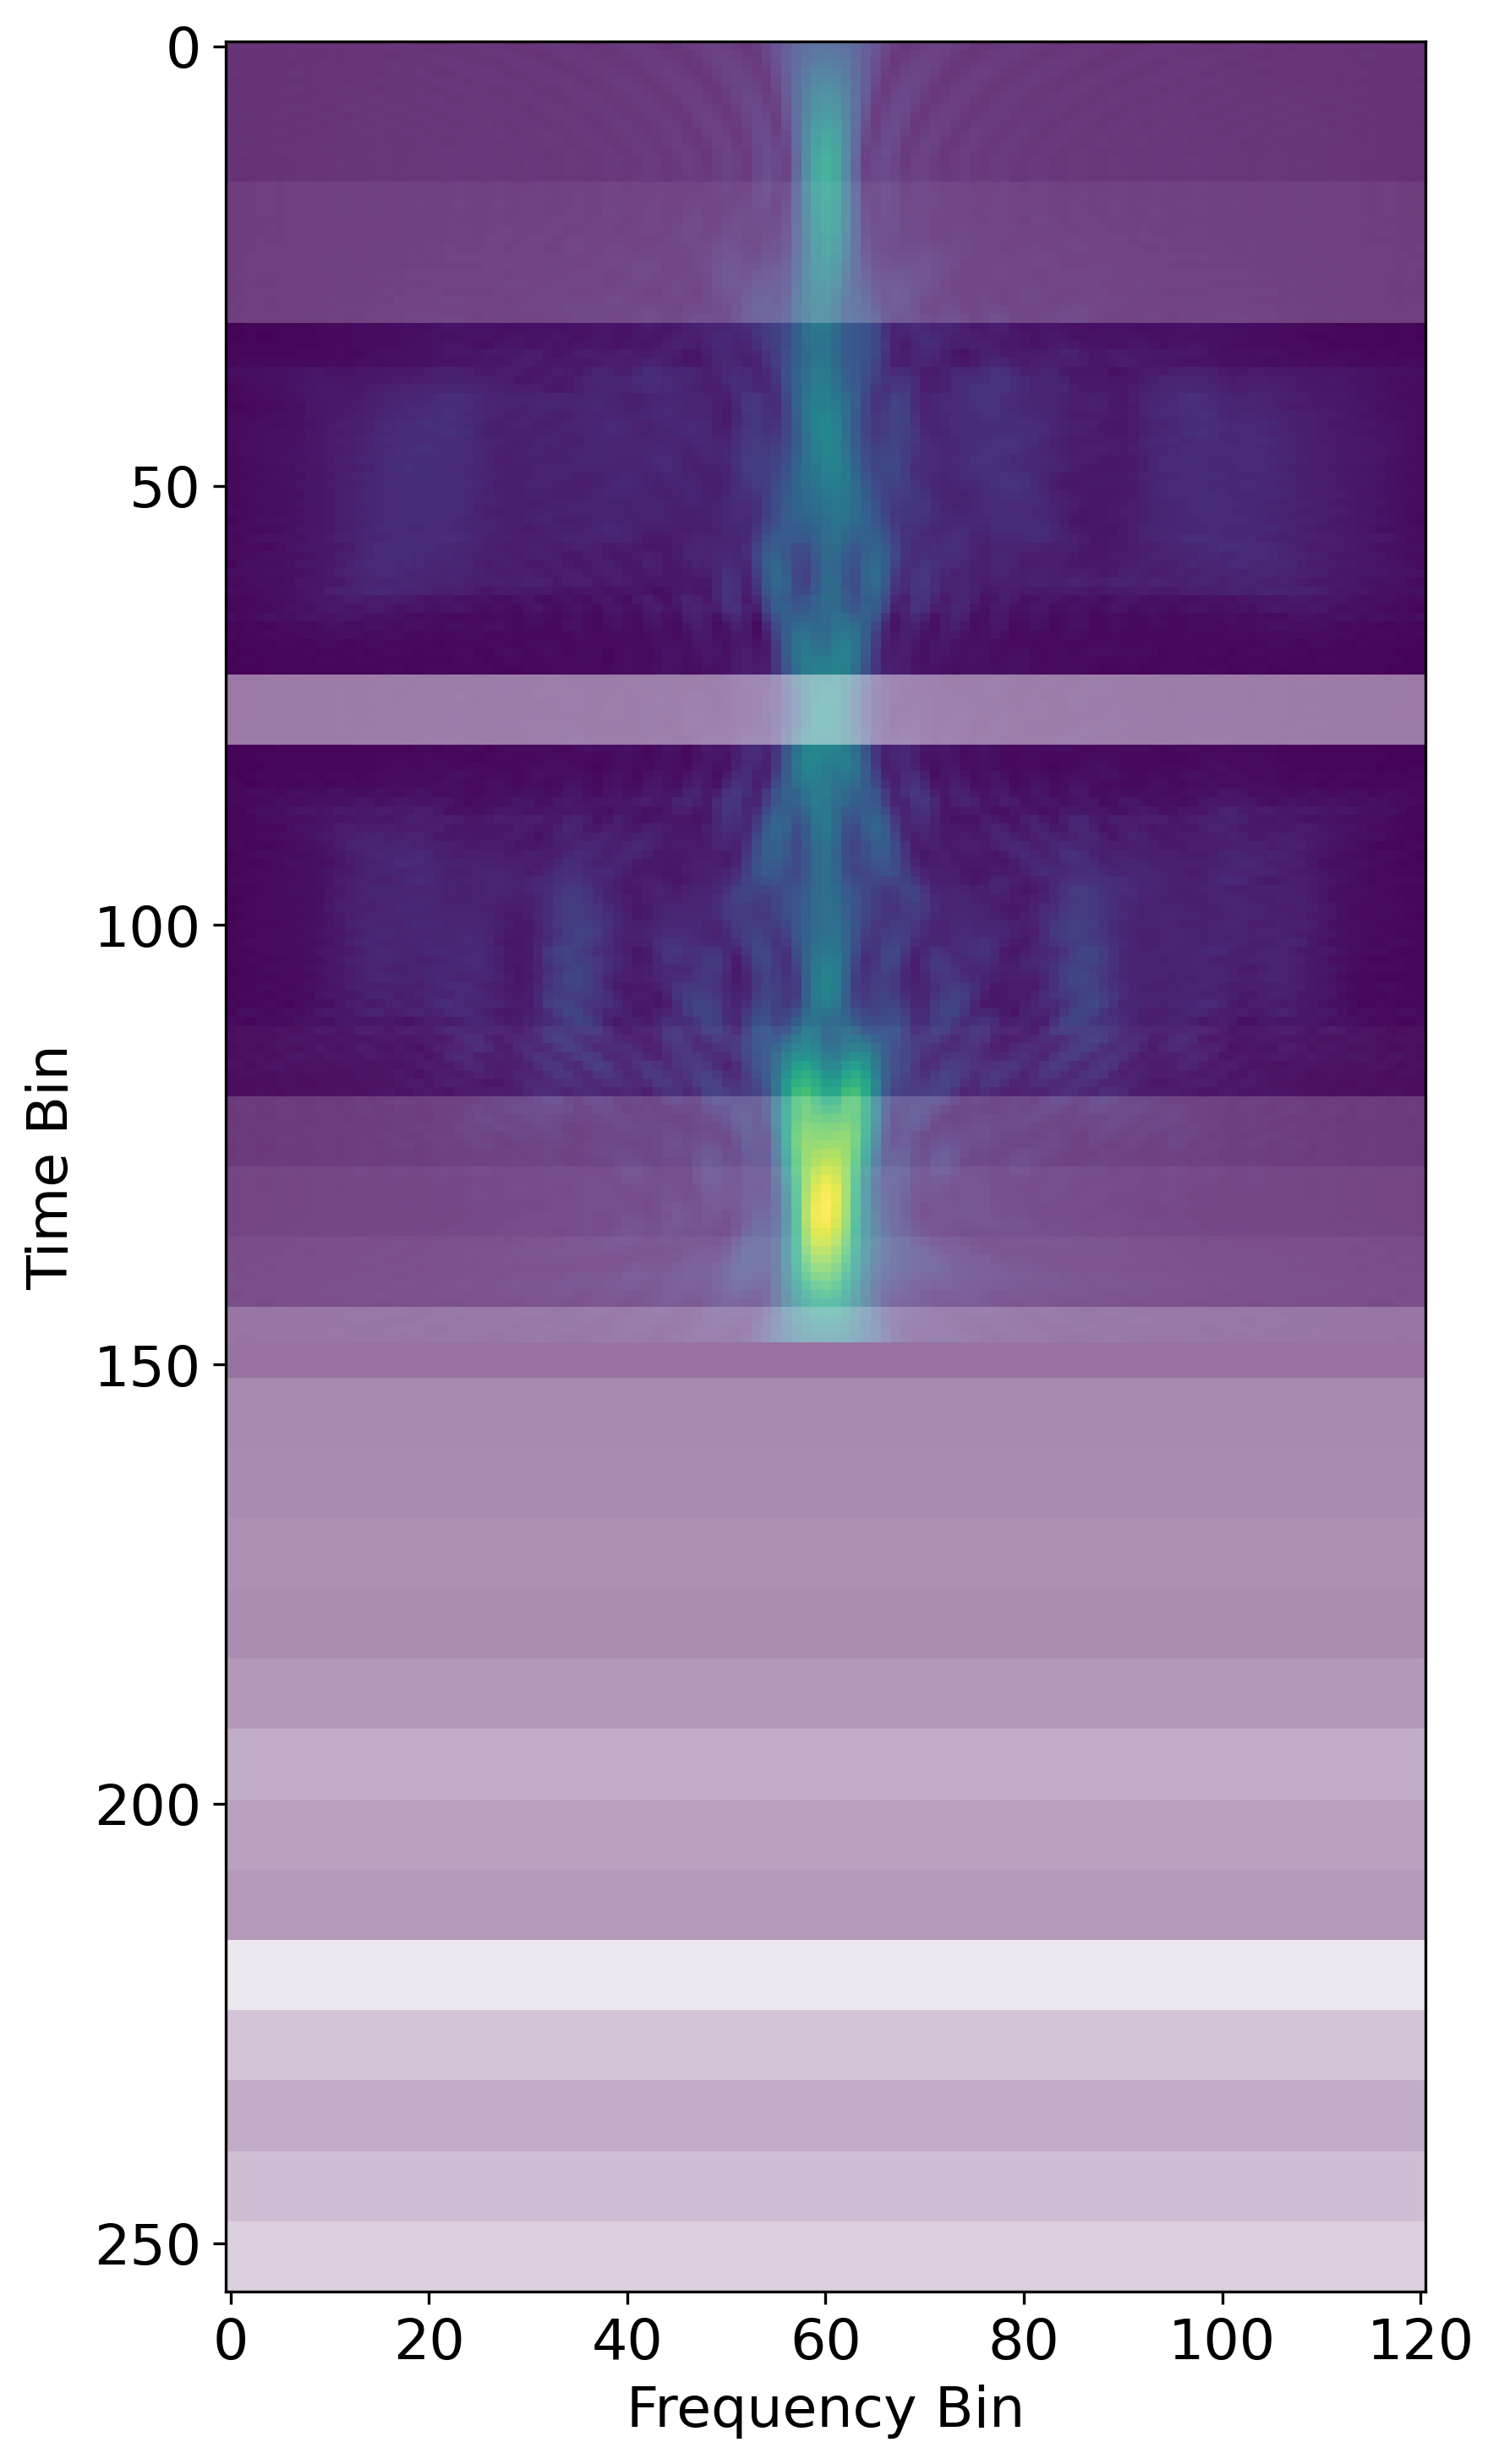

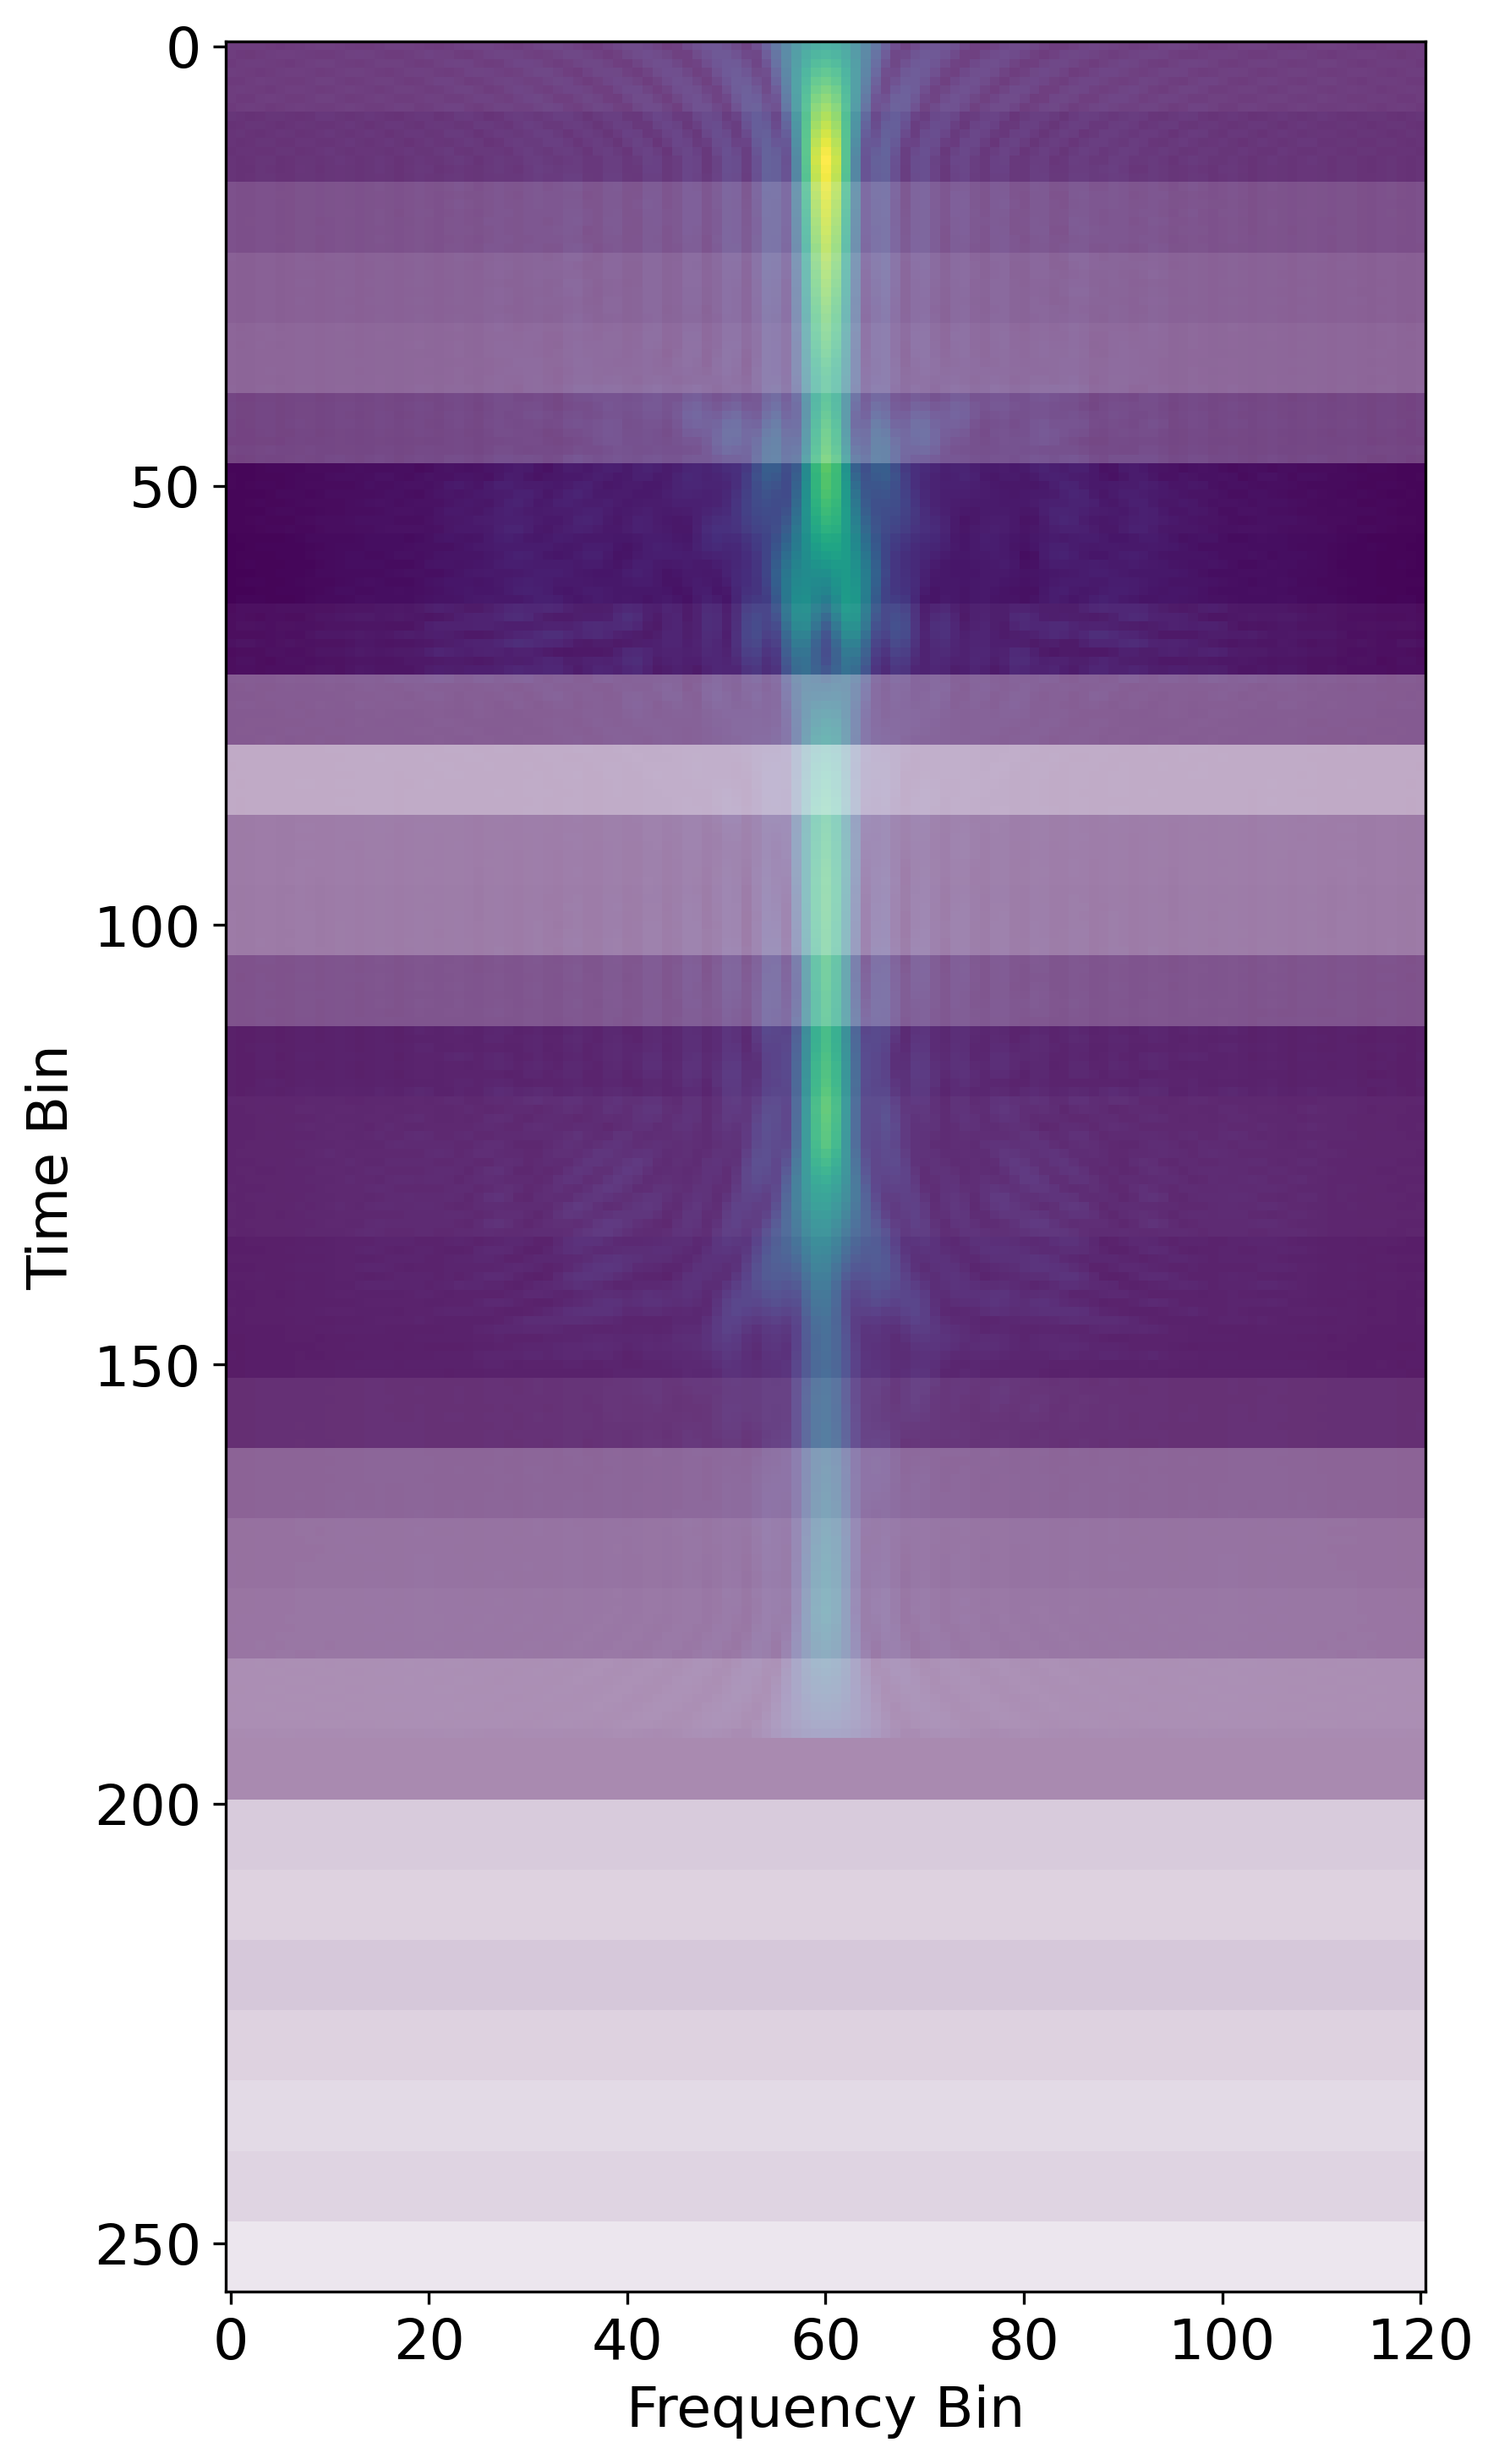

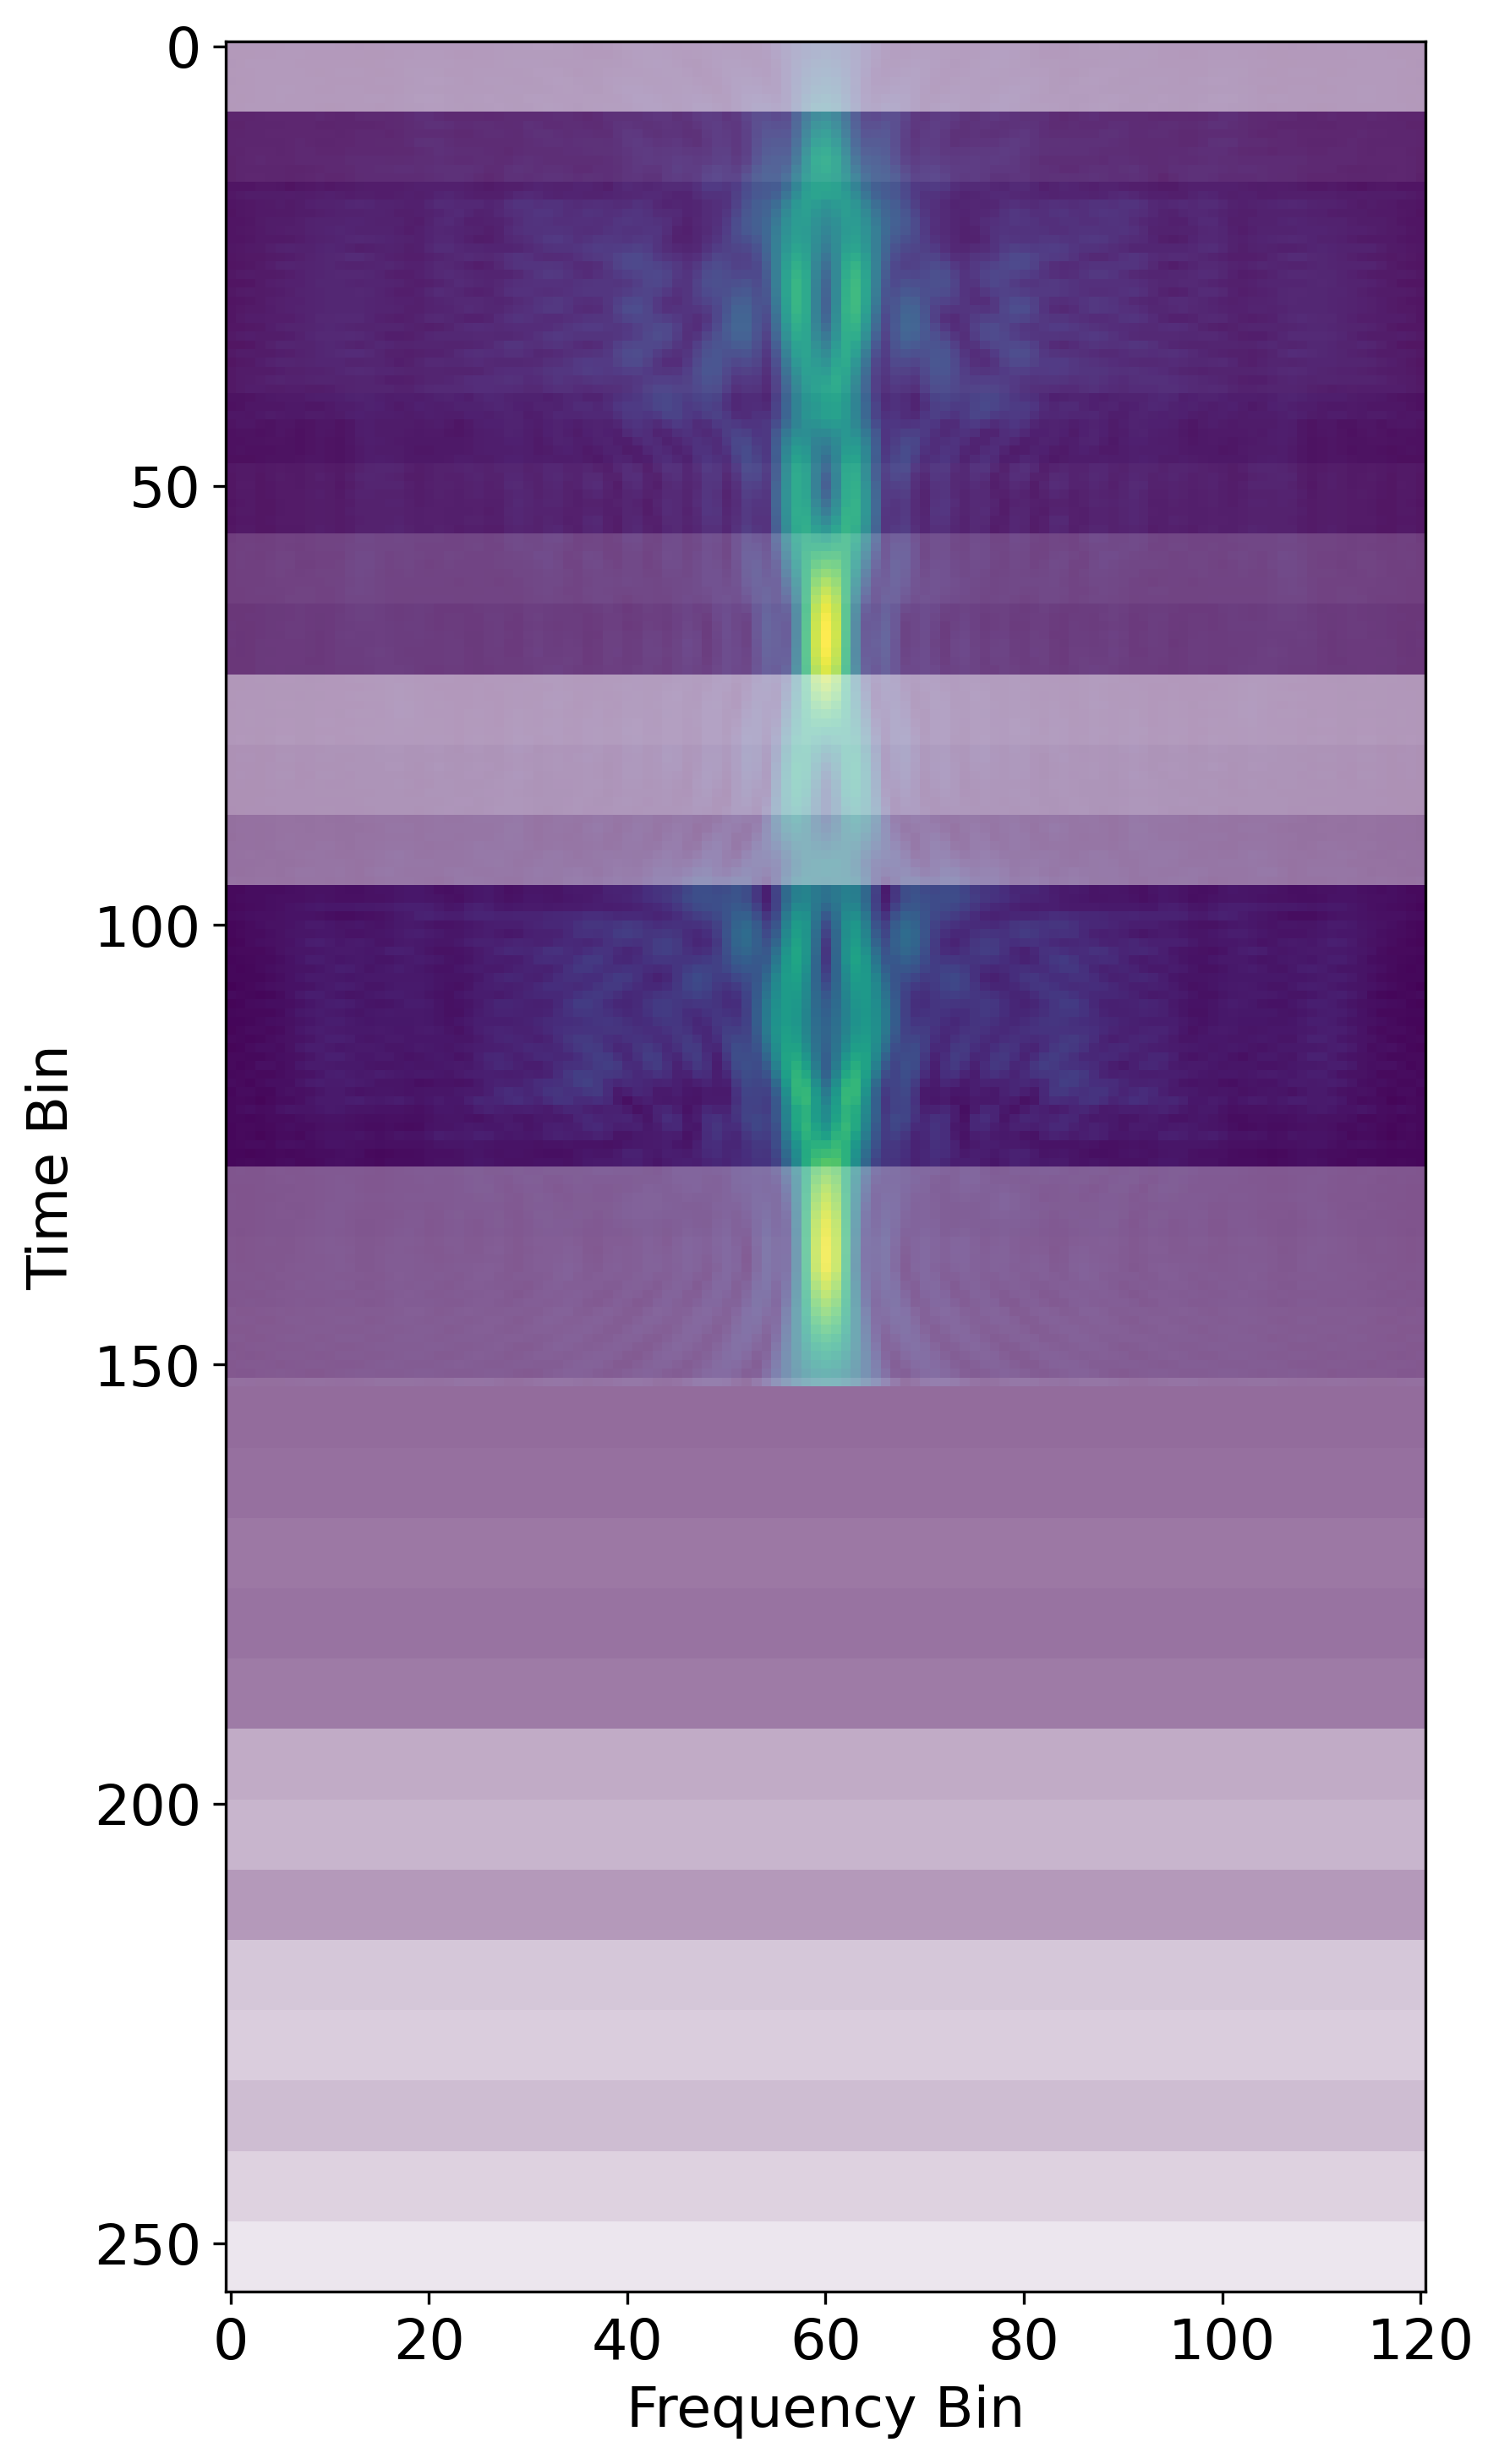

In [25]:
for count, i in enumerate(index_list_class_0):
    patch_map = attn_patch_score[i].reshape(grid_h, grid_w)
    input_map = inputs[i]
    cls_input_amp = np.mean(np.abs(input_map), axis=0)  # average over samples and links
    
    label = y[i]
    label_to_gesture_name[int(label)]

    
    H, W = cls_input_amp.shape
    h = patch_map.shape[0]
    input_heatmap = cls_input_amp
    attention_map = patch_map
    
    title = label_to_gesture_name[int(label)] + " " + str(i)

    # 2. Rescale attention map to match input shape (H, W)
    scale_factor = H // h
    attn_expanded = np.repeat(attention_map, scale_factor, axis=0)
    # If H is not perfectly divisible by h, pad or crop to match exactly H
    if attn_expanded.shape[0] < H:
        padding = np.zeros((H - attn_expanded.shape[0], 1))
        attn_expanded = np.vstack([attn_expanded, padding])
    attn_full = np.tile(attn_expanded, (1, W))

    # 3. Apply Proper Normalization
    # Normalize the heatmap values to [0, 1] for the colormap
    norm = plt.Normalize(vmin=input_heatmap.min(), vmax=input_heatmap.max())
    cmap = plt.get_cmap('viridis')
    heatmap_rgb = cmap(norm(input_heatmap)) # This returns a (H, W, 4) array

    # 4. Apply Attention to Alpha Channel
    # Normalize attention to [0.1, 1.0] so background is still faintly visible
    attn_min, attn_max = attn_full.min(), attn_full.max()
    attn_alpha = 0.1 + (attn_full - attn_min) * (0.9 / (attn_max - attn_min))

    # Set the 4th channel (Alpha) to our attention values
    heatmap_rgb[:, :, 3] = attn_alpha 

    # 5. Visualization
    # set the fontsize 
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(figsize=(6, 10), dpi=300)
    ax.imshow(heatmap_rgb, aspect='auto')
    # ax.set_title(title, fontsize=12)
    ax.set_xlabel("Frequency Bin")
    ax.set_ylabel("Time Bin")

    plt.tight_layout()
    plt.show()
    # if count > 10:
    #     break


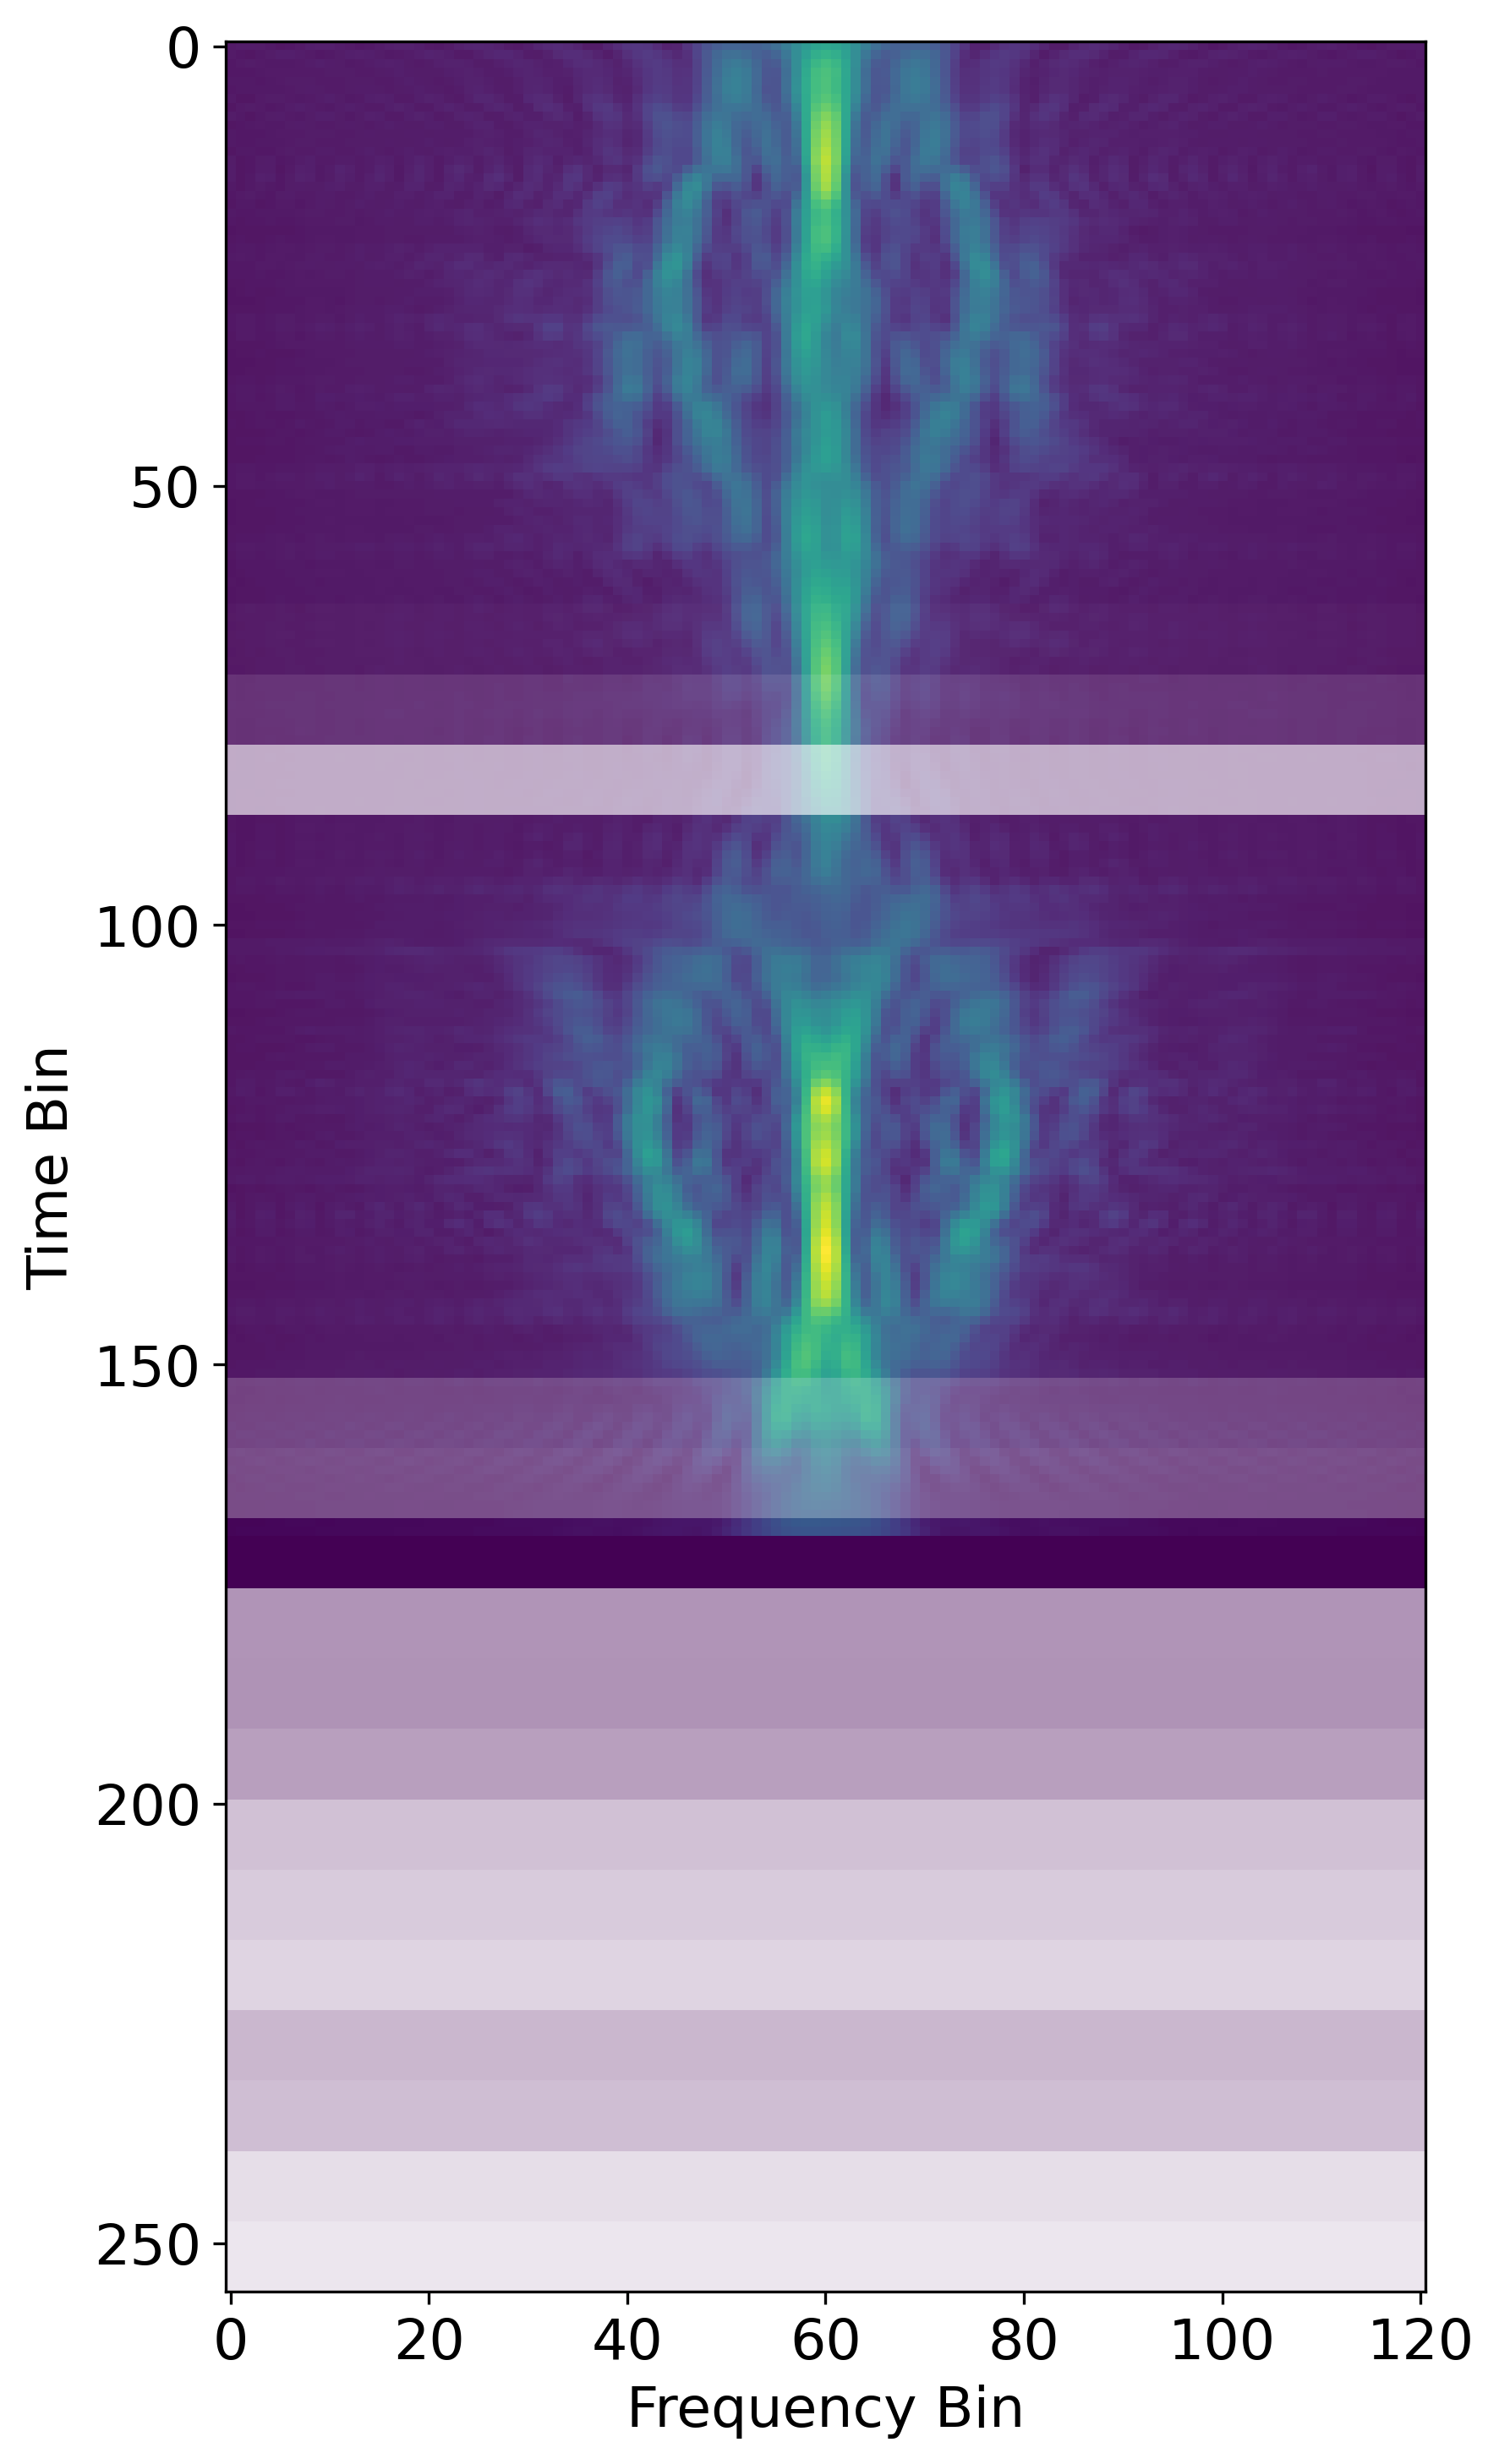

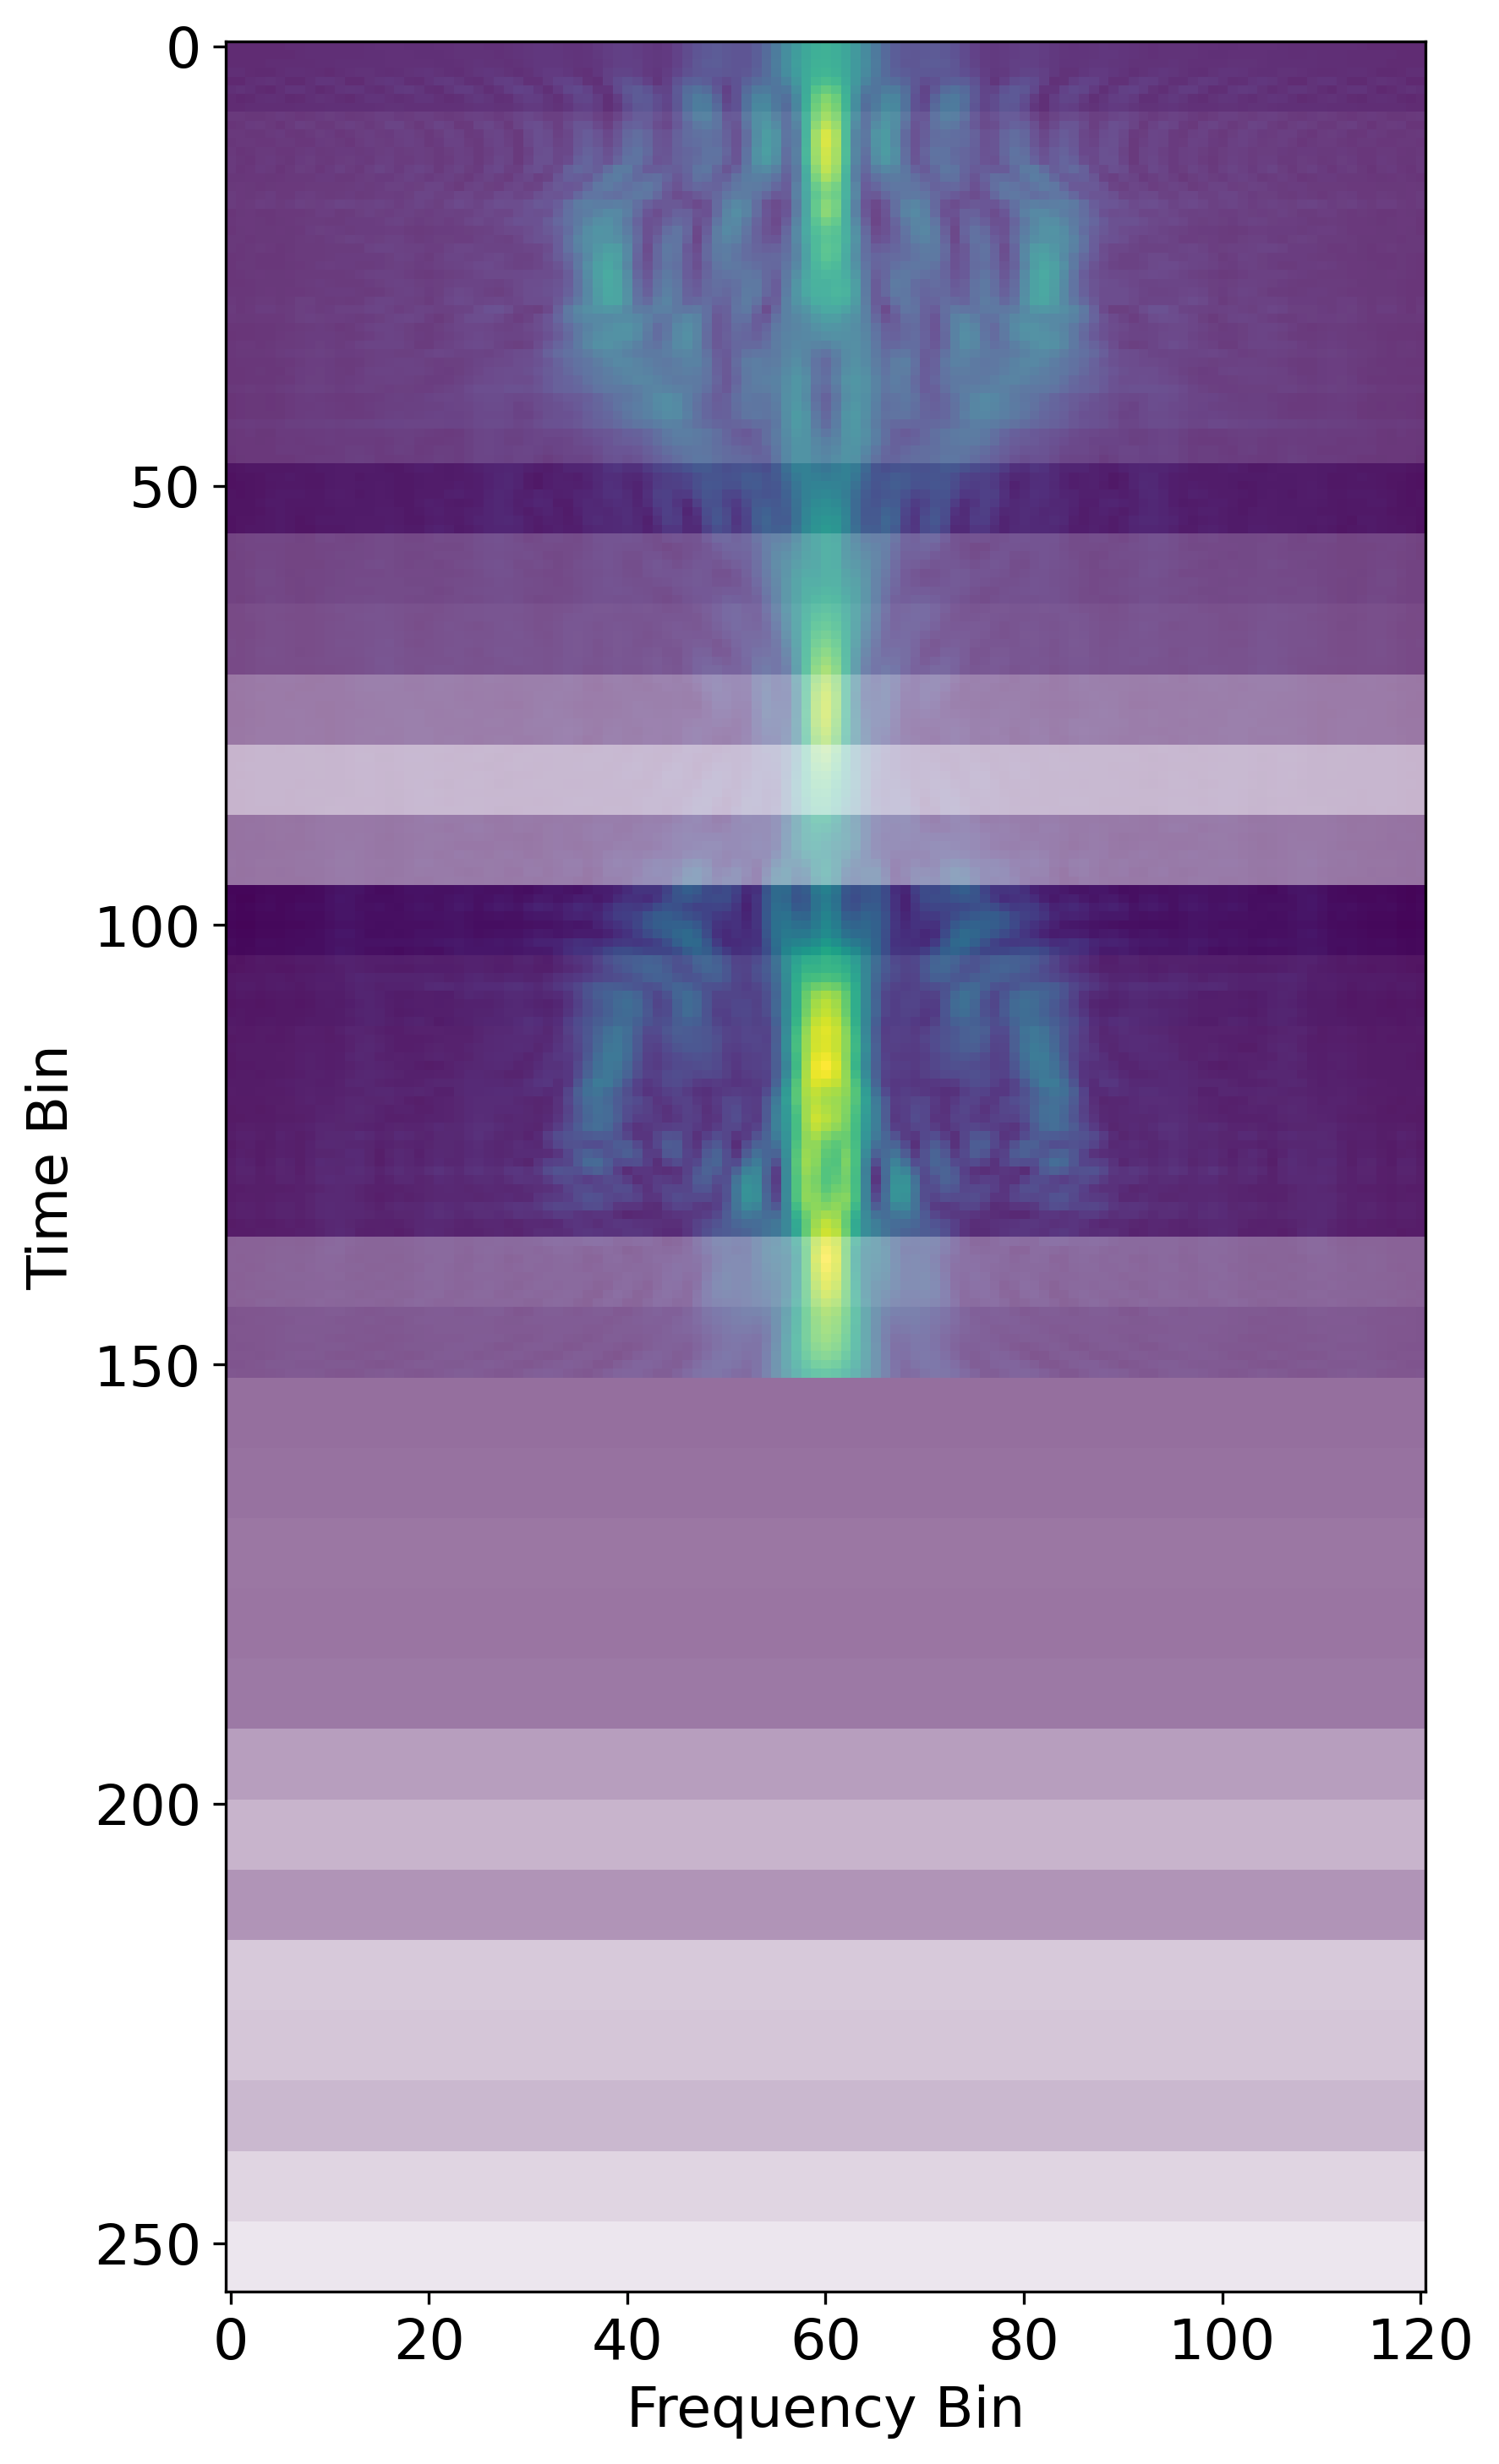

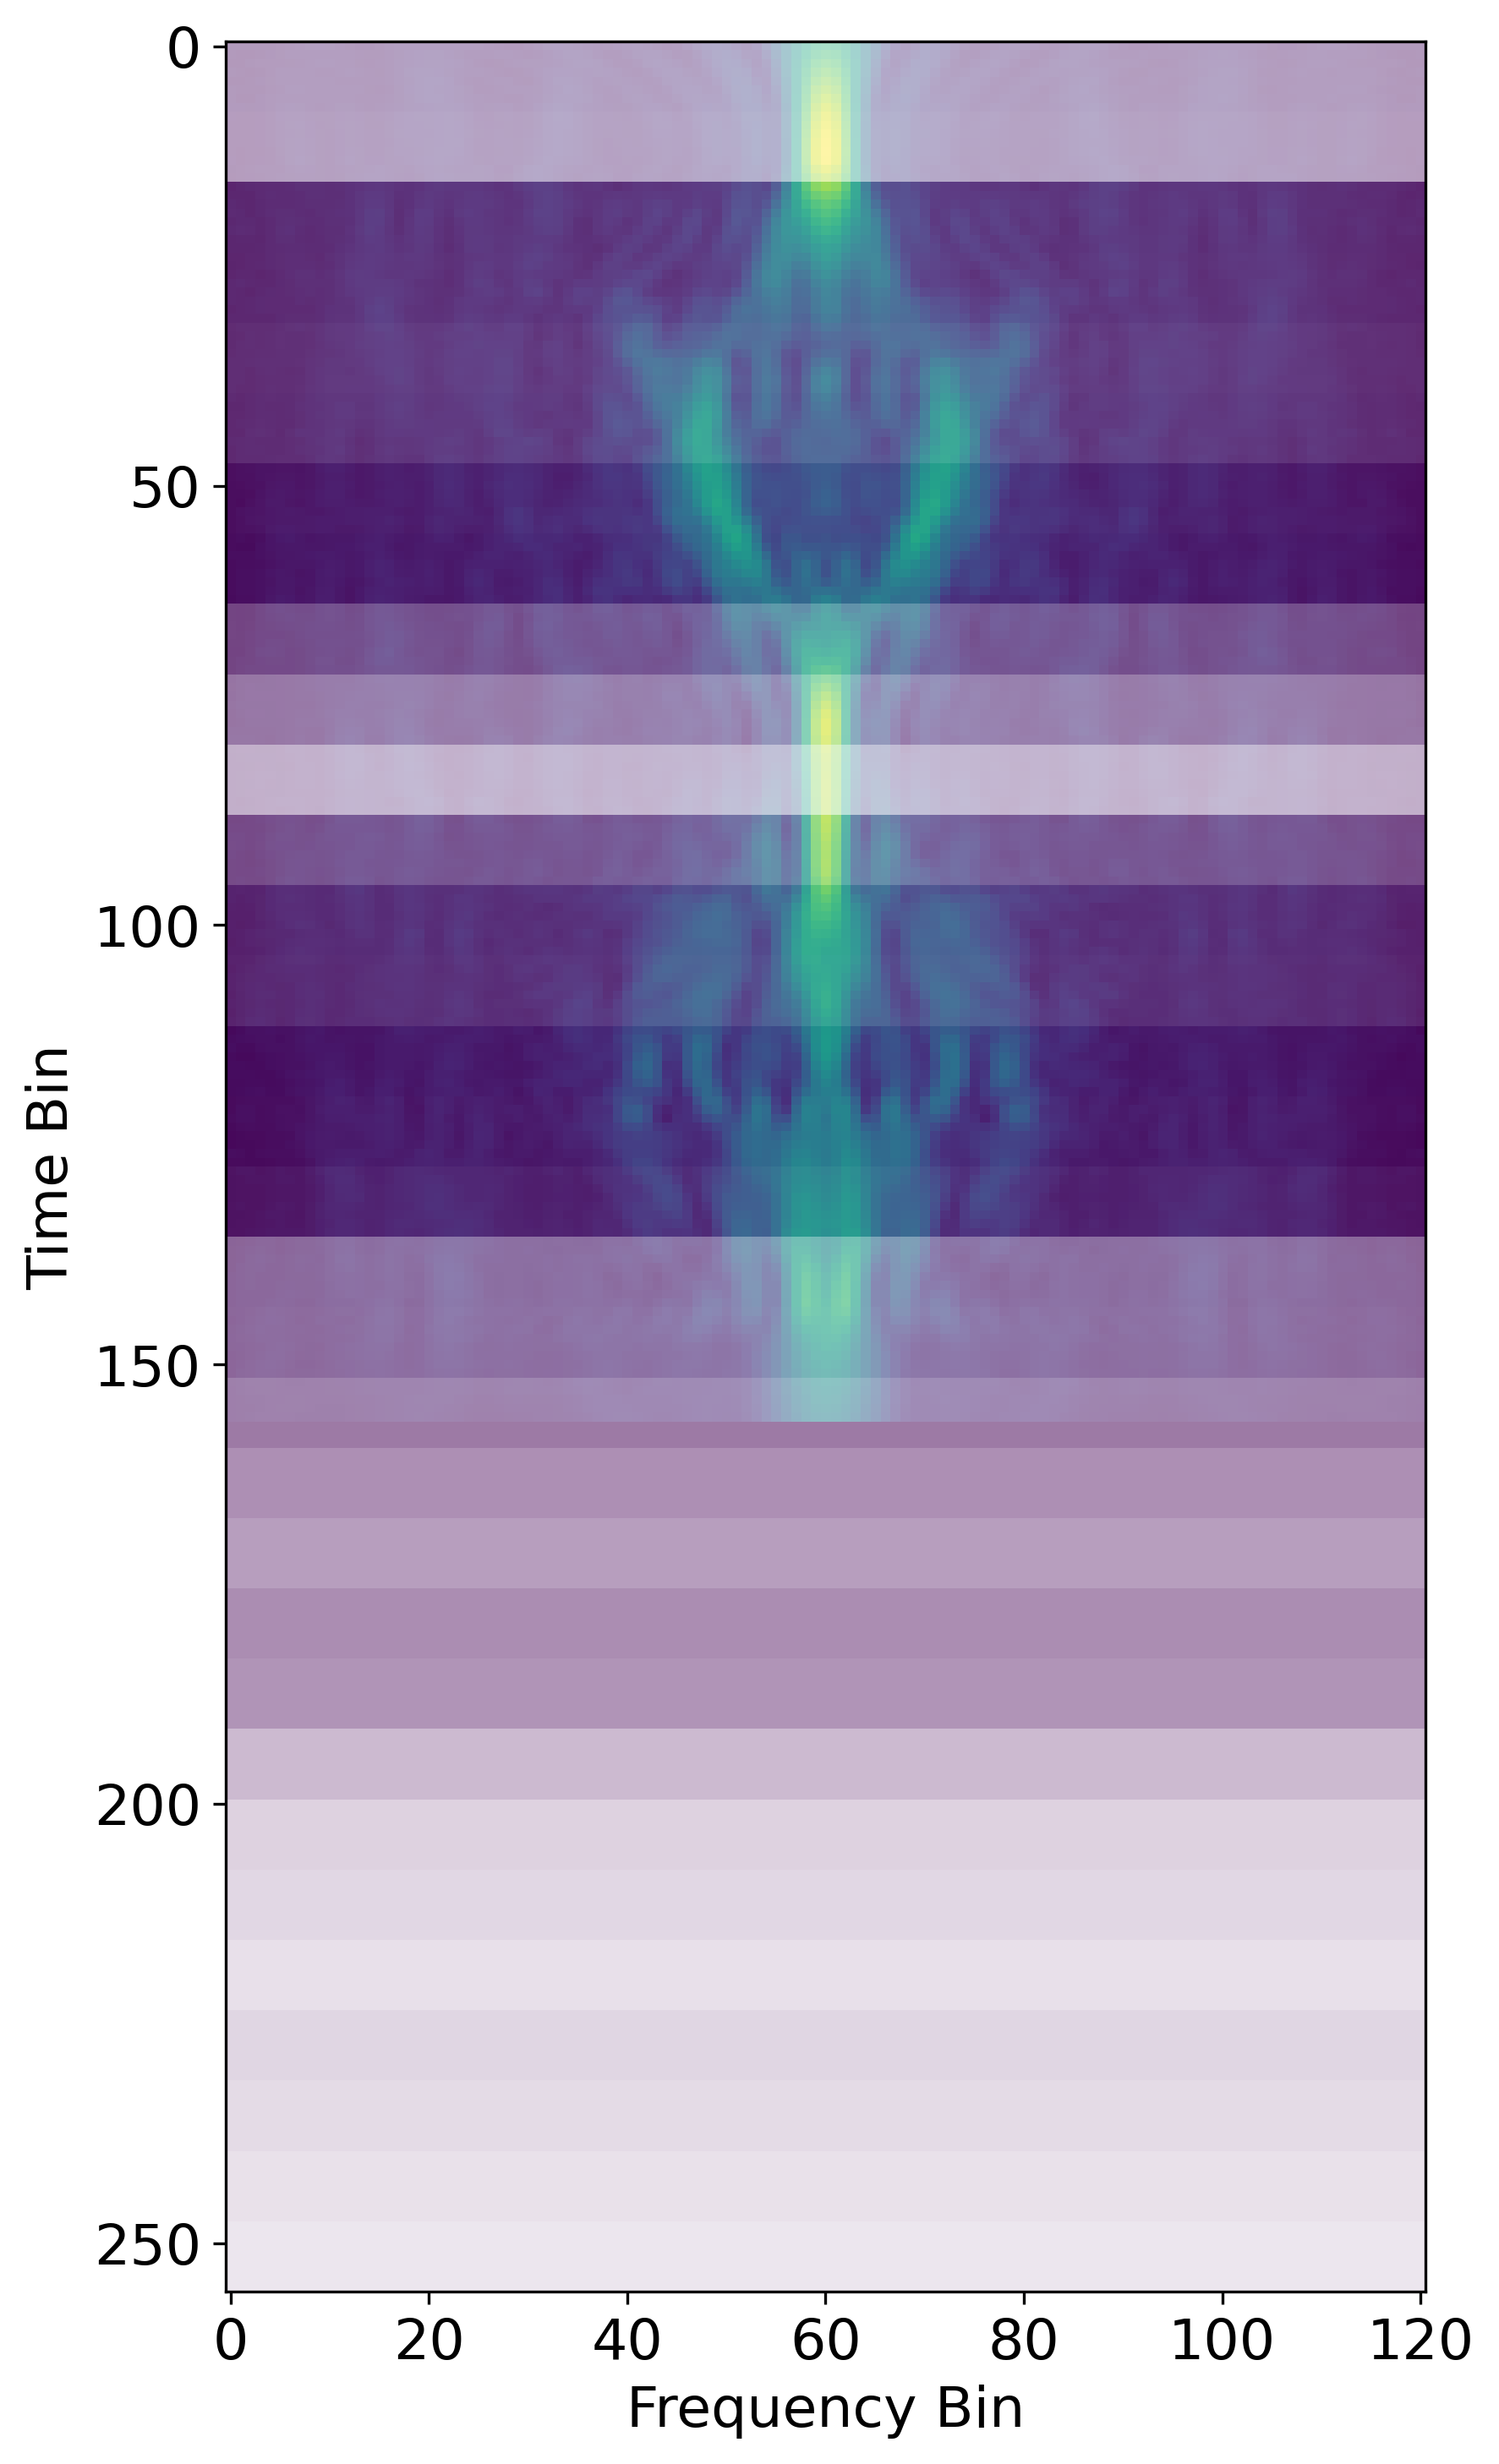

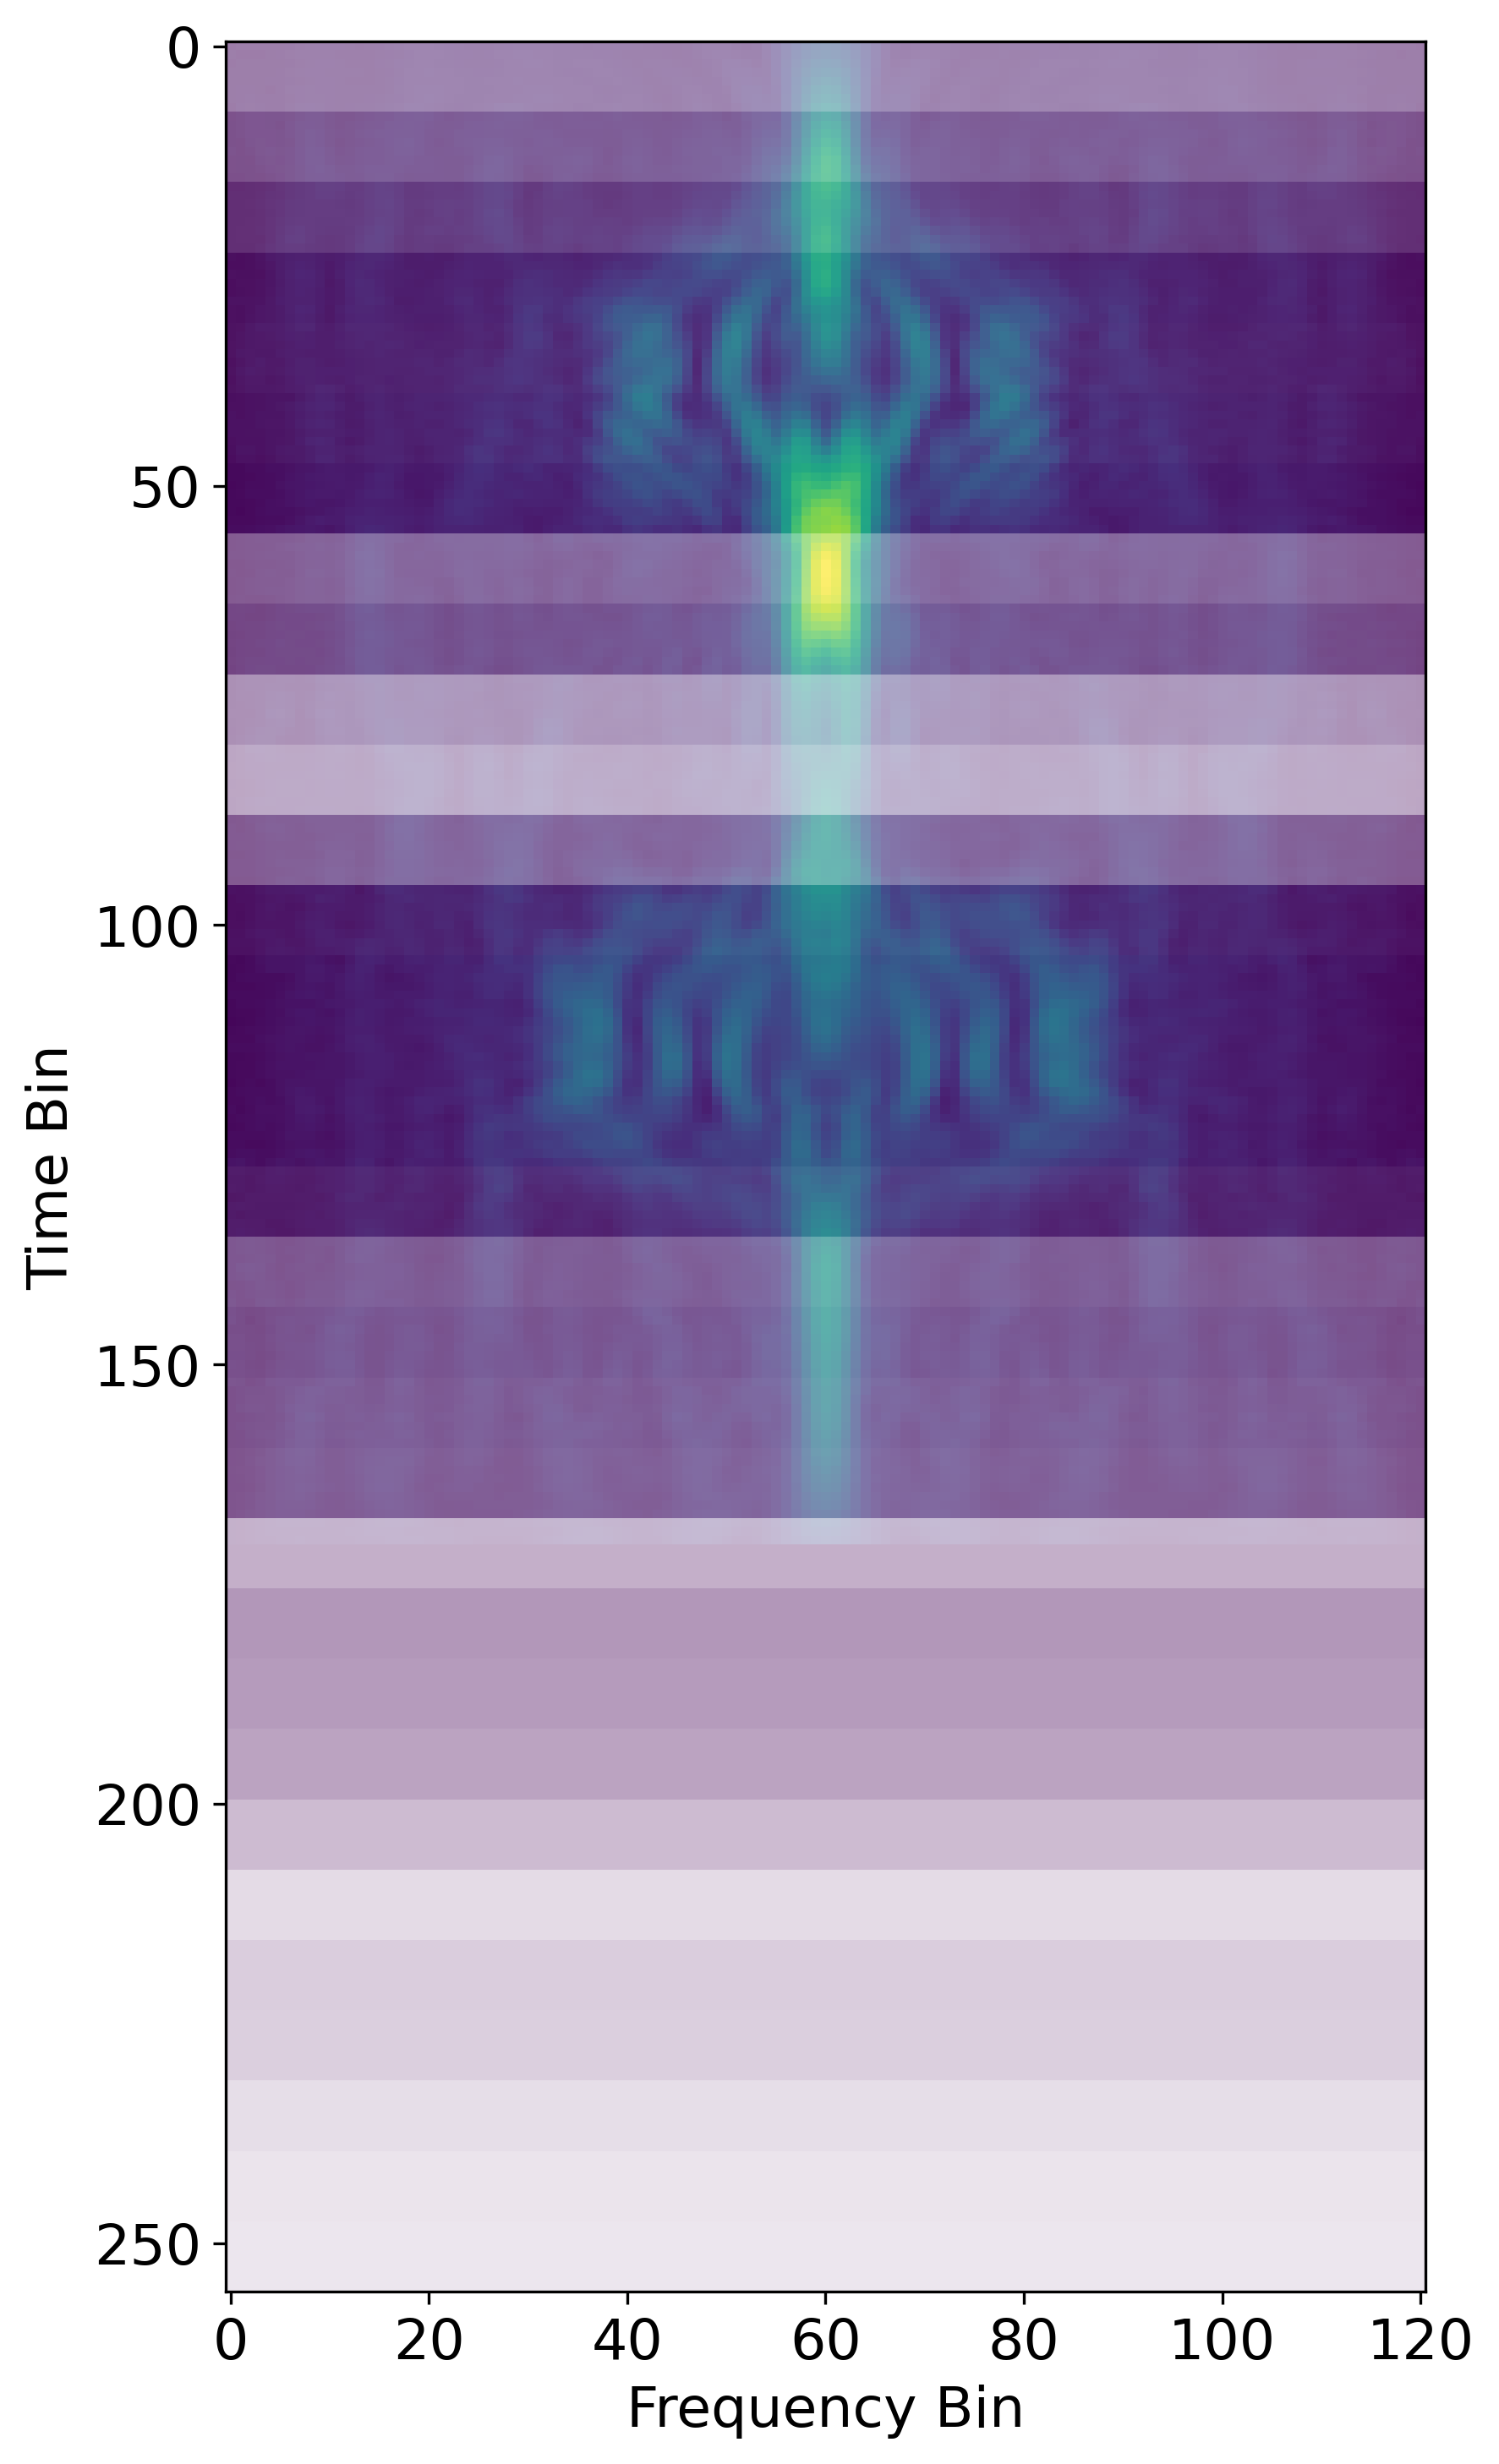

In [26]:
for count, i in enumerate(index_list_class_1):
    patch_map = attn_patch_score[i].reshape(grid_h, grid_w)
    input_map = inputs[i]
    cls_input_amp = np.mean(np.abs(input_map), axis=0)  # average over samples and links
    
    label = y[i]
    label_to_gesture_name[int(label)]

    
    H, W = cls_input_amp.shape
    h = patch_map.shape[0]
    input_heatmap = cls_input_amp
    attention_map = patch_map
    
    title = label_to_gesture_name[int(label)] + " " + str(i)

    # 2. Rescale attention map to match input shape (H, W)
    scale_factor = H // h
    attn_expanded = np.repeat(attention_map, scale_factor, axis=0)
    # If H is not perfectly divisible by h, pad or crop to match exactly H
    if attn_expanded.shape[0] < H:
        padding = np.zeros((H - attn_expanded.shape[0], 1))
        attn_expanded = np.vstack([attn_expanded, padding])
    attn_full = np.tile(attn_expanded, (1, W))

    # 3. Apply Proper Normalization
    # Normalize the heatmap values to [0, 1] for the colormap
    norm = plt.Normalize(vmin=input_heatmap.min(), vmax=input_heatmap.max())
    cmap = plt.get_cmap('viridis')
    heatmap_rgb = cmap(norm(input_heatmap)) # This returns a (H, W, 4) array

    # 4. Apply Attention to Alpha Channel
    # Normalize attention to [0.1, 1.0] so background is still faintly visible
    attn_min, attn_max = attn_full.min(), attn_full.max()
    attn_alpha = 0.1 + (attn_full - attn_min) * (0.9 / (attn_max - attn_min))

    # Set the 4th channel (Alpha) to our attention values
    heatmap_rgb[:, :, 3] = attn_alpha 

    # 5. Visualization
    # set the fontsize 
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(figsize=(6, 10), dpi=300)
    ax.imshow(heatmap_rgb, aspect='auto')
    # ax.set_title(title, fontsize=12)
    ax.set_xlabel("Frequency Bin")
    ax.set_ylabel("Time Bin")

    plt.tight_layout()
    plt.show()
    # if count > 10:
    #     break


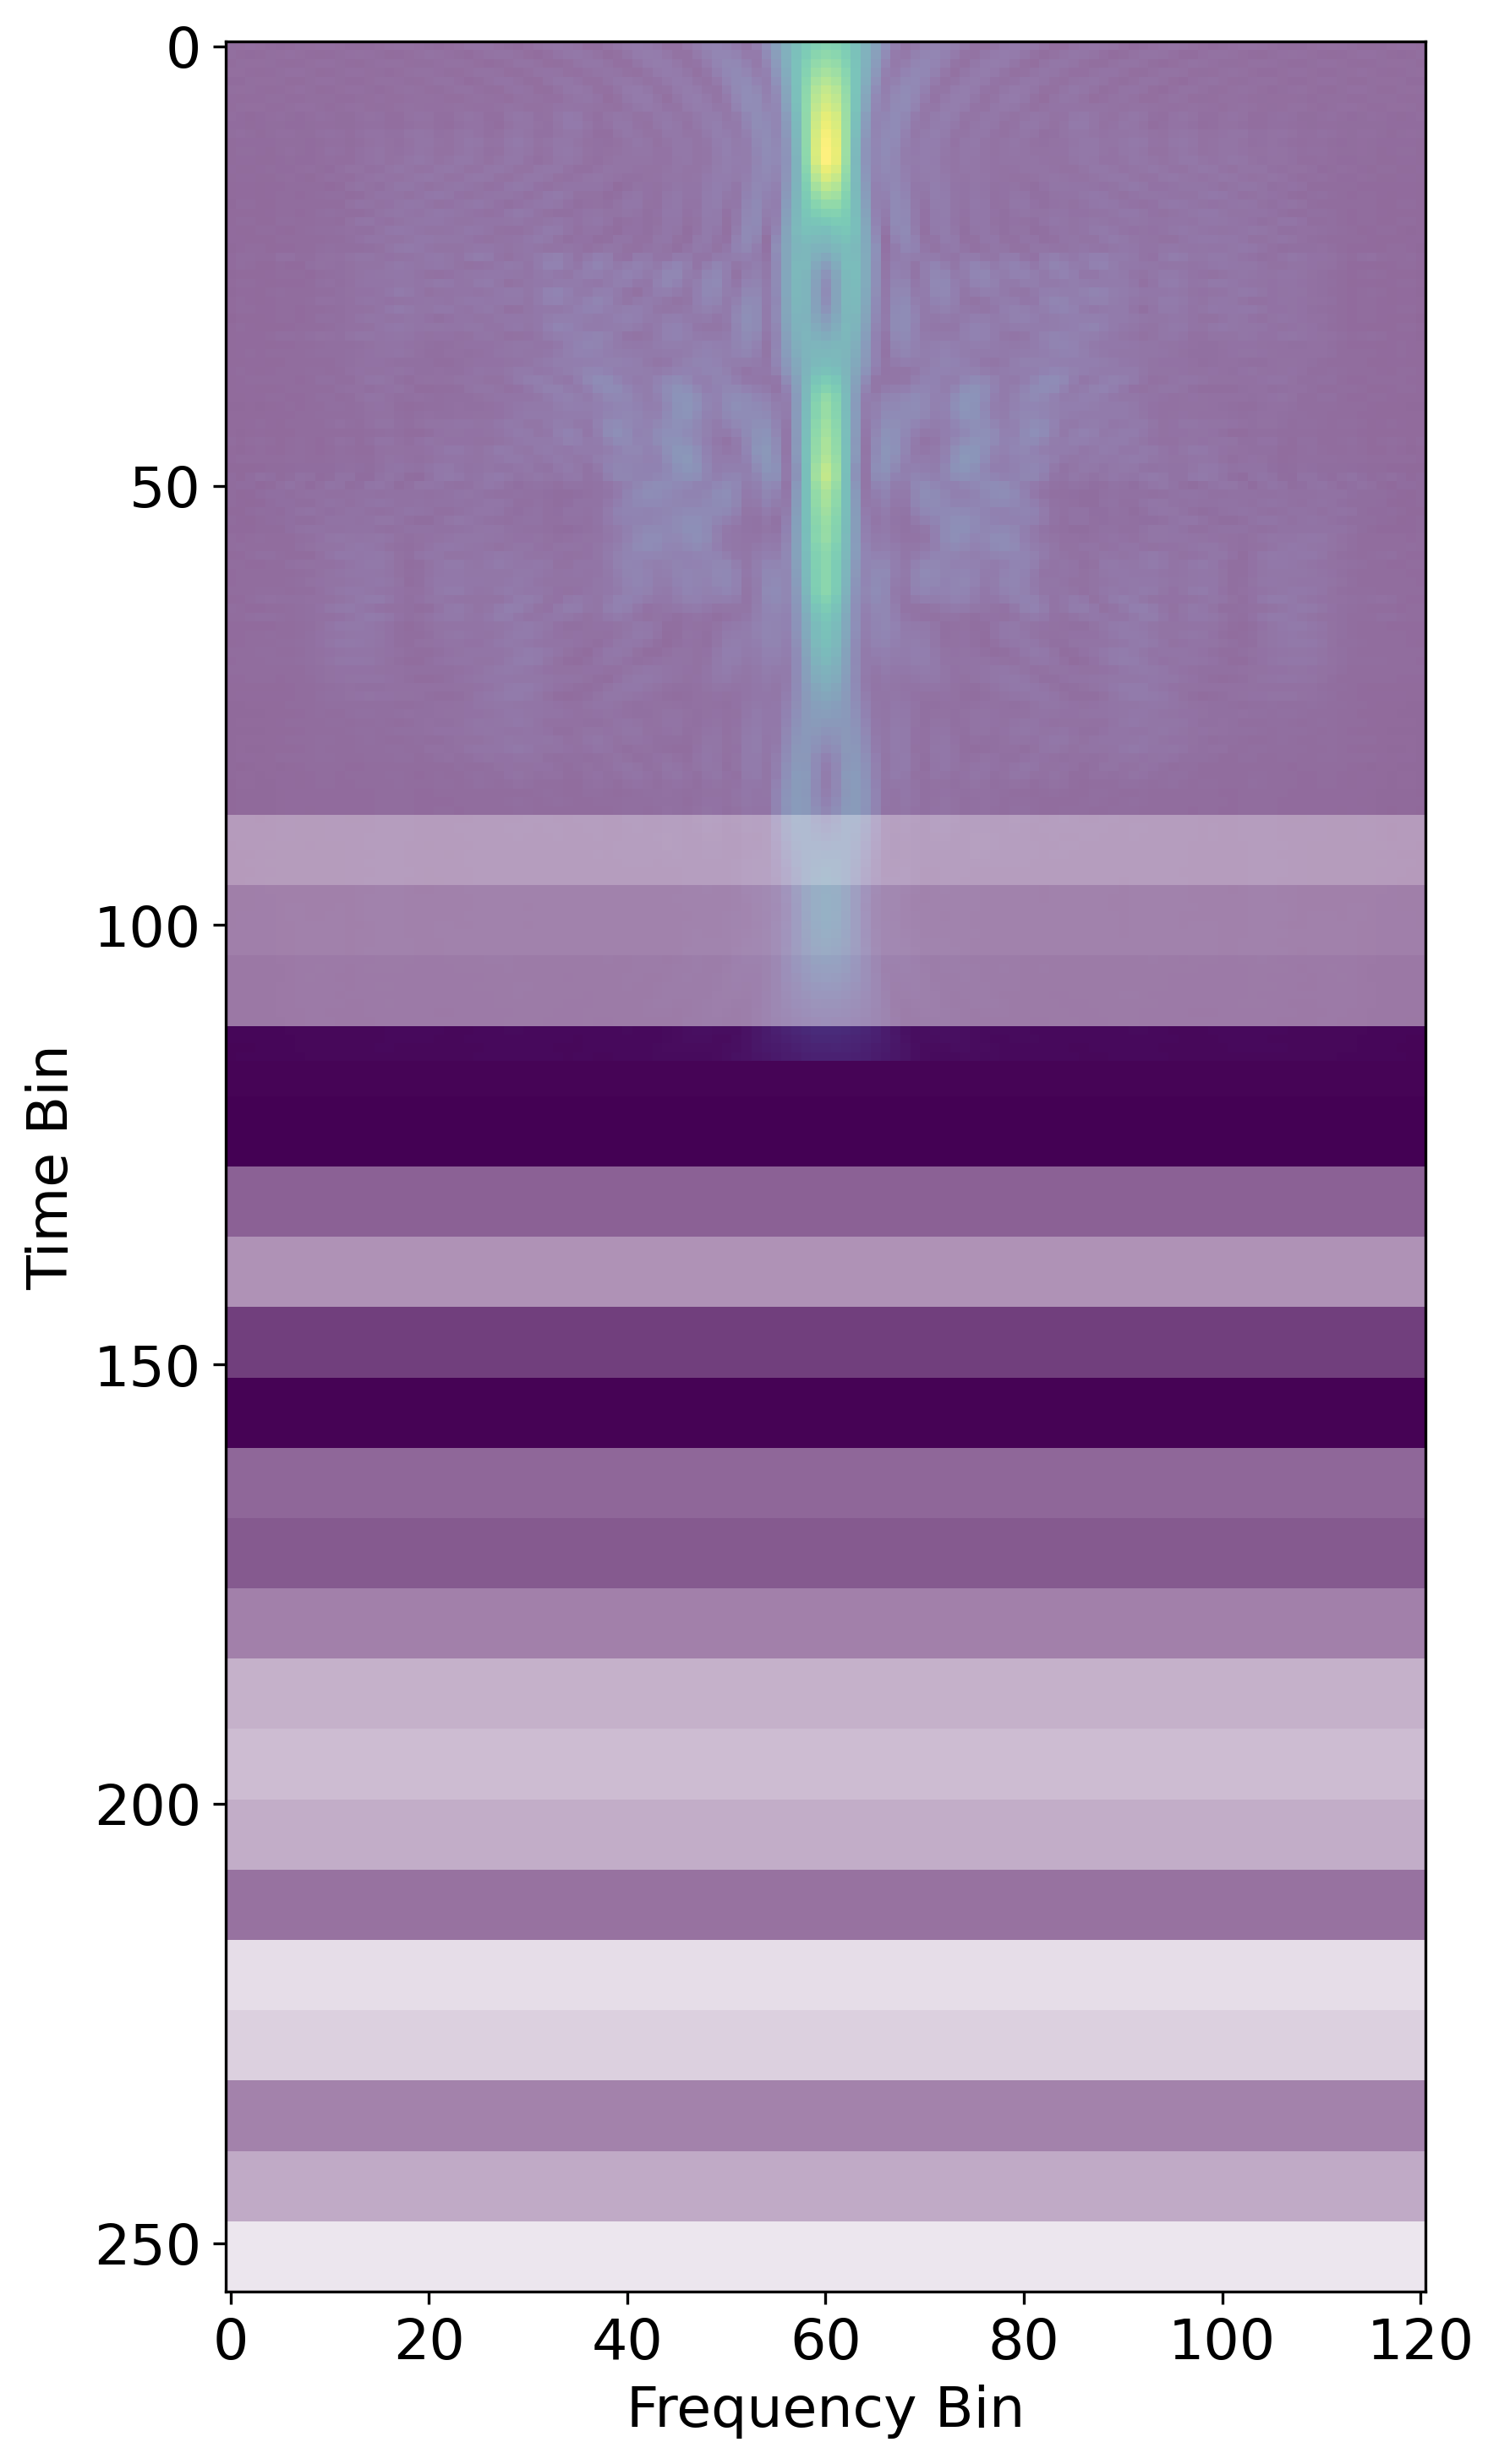

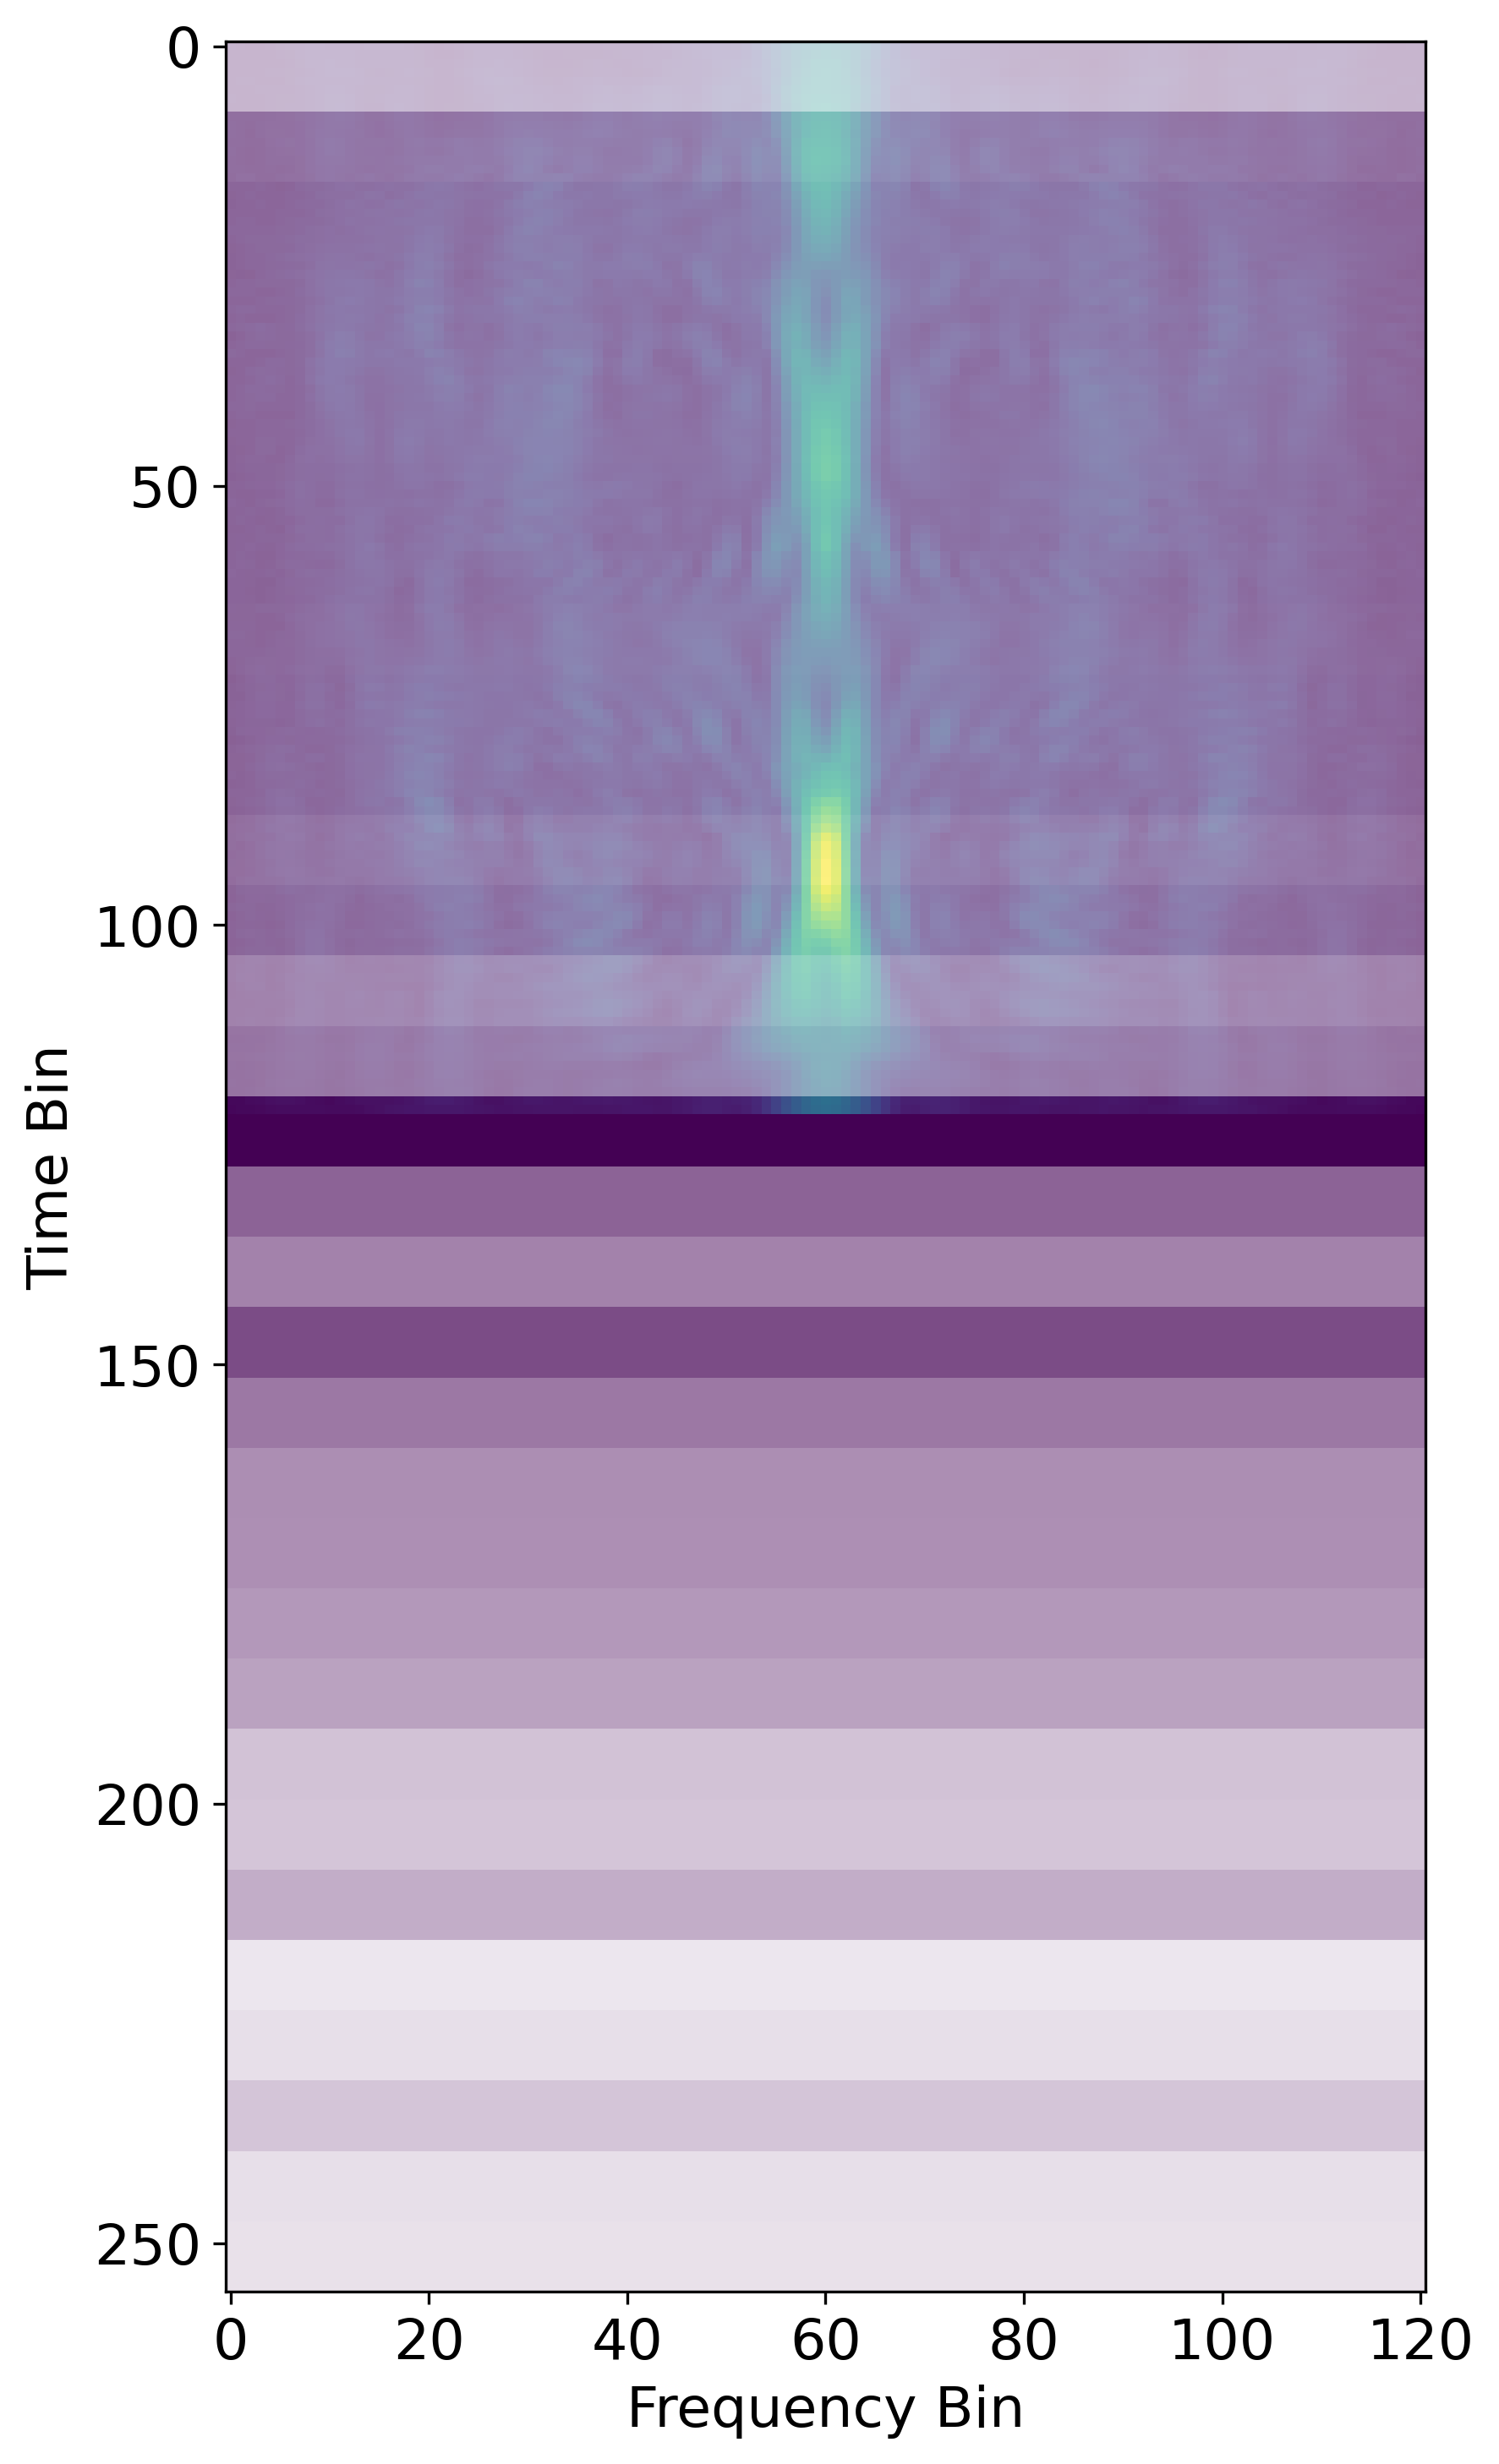

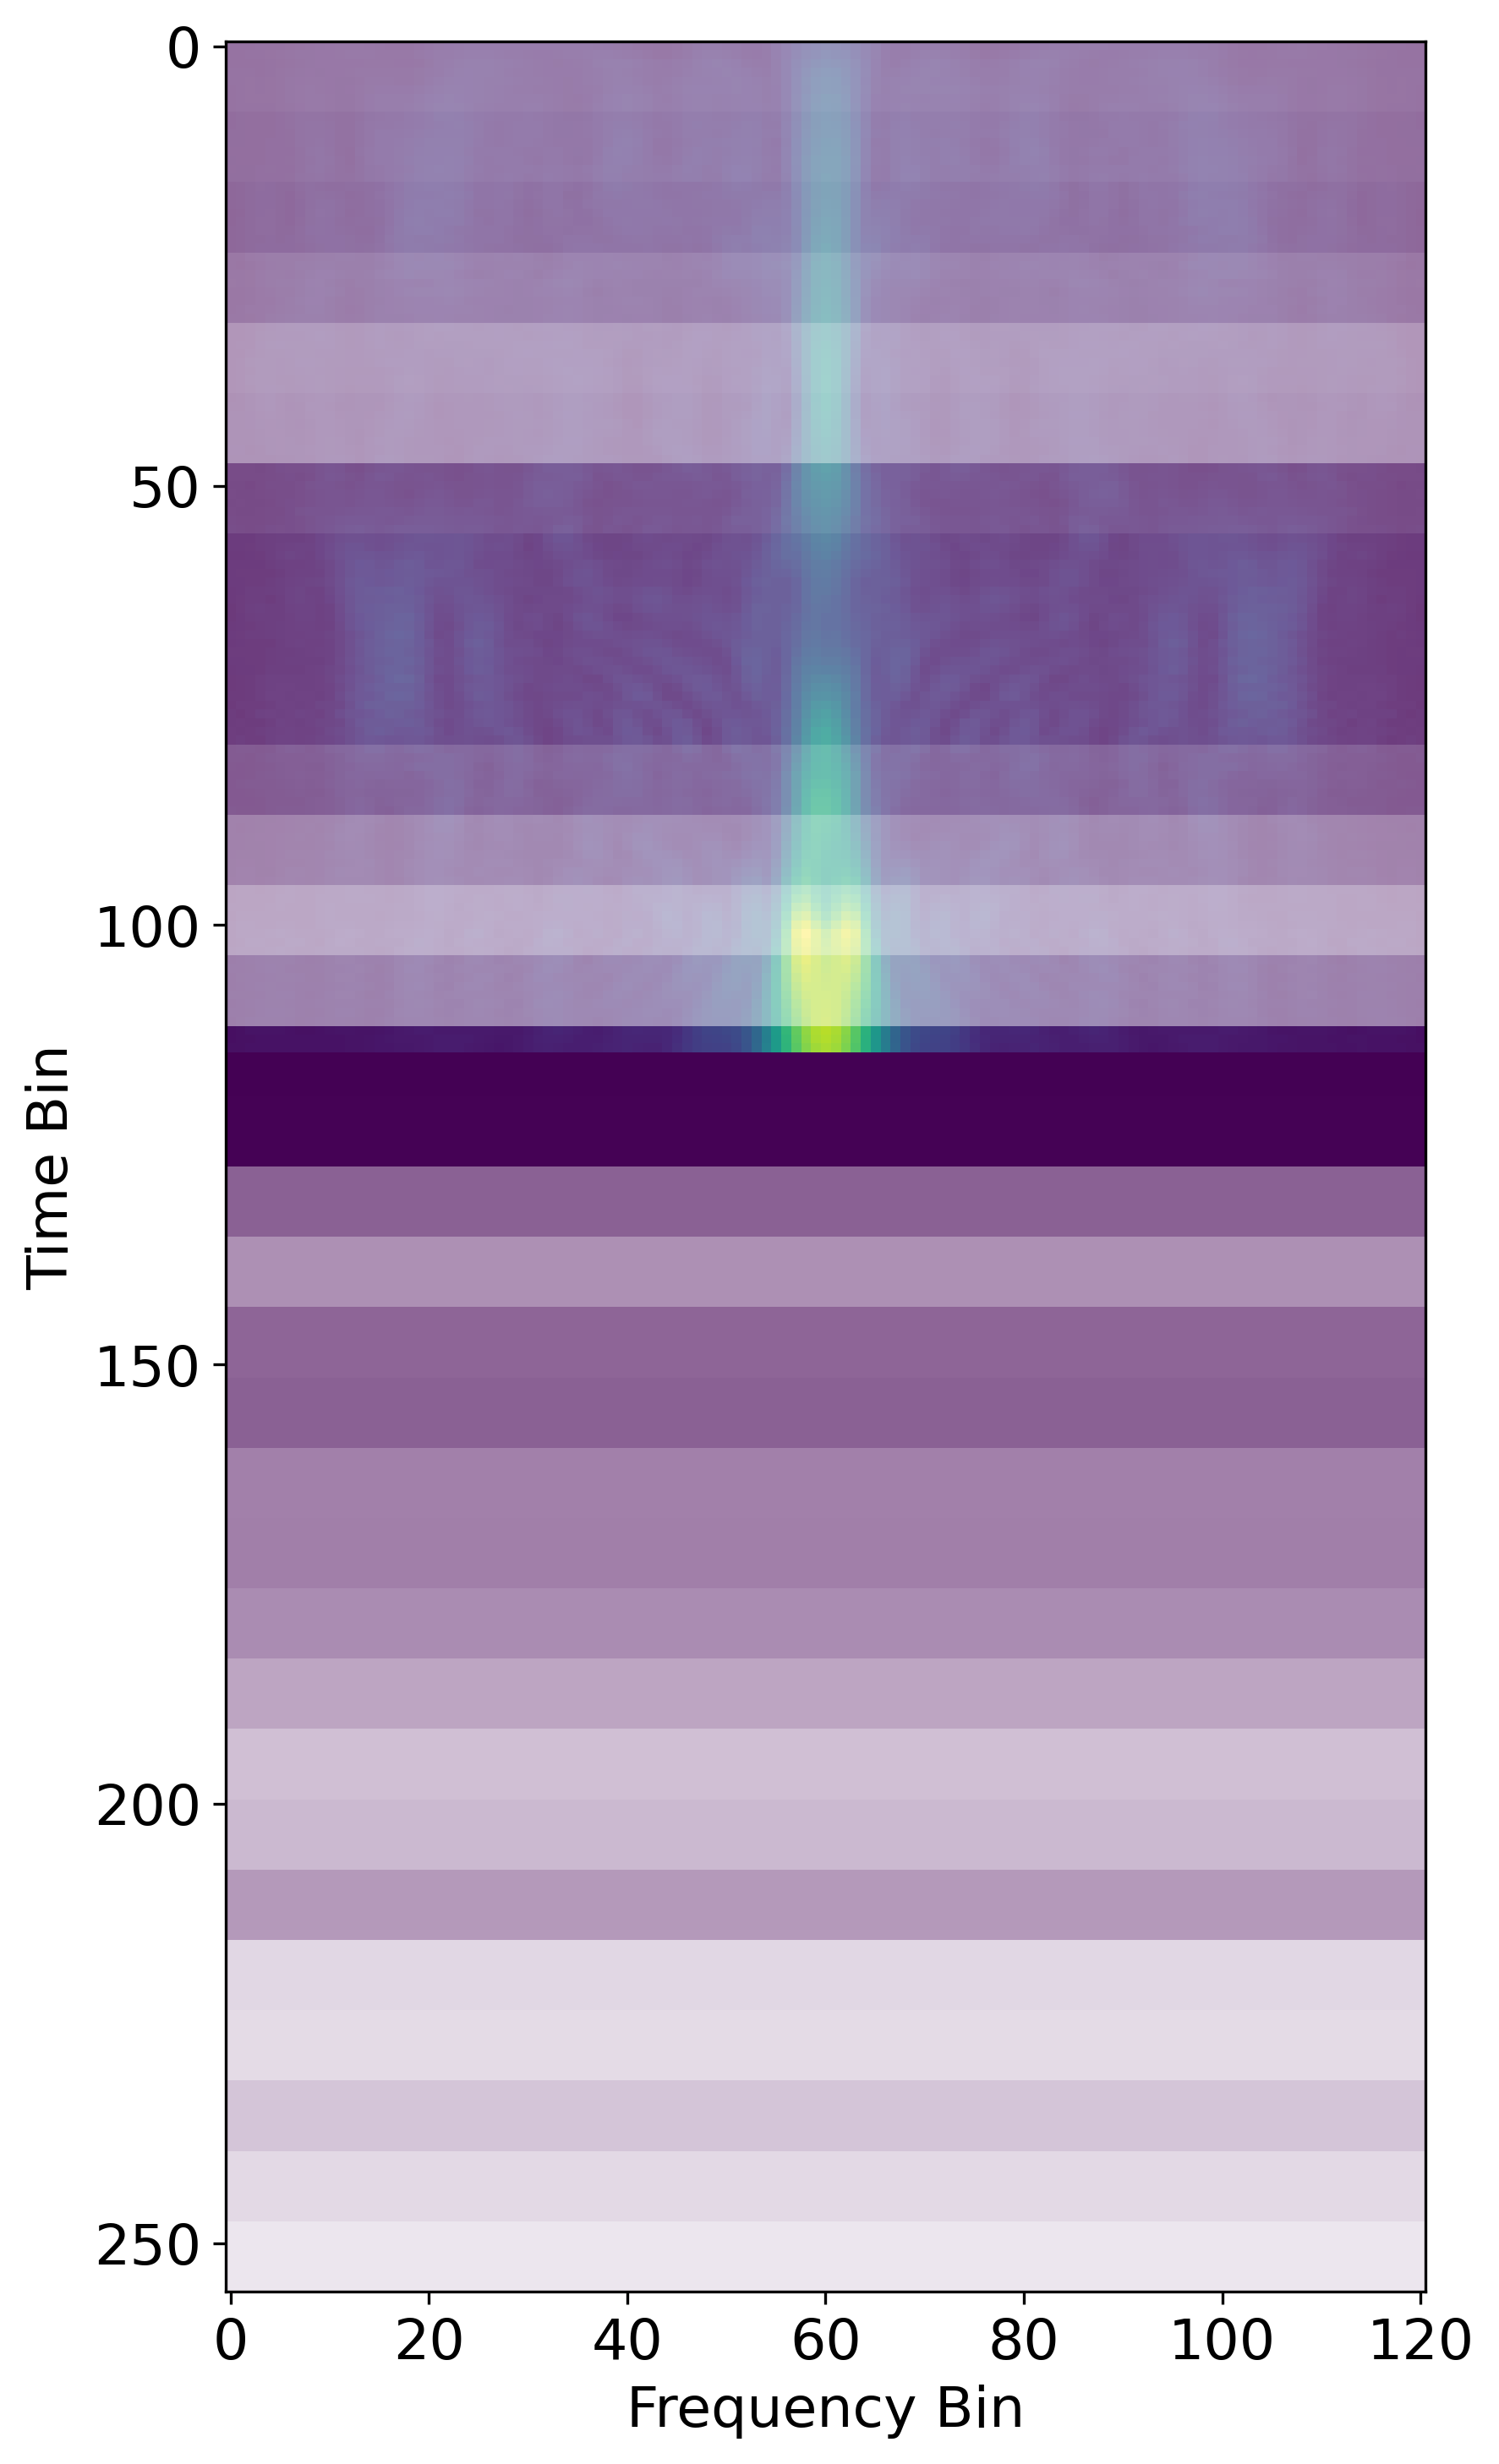

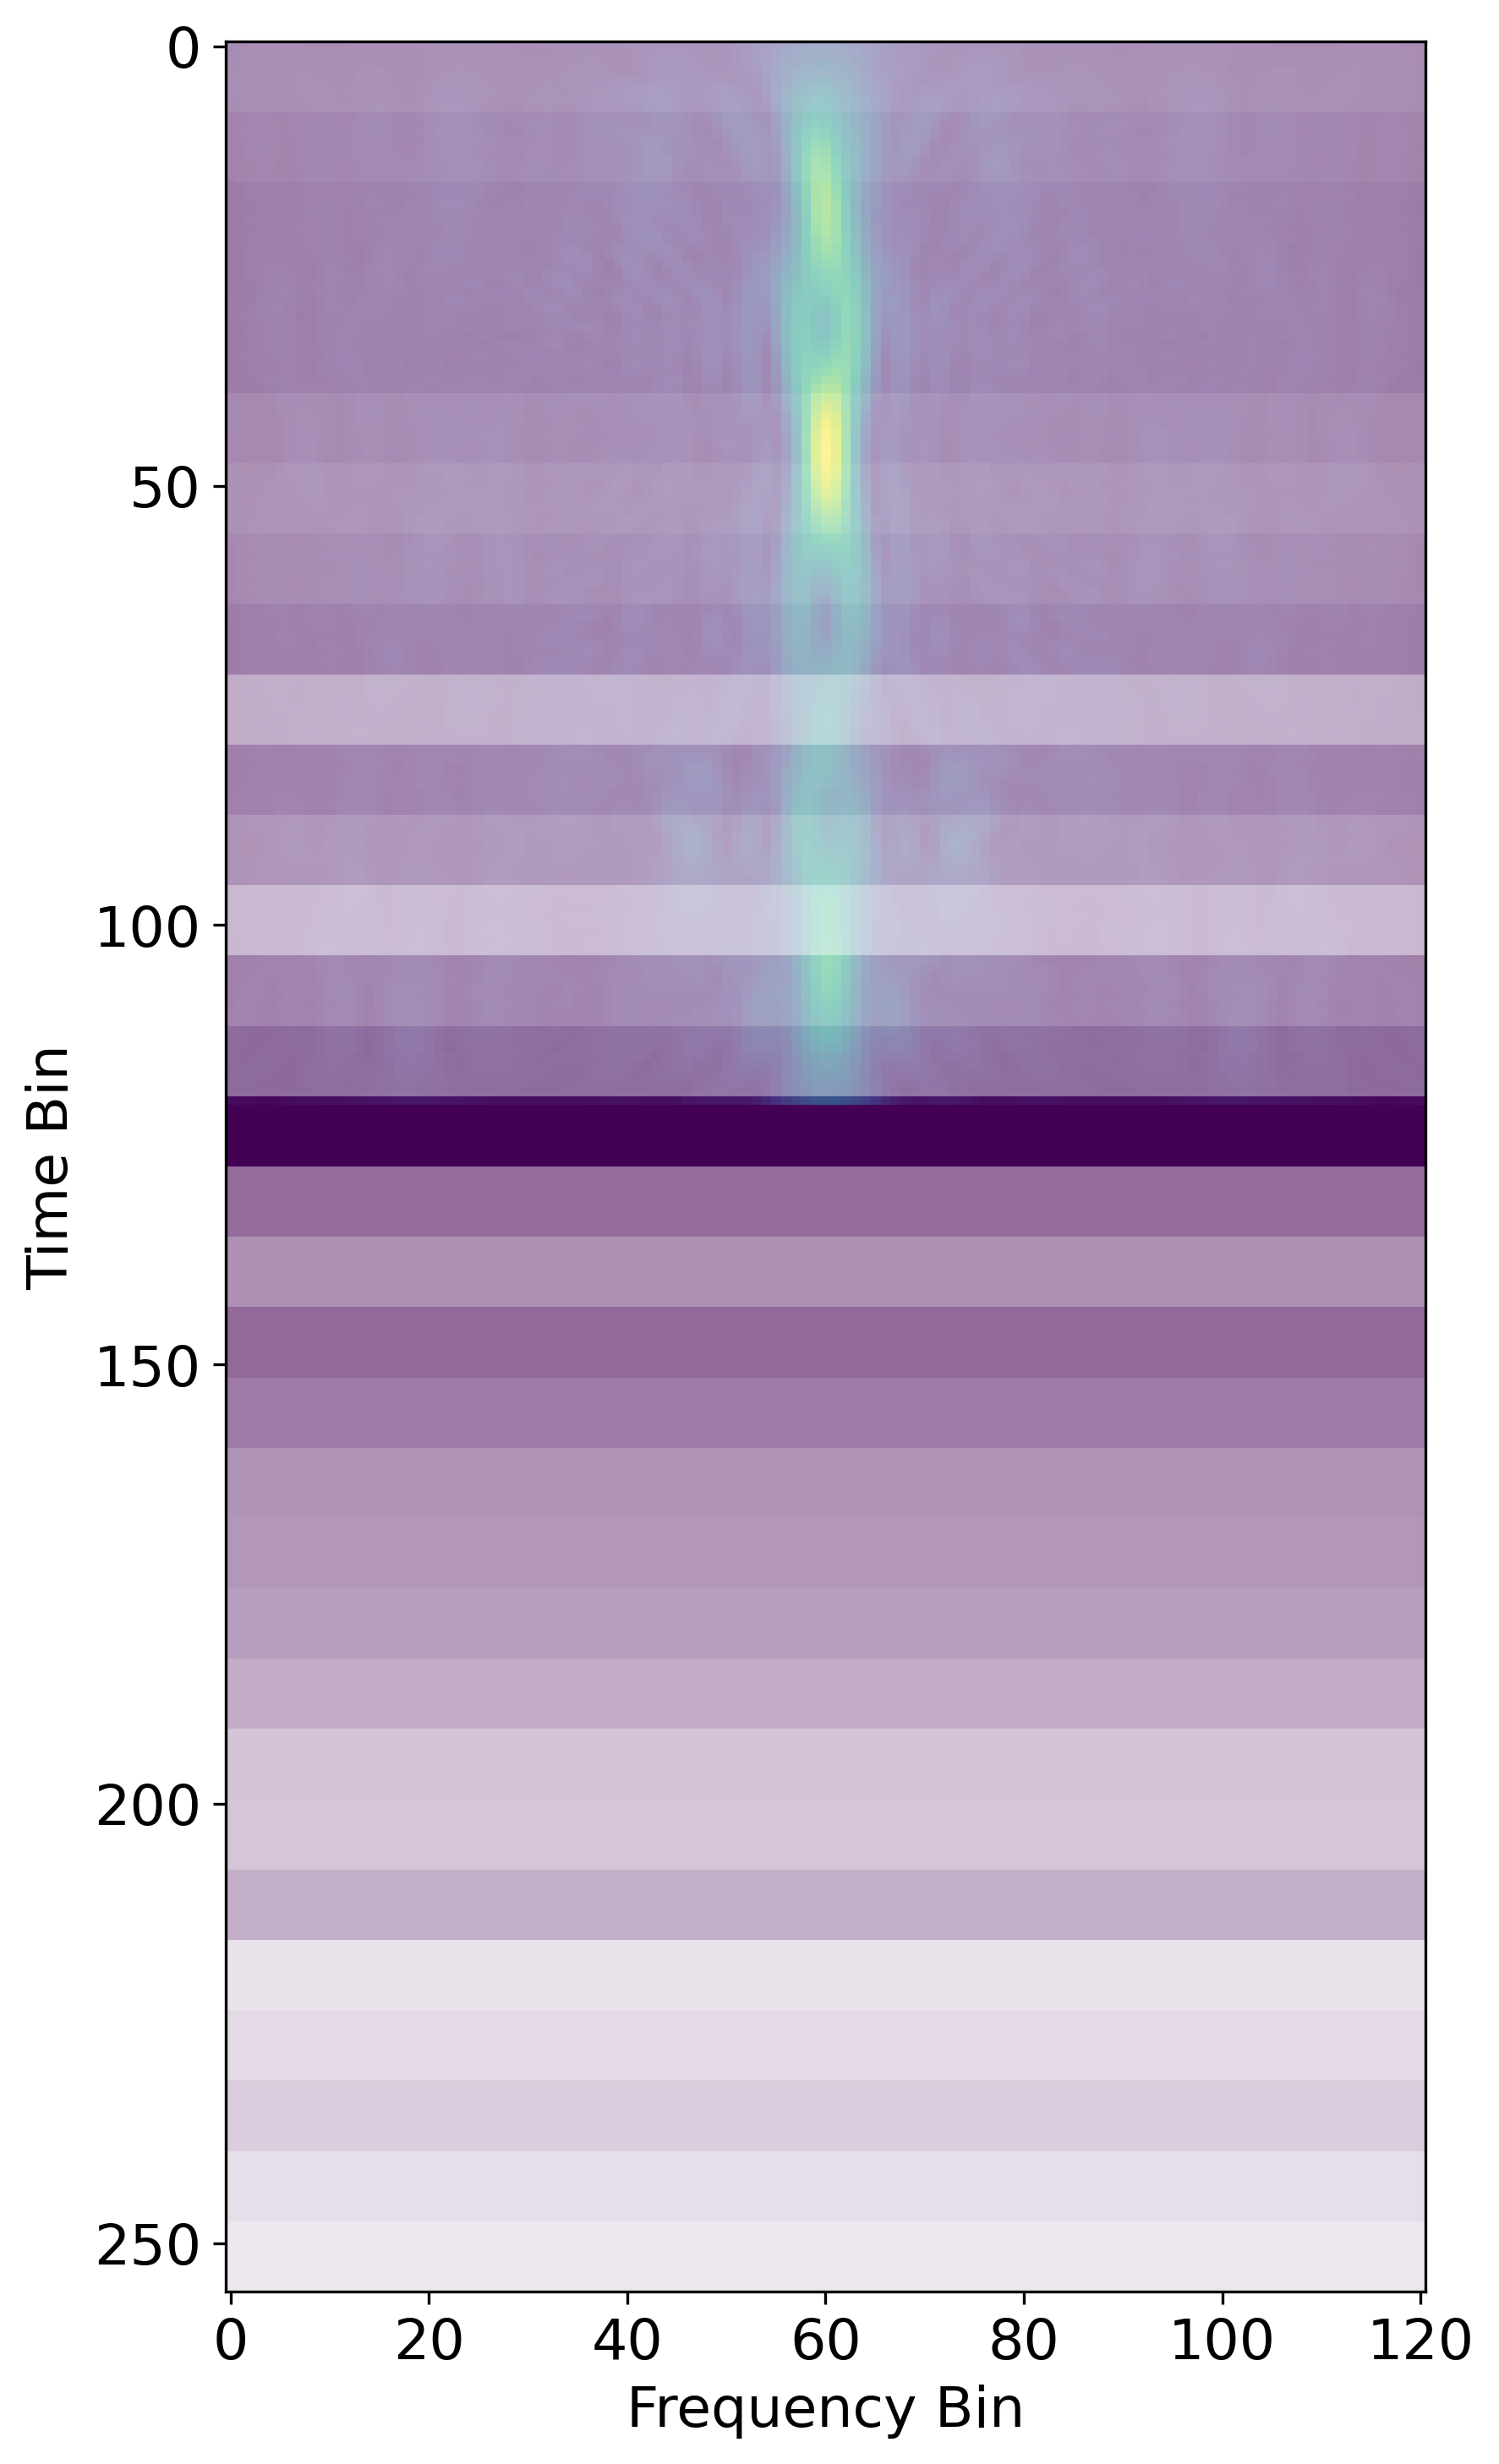

In [27]:
for count, i in enumerate(index_list_class_2):
    patch_map = attn_patch_score[i].reshape(grid_h, grid_w)
    input_map = inputs[i]
    cls_input_amp = np.mean(np.abs(input_map), axis=0)  # average over samples and links
    
    label = y[i]
    label_to_gesture_name[int(label)]

    
    H, W = cls_input_amp.shape
    h = patch_map.shape[0]
    input_heatmap = cls_input_amp
    attention_map = patch_map
    
    title = label_to_gesture_name[int(label)] + " " + str(i)

    # 2. Rescale attention map to match input shape (H, W)
    scale_factor = H // h
    attn_expanded = np.repeat(attention_map, scale_factor, axis=0)
    # If H is not perfectly divisible by h, pad or crop to match exactly H
    if attn_expanded.shape[0] < H:
        padding = np.zeros((H - attn_expanded.shape[0], 1))
        attn_expanded = np.vstack([attn_expanded, padding])
    attn_full = np.tile(attn_expanded, (1, W))

    # 3. Apply Proper Normalization
    # Normalize the heatmap values to [0, 1] for the colormap
    norm = plt.Normalize(vmin=input_heatmap.min(), vmax=input_heatmap.max())
    cmap = plt.get_cmap('viridis')
    heatmap_rgb = cmap(norm(input_heatmap)) # This returns a (H, W, 4) array

    # 4. Apply Attention to Alpha Channel
    # Normalize attention to [0.1, 1.0] so background is still faintly visible
    attn_min, attn_max = attn_full.min(), attn_full.max()
    attn_alpha = 0.1 + (attn_full - attn_min) * (0.9 / (attn_max - attn_min))

    # Set the 4th channel (Alpha) to our attention values
    heatmap_rgb[:, :, 3] = attn_alpha 

    # 5. Visualization
    # set the fontsize 
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(figsize=(6, 10), dpi=300)
    ax.imshow(heatmap_rgb, aspect='auto')
    # ax.set_title(title, fontsize=12)
    ax.set_xlabel("Frequency Bin")
    ax.set_ylabel("Time Bin")

    plt.tight_layout()
    plt.show()
    # if count > 10:
    #     break


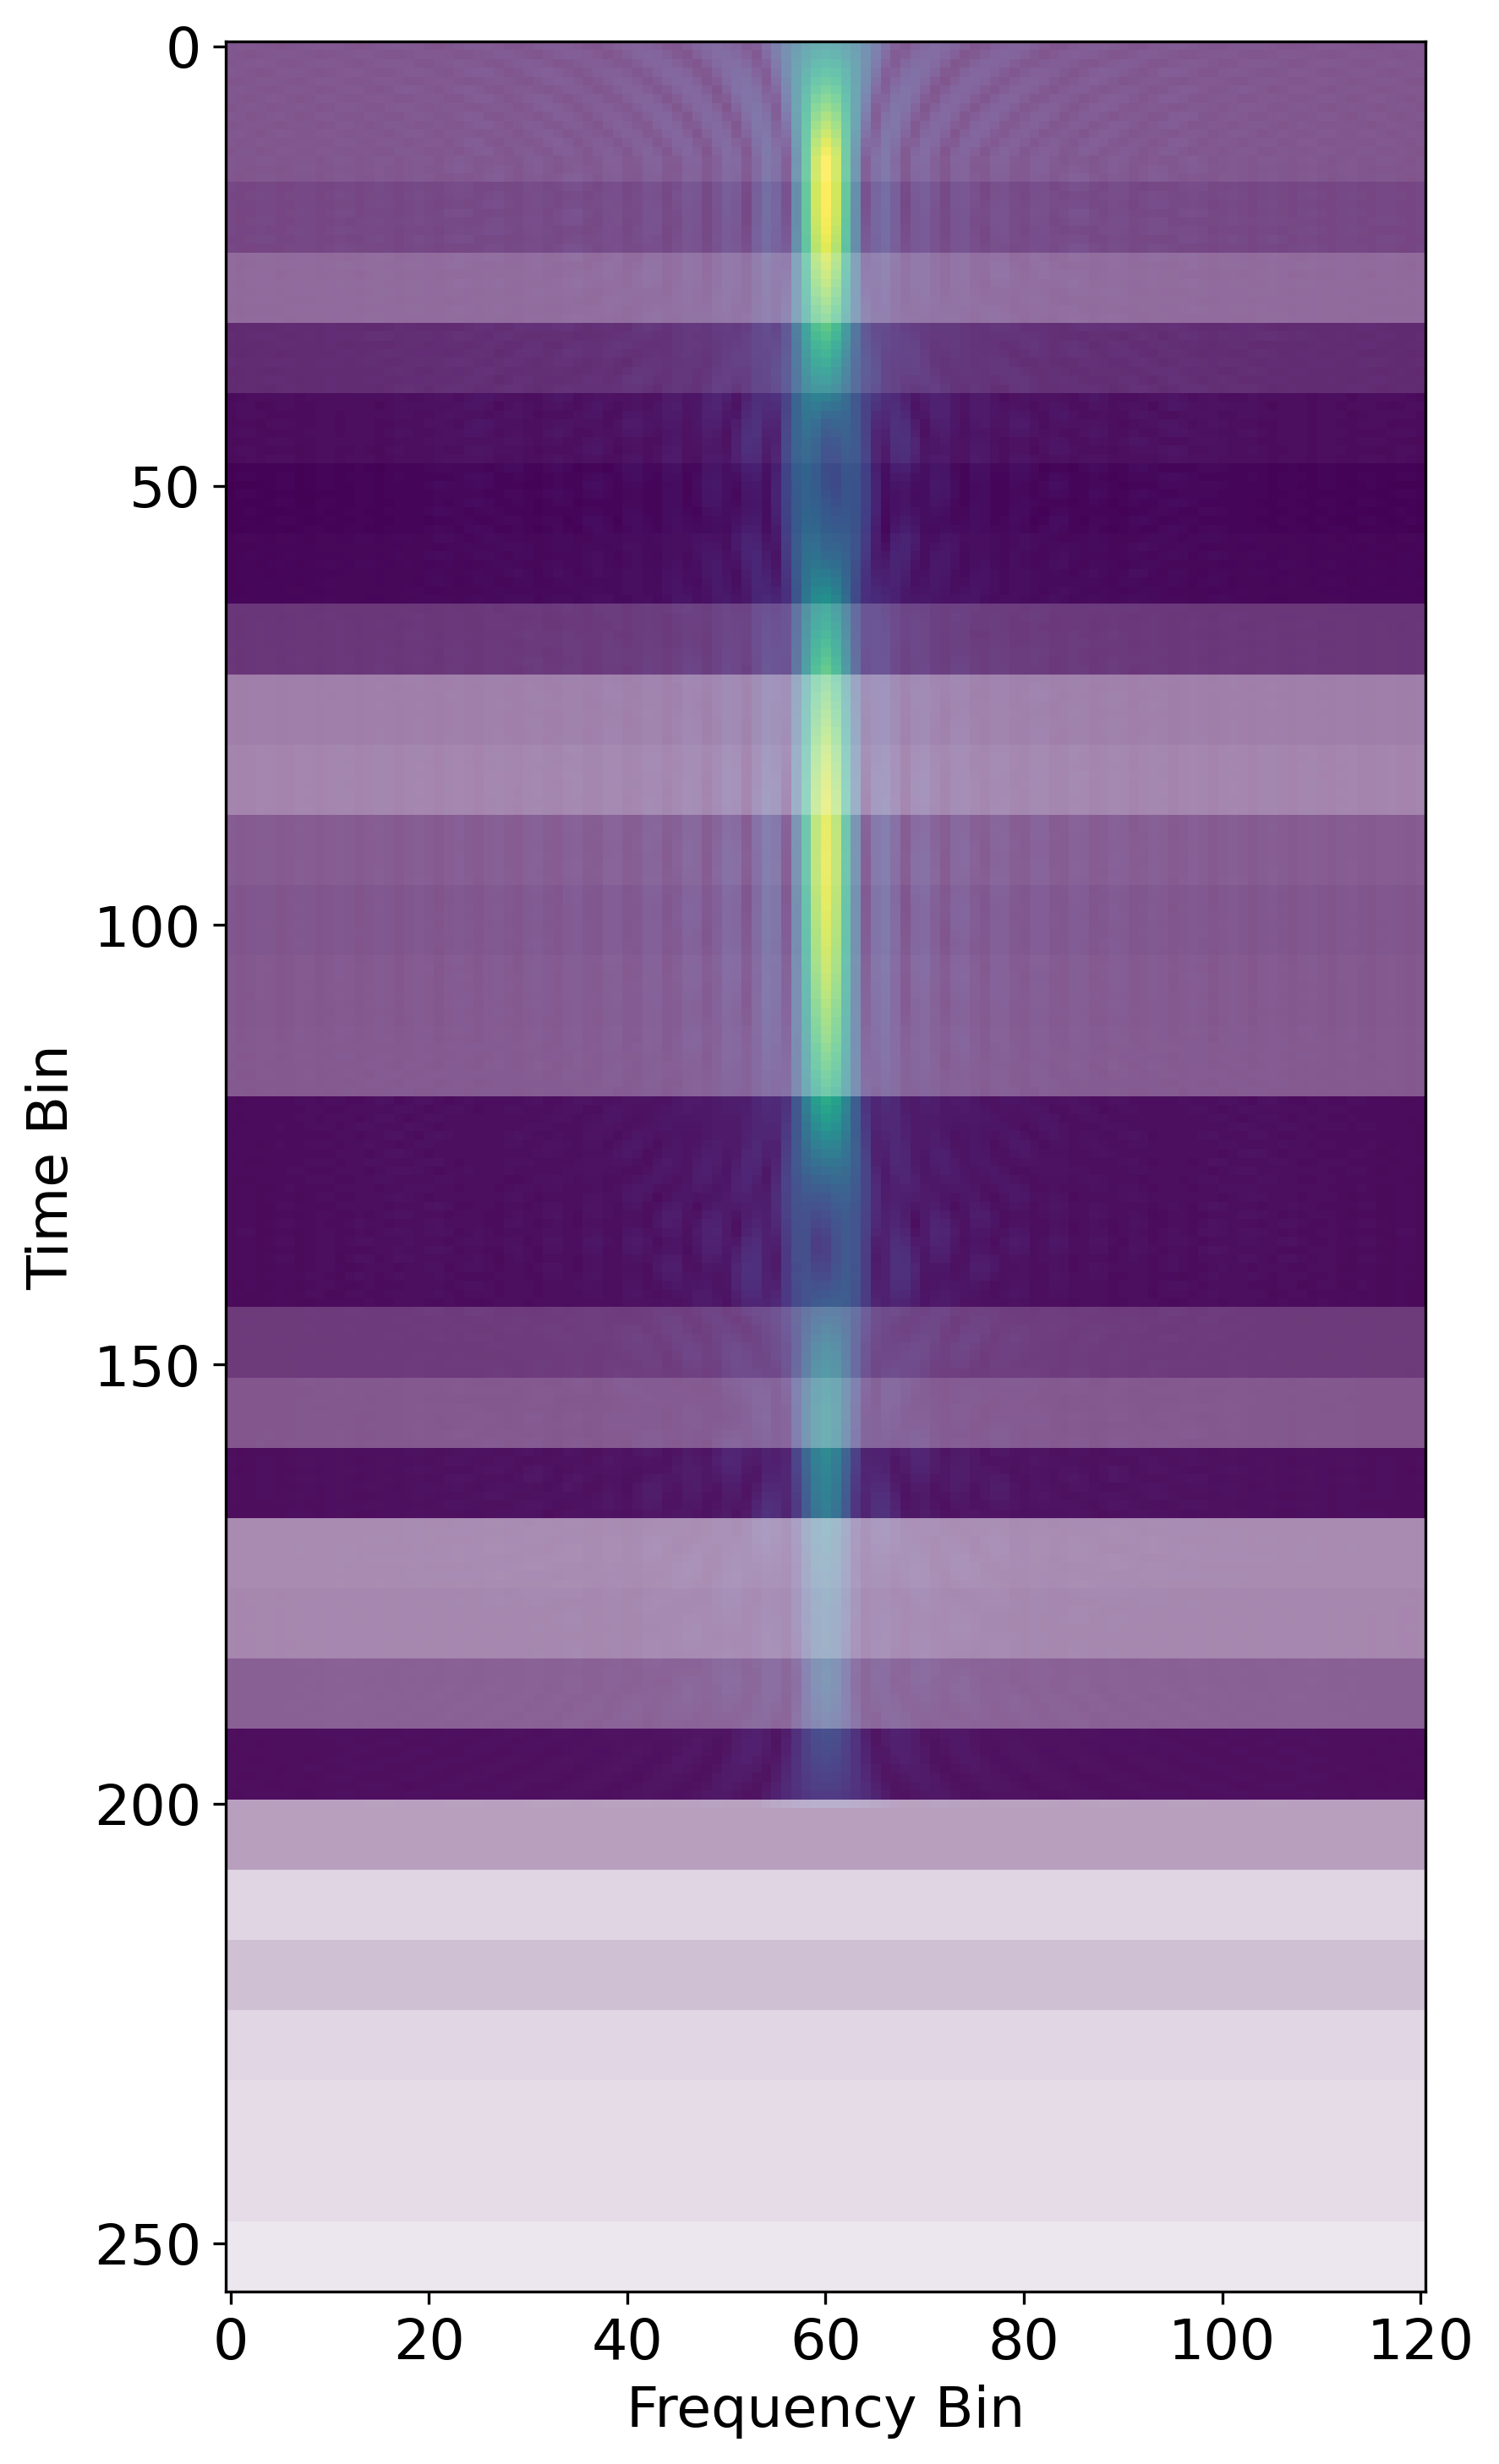

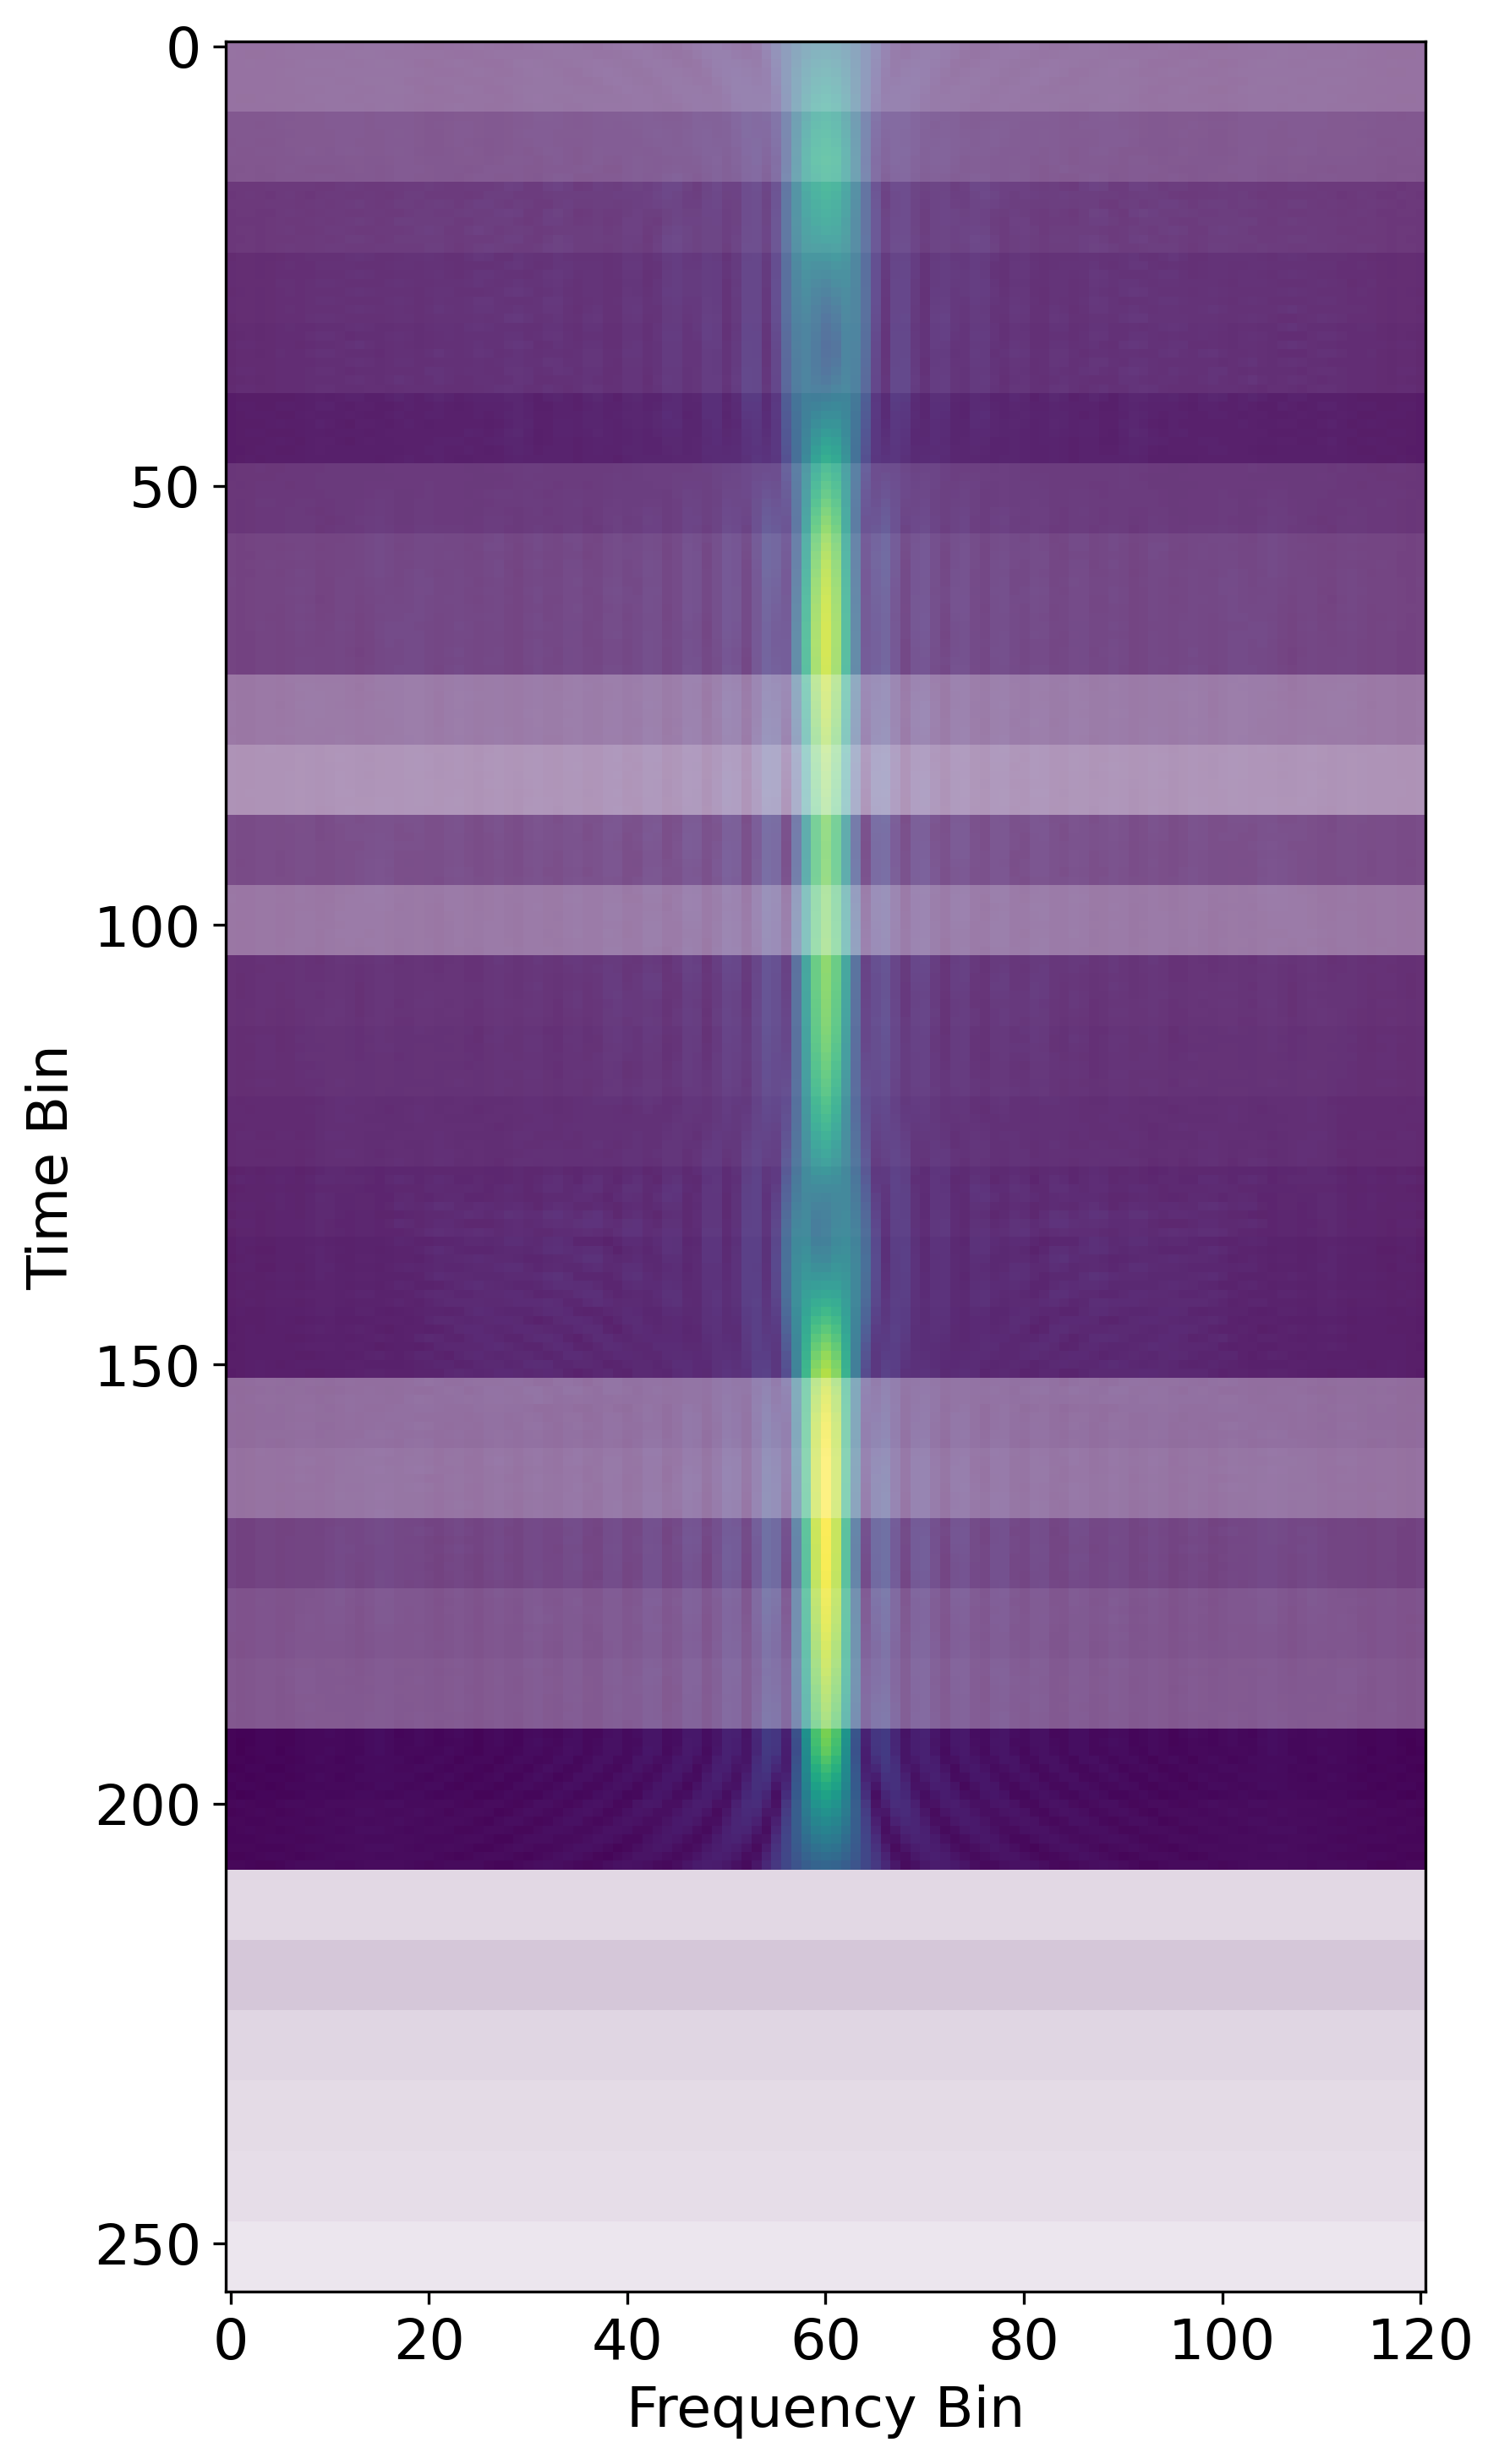

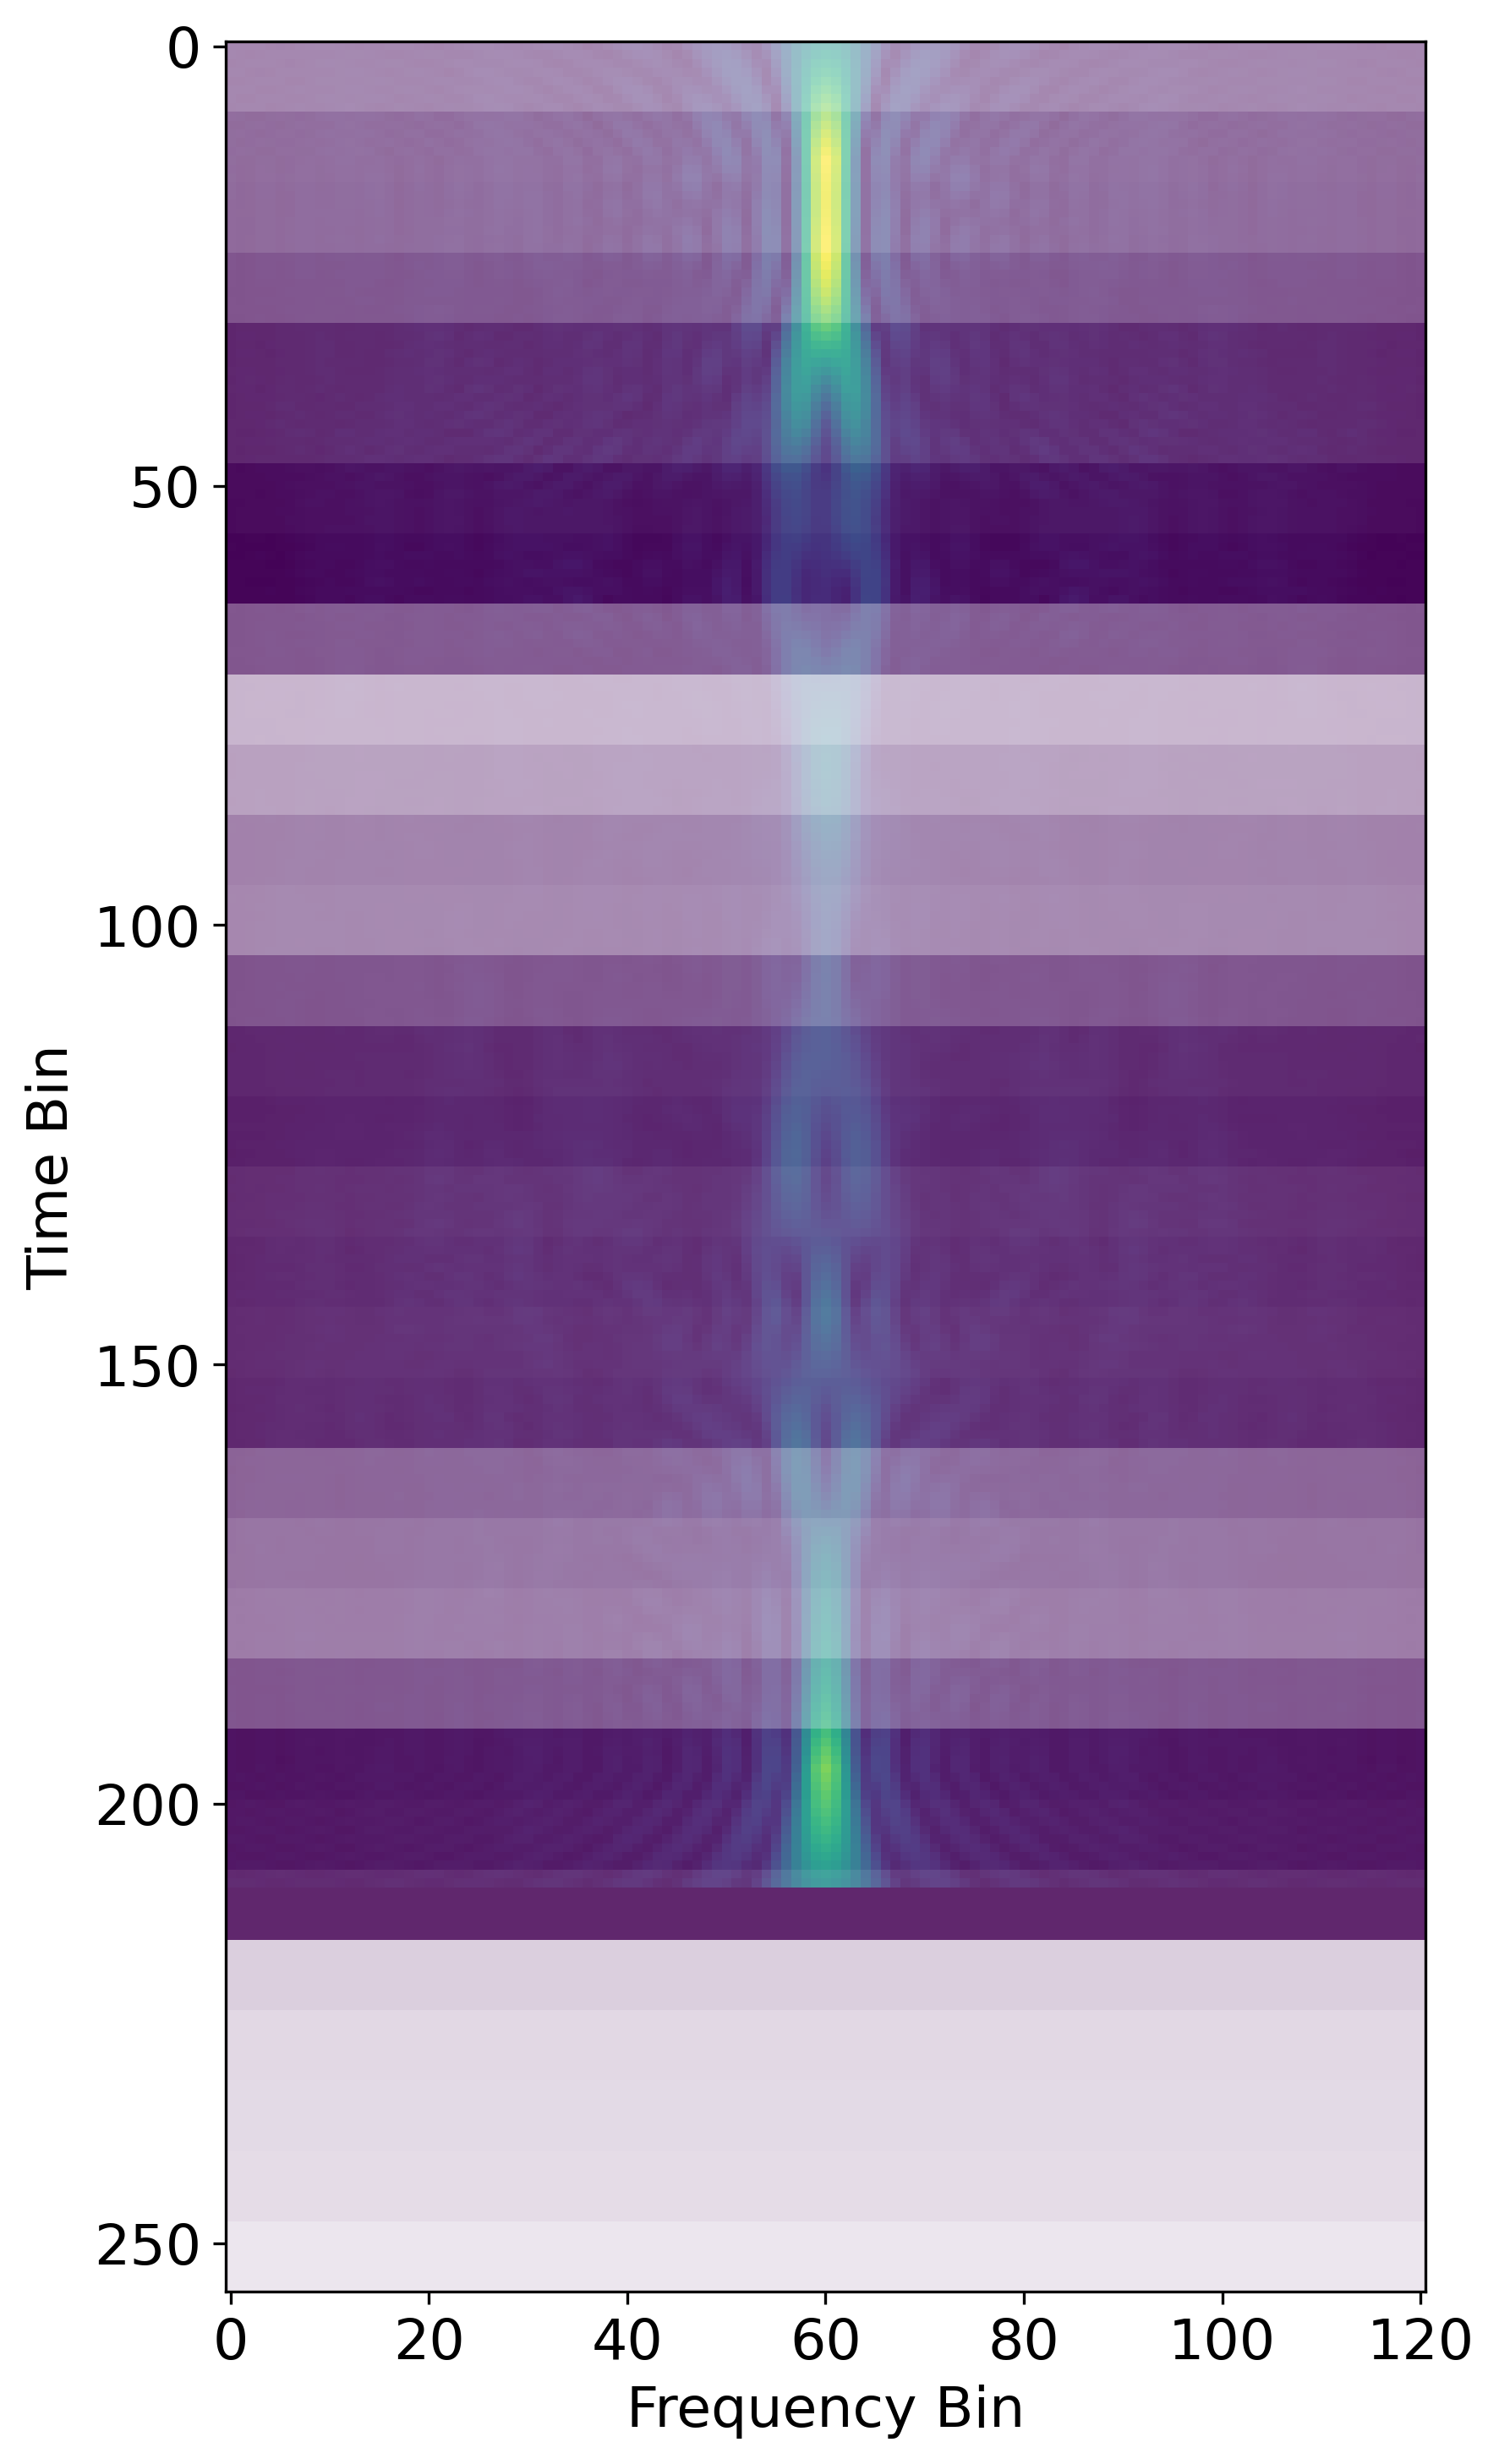

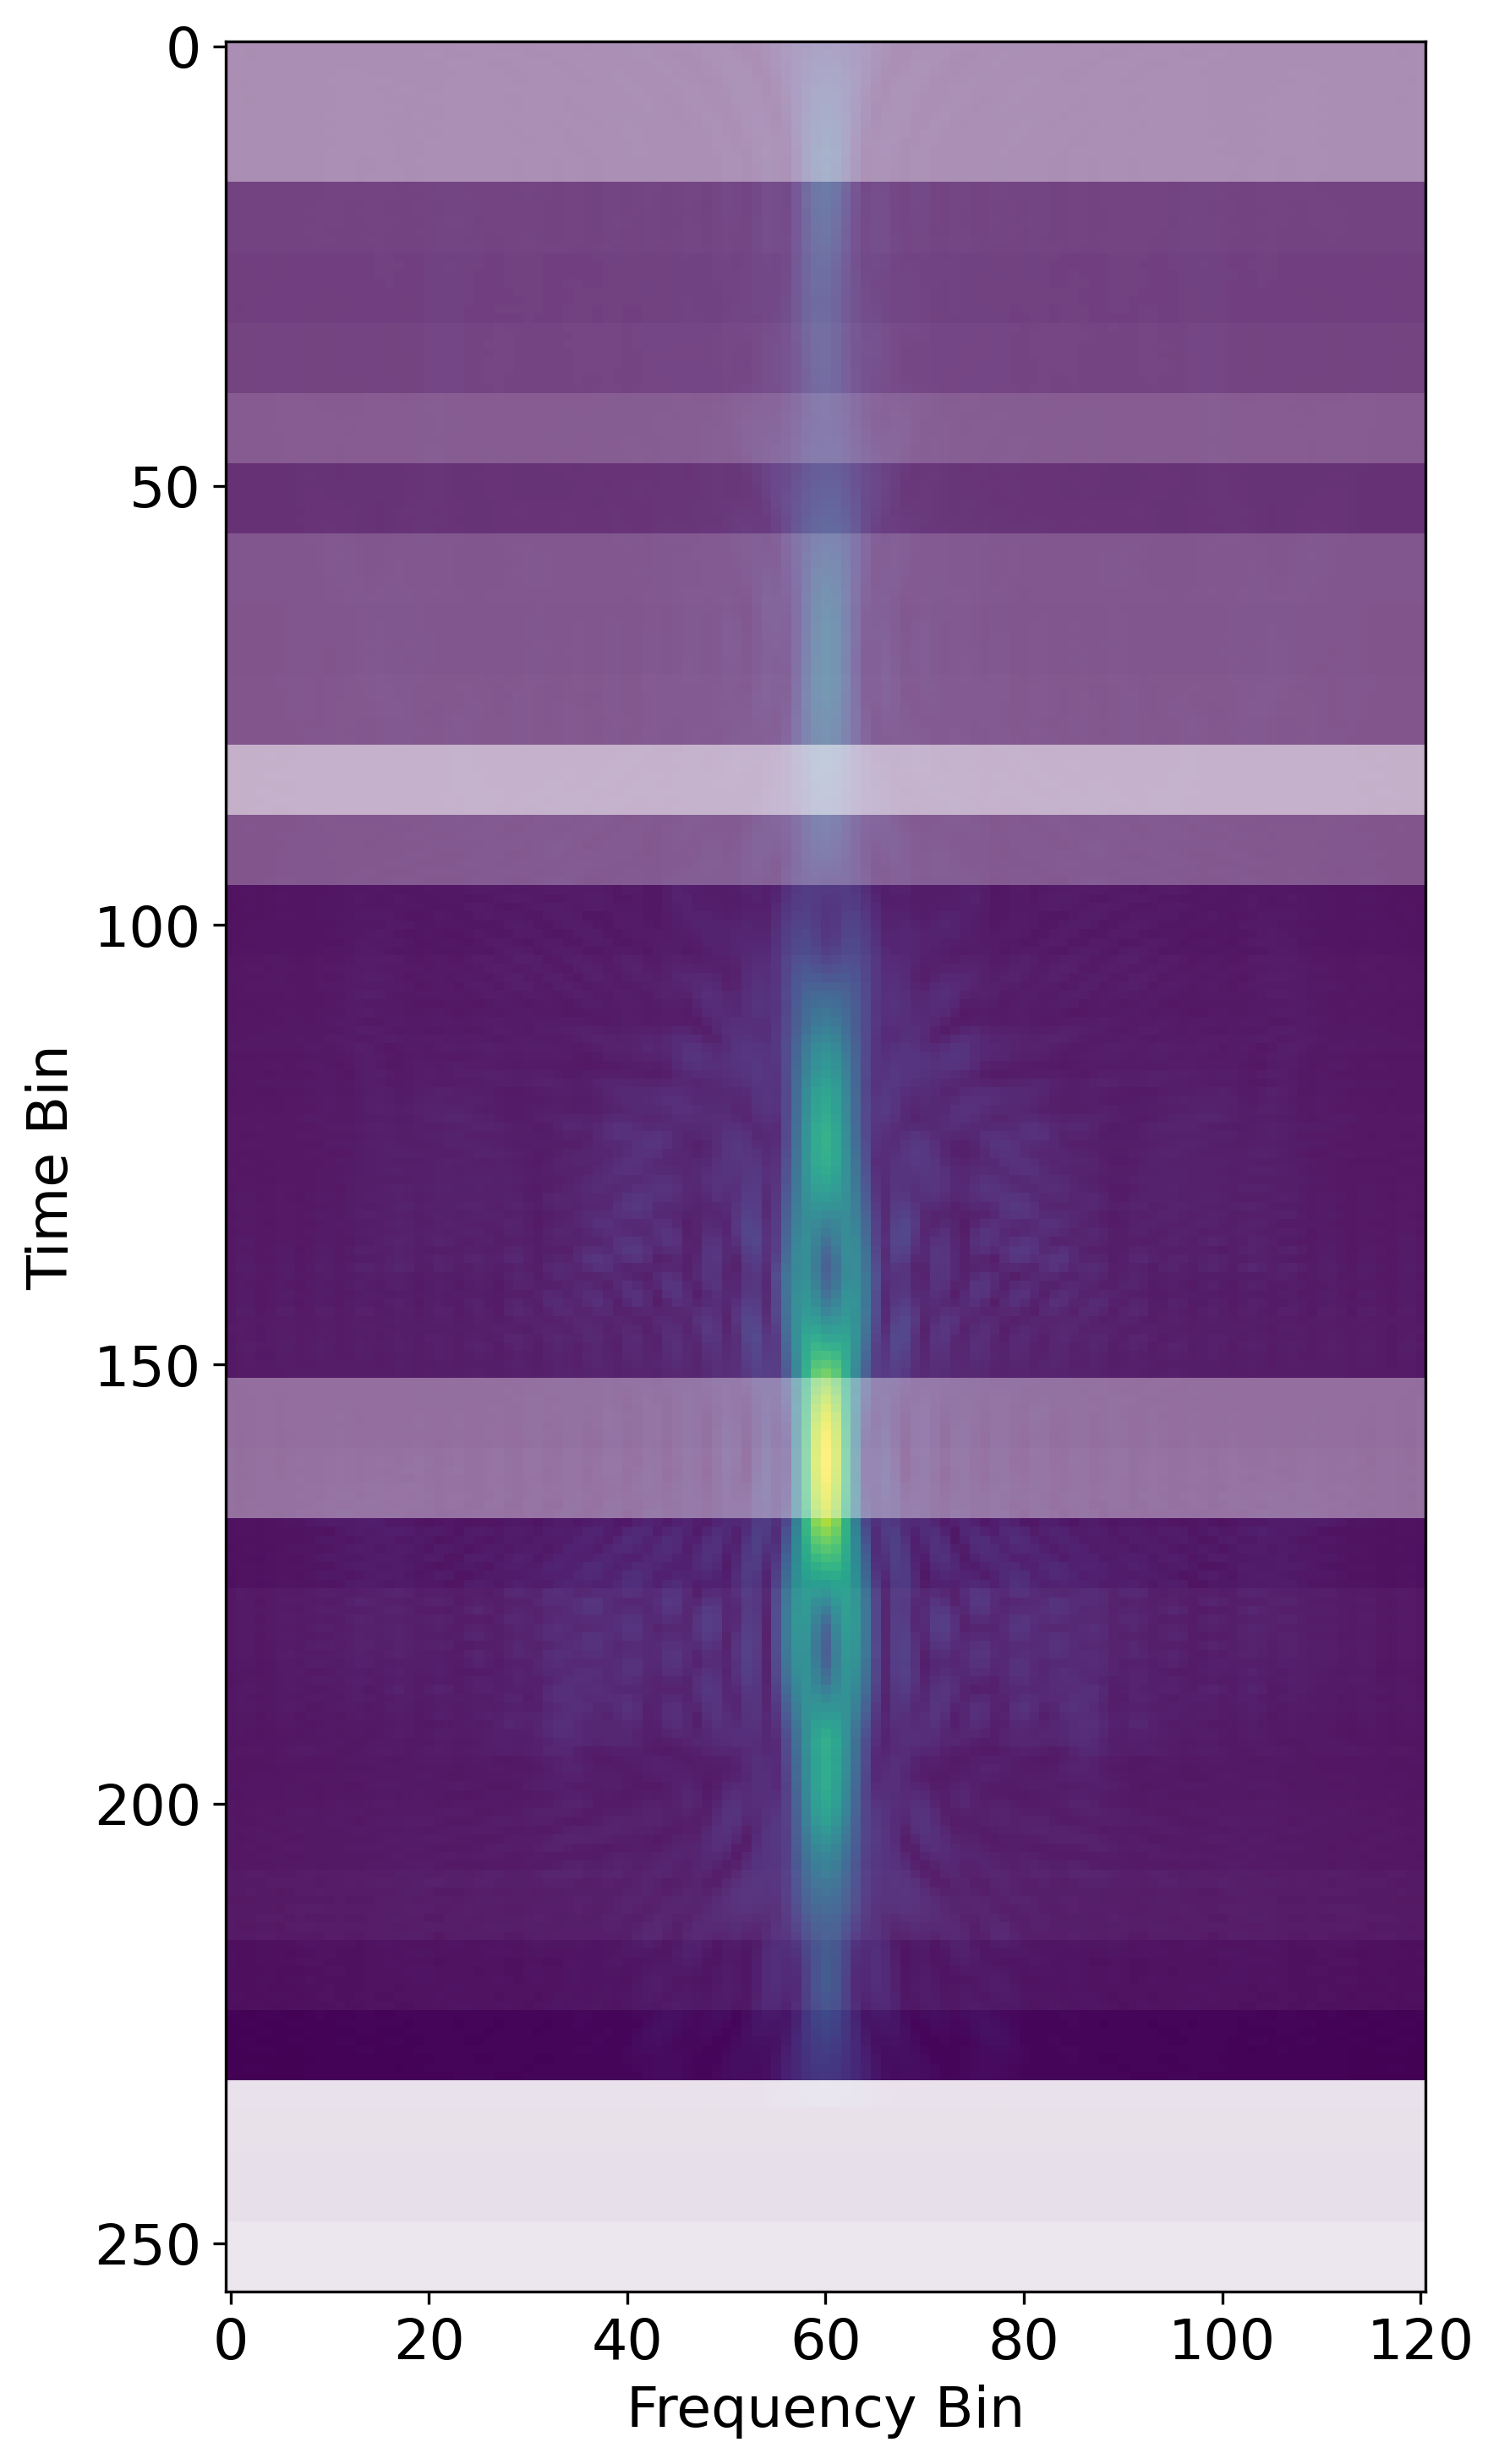

In [28]:
for count, i in enumerate(index_list_class_3):
    patch_map = attn_patch_score[i].reshape(grid_h, grid_w)
    input_map = inputs[i]
    cls_input_amp = np.mean(np.abs(input_map), axis=0)  # average over samples and links
    
    label = y[i]
    label_to_gesture_name[int(label)]

    
    H, W = cls_input_amp.shape
    h = patch_map.shape[0]
    input_heatmap = cls_input_amp
    attention_map = patch_map
    
    title = label_to_gesture_name[int(label)] + " " + str(i)

    # 2. Rescale attention map to match input shape (H, W)
    scale_factor = H // h
    attn_expanded = np.repeat(attention_map, scale_factor, axis=0)
    # If H is not perfectly divisible by h, pad or crop to match exactly H
    if attn_expanded.shape[0] < H:
        padding = np.zeros((H - attn_expanded.shape[0], 1))
        attn_expanded = np.vstack([attn_expanded, padding])
    attn_full = np.tile(attn_expanded, (1, W))

    # 3. Apply Proper Normalization
    # Normalize the heatmap values to [0, 1] for the colormap
    norm = plt.Normalize(vmin=input_heatmap.min(), vmax=input_heatmap.max())
    cmap = plt.get_cmap('viridis')
    heatmap_rgb = cmap(norm(input_heatmap)) # This returns a (H, W, 4) array

    # 4. Apply Attention to Alpha Channel
    # Normalize attention to [0.1, 1.0] so background is still faintly visible
    attn_min, attn_max = attn_full.min(), attn_full.max()
    attn_alpha = 0.1 + (attn_full - attn_min) * (0.9 / (attn_max - attn_min))

    # Set the 4th channel (Alpha) to our attention values
    heatmap_rgb[:, :, 3] = attn_alpha 

    # 5. Visualization
    # set the fontsize 
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(figsize=(6, 10), dpi=300)
    ax.imshow(heatmap_rgb, aspect='auto')
    # ax.set_title(title, fontsize=12)
    ax.set_xlabel("Frequency Bin")
    ax.set_ylabel("Time Bin")

    plt.tight_layout()
    plt.show()
    # if count > 10:
    #     break


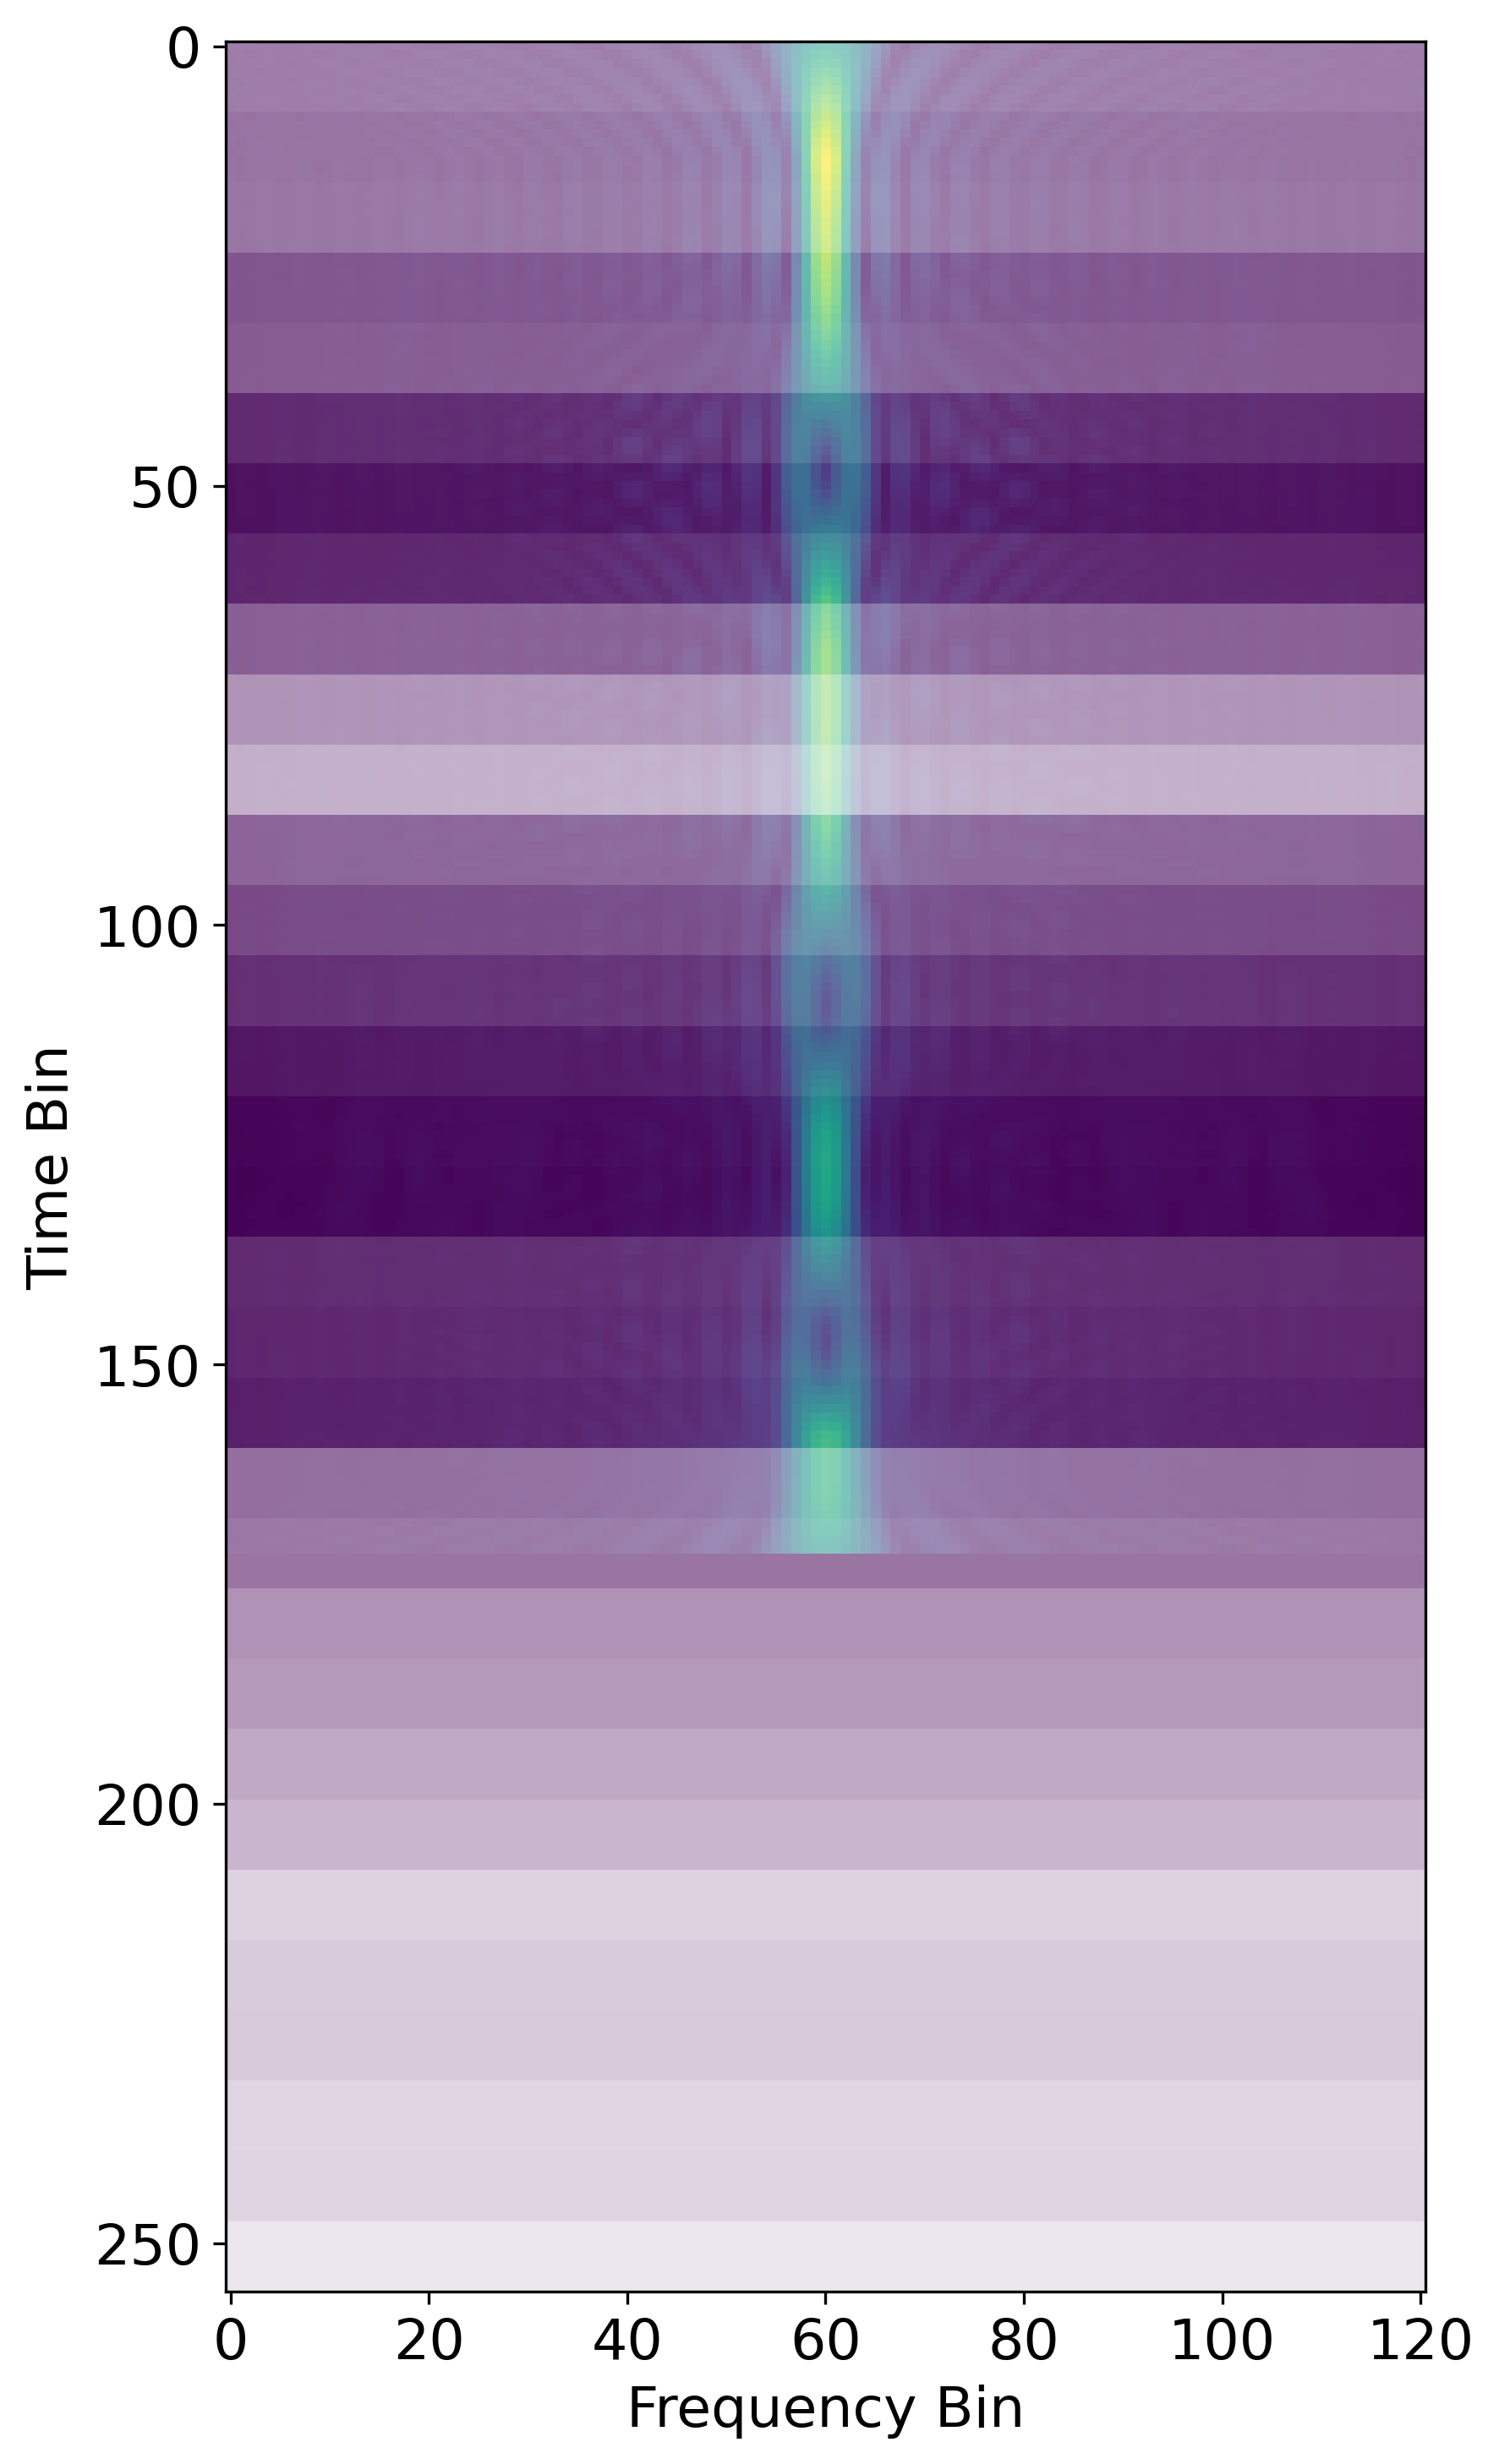

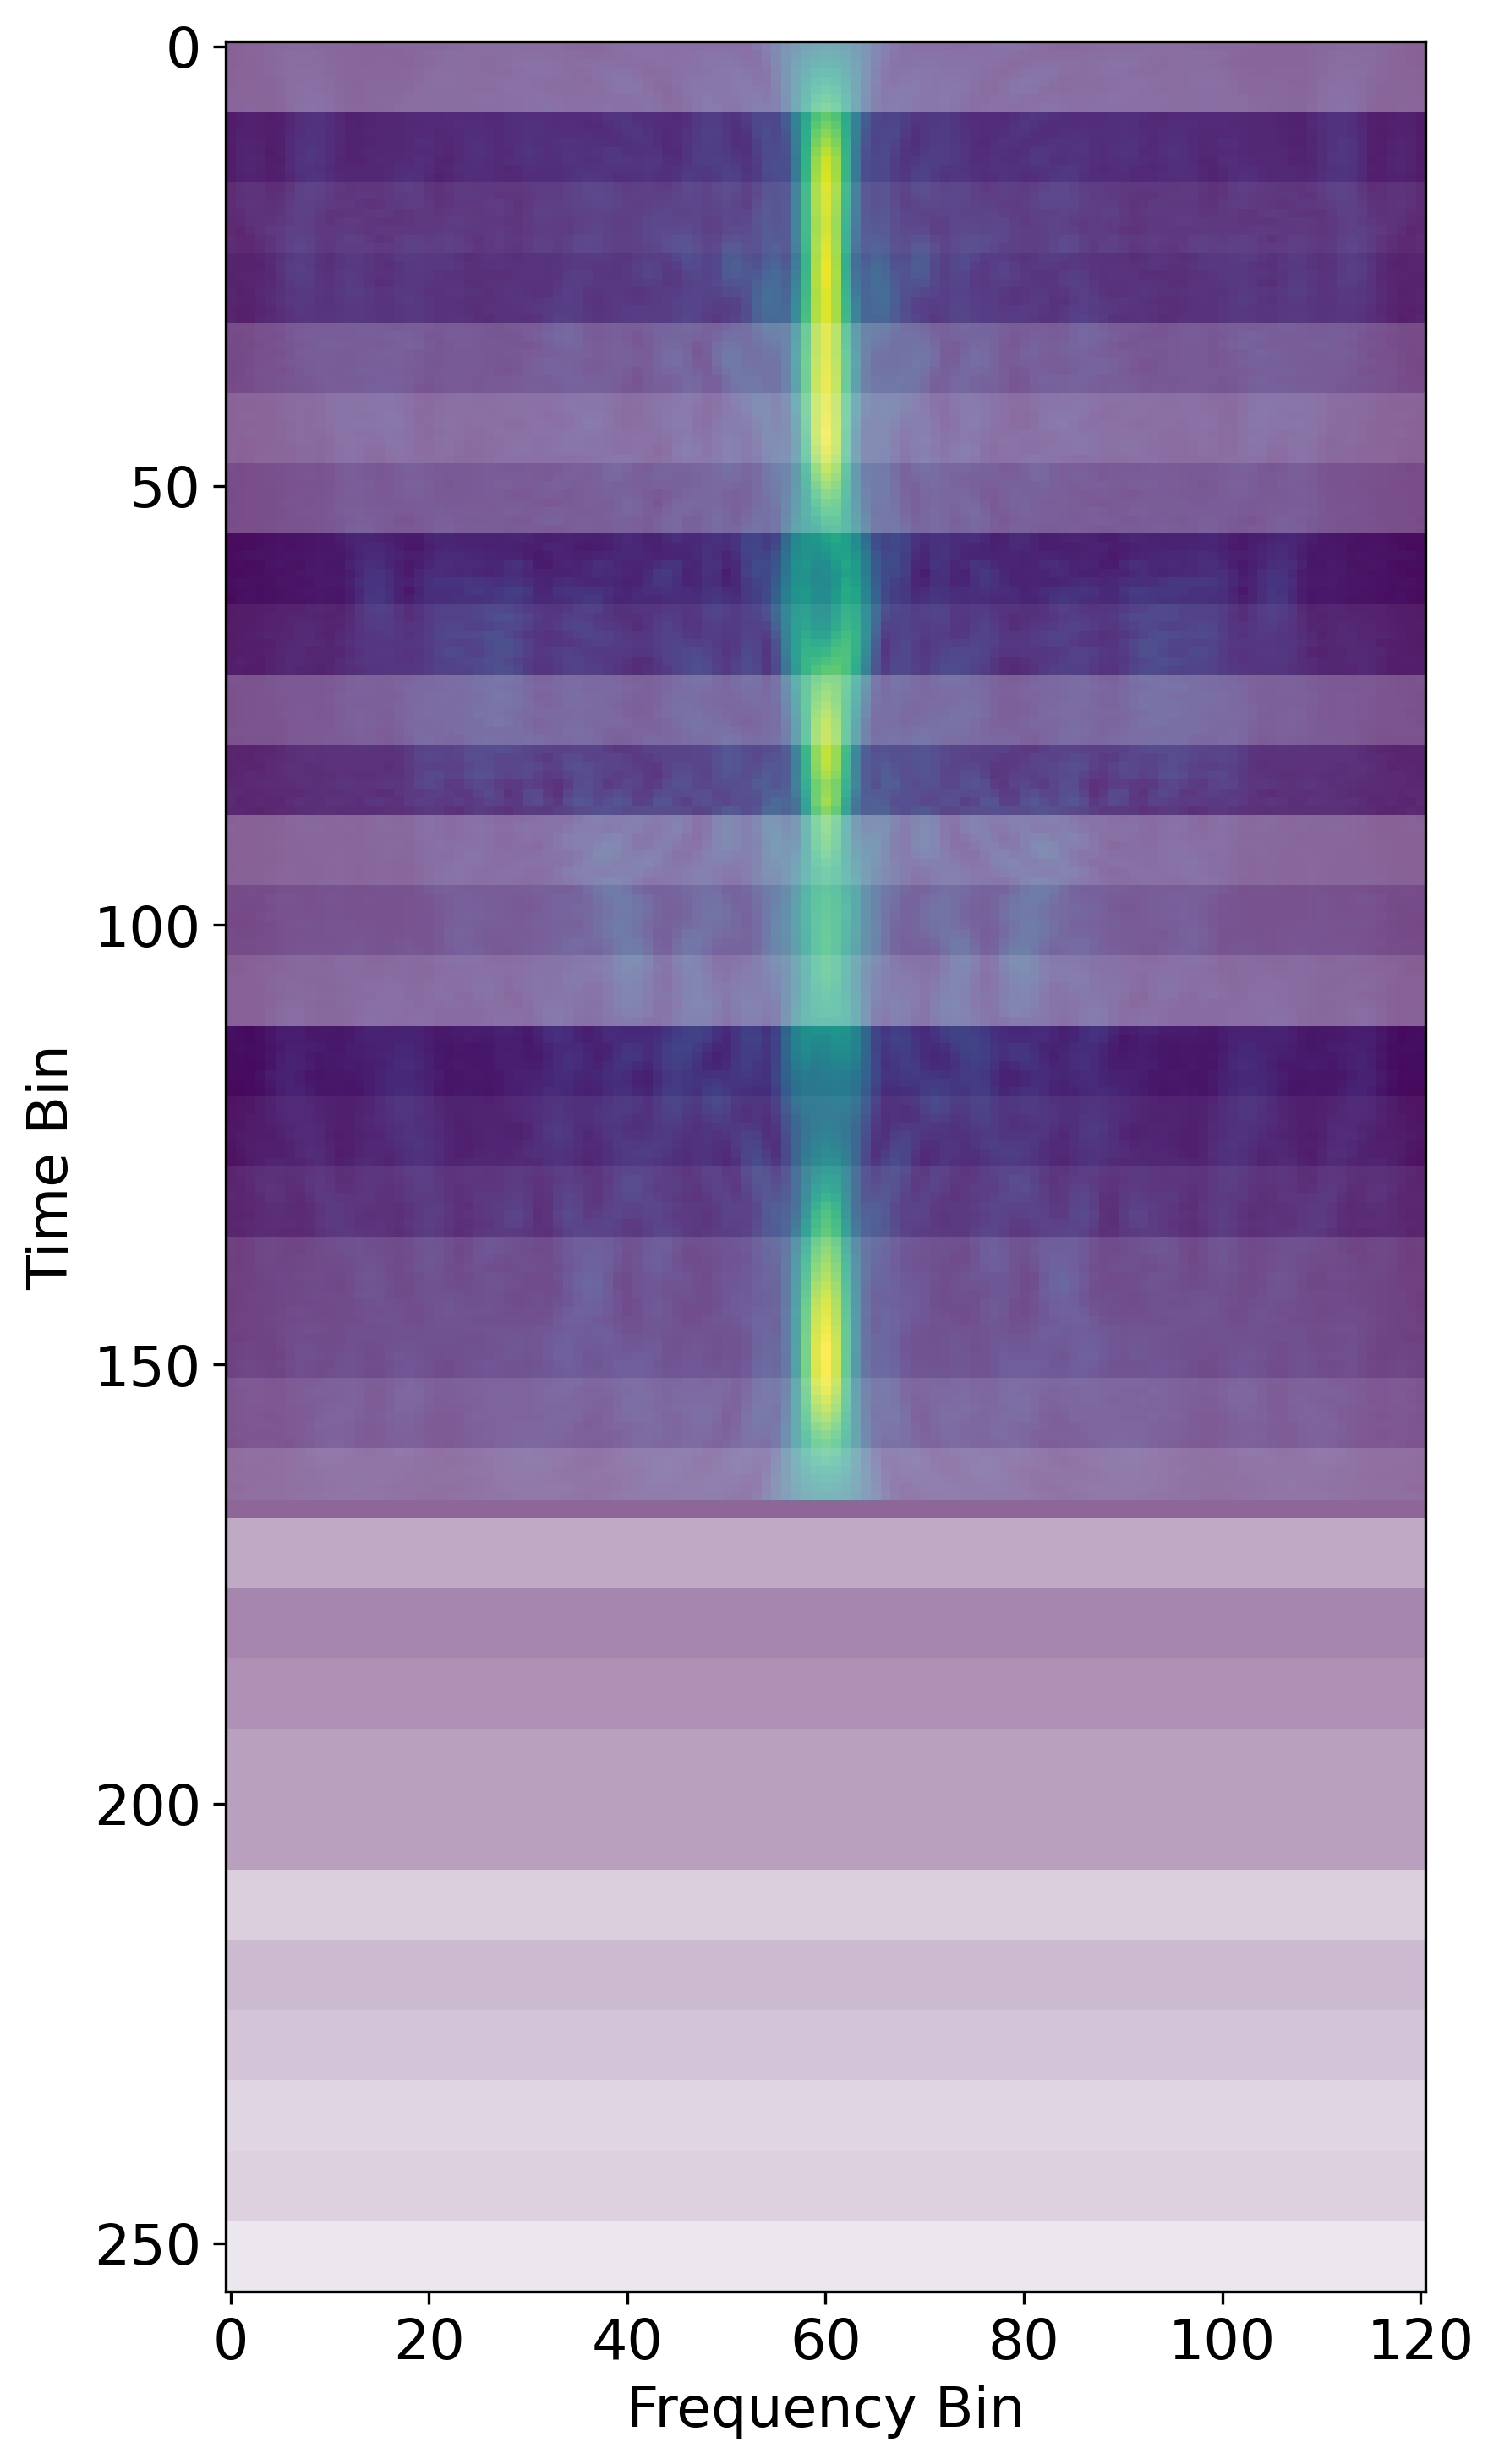

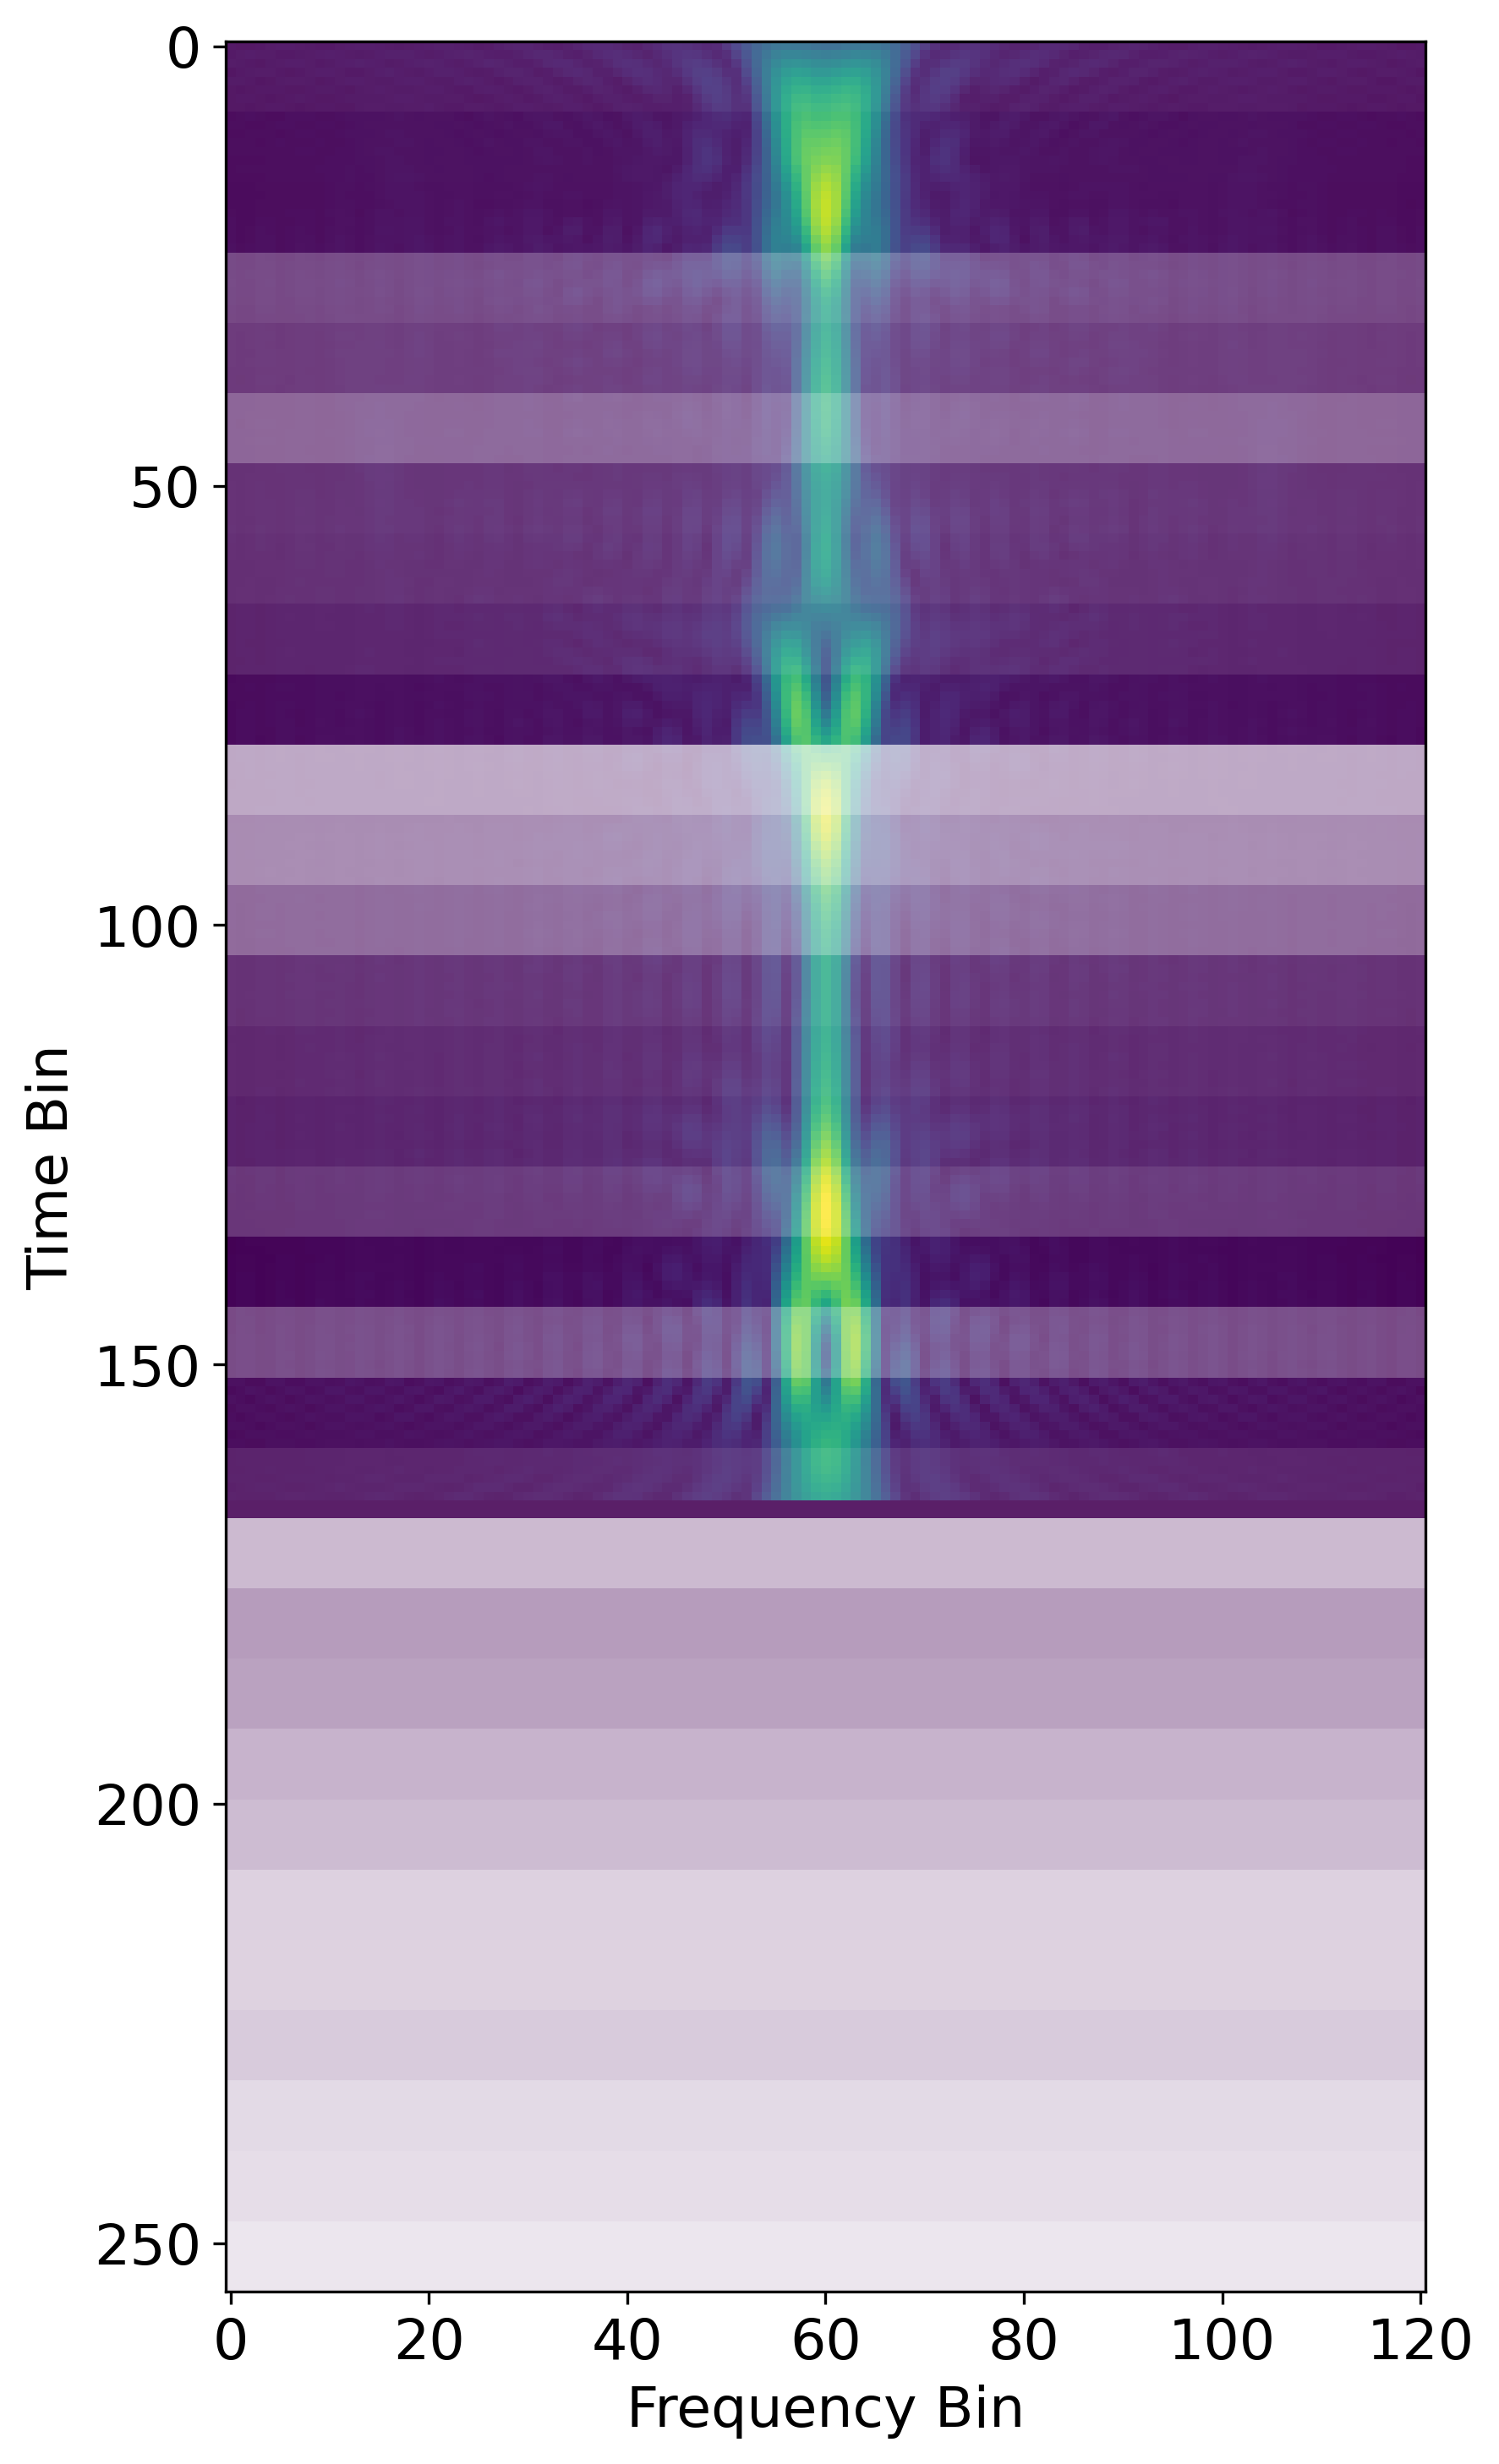

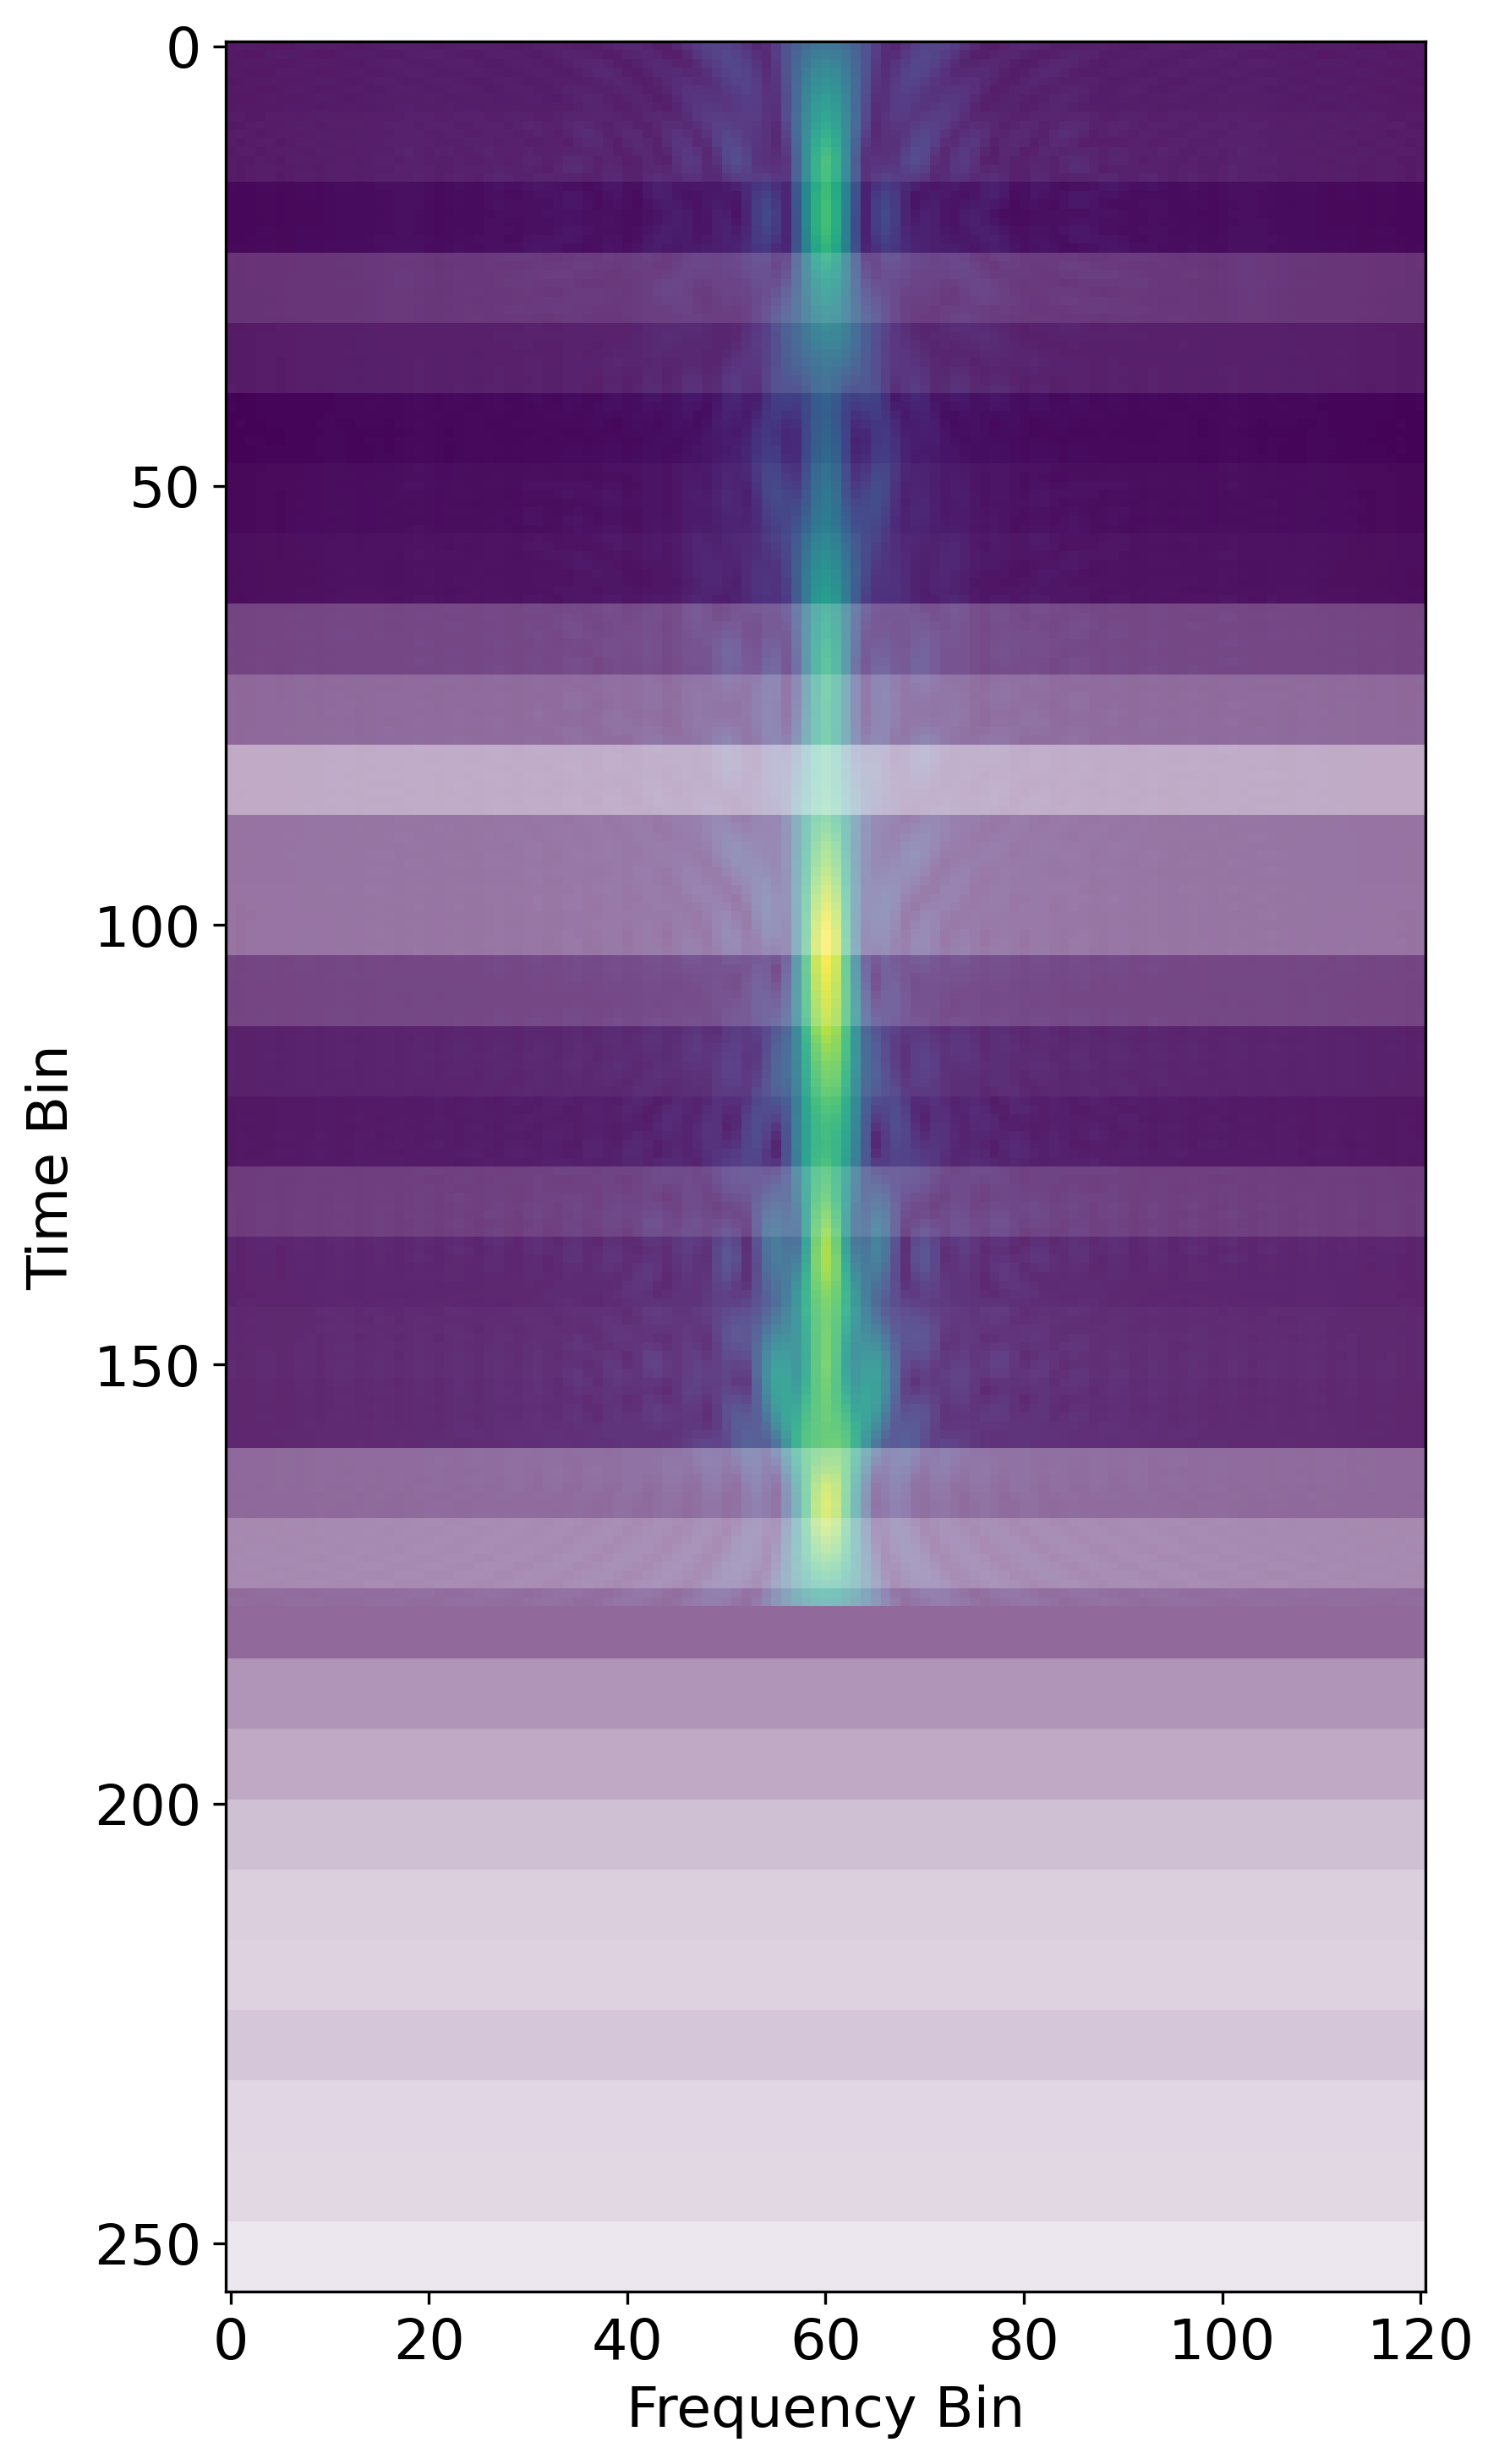

In [29]:
for count, i in enumerate(index_list_class_4):
    patch_map = attn_patch_score[i].reshape(grid_h, grid_w)
    input_map = inputs[i]
    cls_input_amp = np.mean(np.abs(input_map), axis=0)  # average over samples and links
    
    label = y[i]
    label_to_gesture_name[int(label)]

    
    H, W = cls_input_amp.shape
    h = patch_map.shape[0]
    input_heatmap = cls_input_amp
    attention_map = patch_map
    
    title = label_to_gesture_name[int(label)] + " " + str(i)

    # 2. Rescale attention map to match input shape (H, W)
    scale_factor = H // h
    attn_expanded = np.repeat(attention_map, scale_factor, axis=0)
    # If H is not perfectly divisible by h, pad or crop to match exactly H
    if attn_expanded.shape[0] < H:
        padding = np.zeros((H - attn_expanded.shape[0], 1))
        attn_expanded = np.vstack([attn_expanded, padding])
    attn_full = np.tile(attn_expanded, (1, W))

    # 3. Apply Proper Normalization
    # Normalize the heatmap values to [0, 1] for the colormap
    norm = plt.Normalize(vmin=input_heatmap.min(), vmax=input_heatmap.max())
    cmap = plt.get_cmap('viridis')
    heatmap_rgb = cmap(norm(input_heatmap)) # This returns a (H, W, 4) array

    # 4. Apply Attention to Alpha Channel
    # Normalize attention to [0.1, 1.0] so background is still faintly visible
    attn_min, attn_max = attn_full.min(), attn_full.max()
    attn_alpha = 0.1 + (attn_full - attn_min) * (0.9 / (attn_max - attn_min))

    # Set the 4th channel (Alpha) to our attention values
    heatmap_rgb[:, :, 3] = attn_alpha 

    # 5. Visualization
    # set the fontsize 
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(figsize=(6, 10), dpi=300)
    ax.imshow(heatmap_rgb, aspect='auto')
    # ax.set_title(title, fontsize=12)
    ax.set_xlabel("Frequency Bin")
    ax.set_ylabel("Time Bin")

    plt.tight_layout()
    plt.show()
    # if count > 10:
    #     break


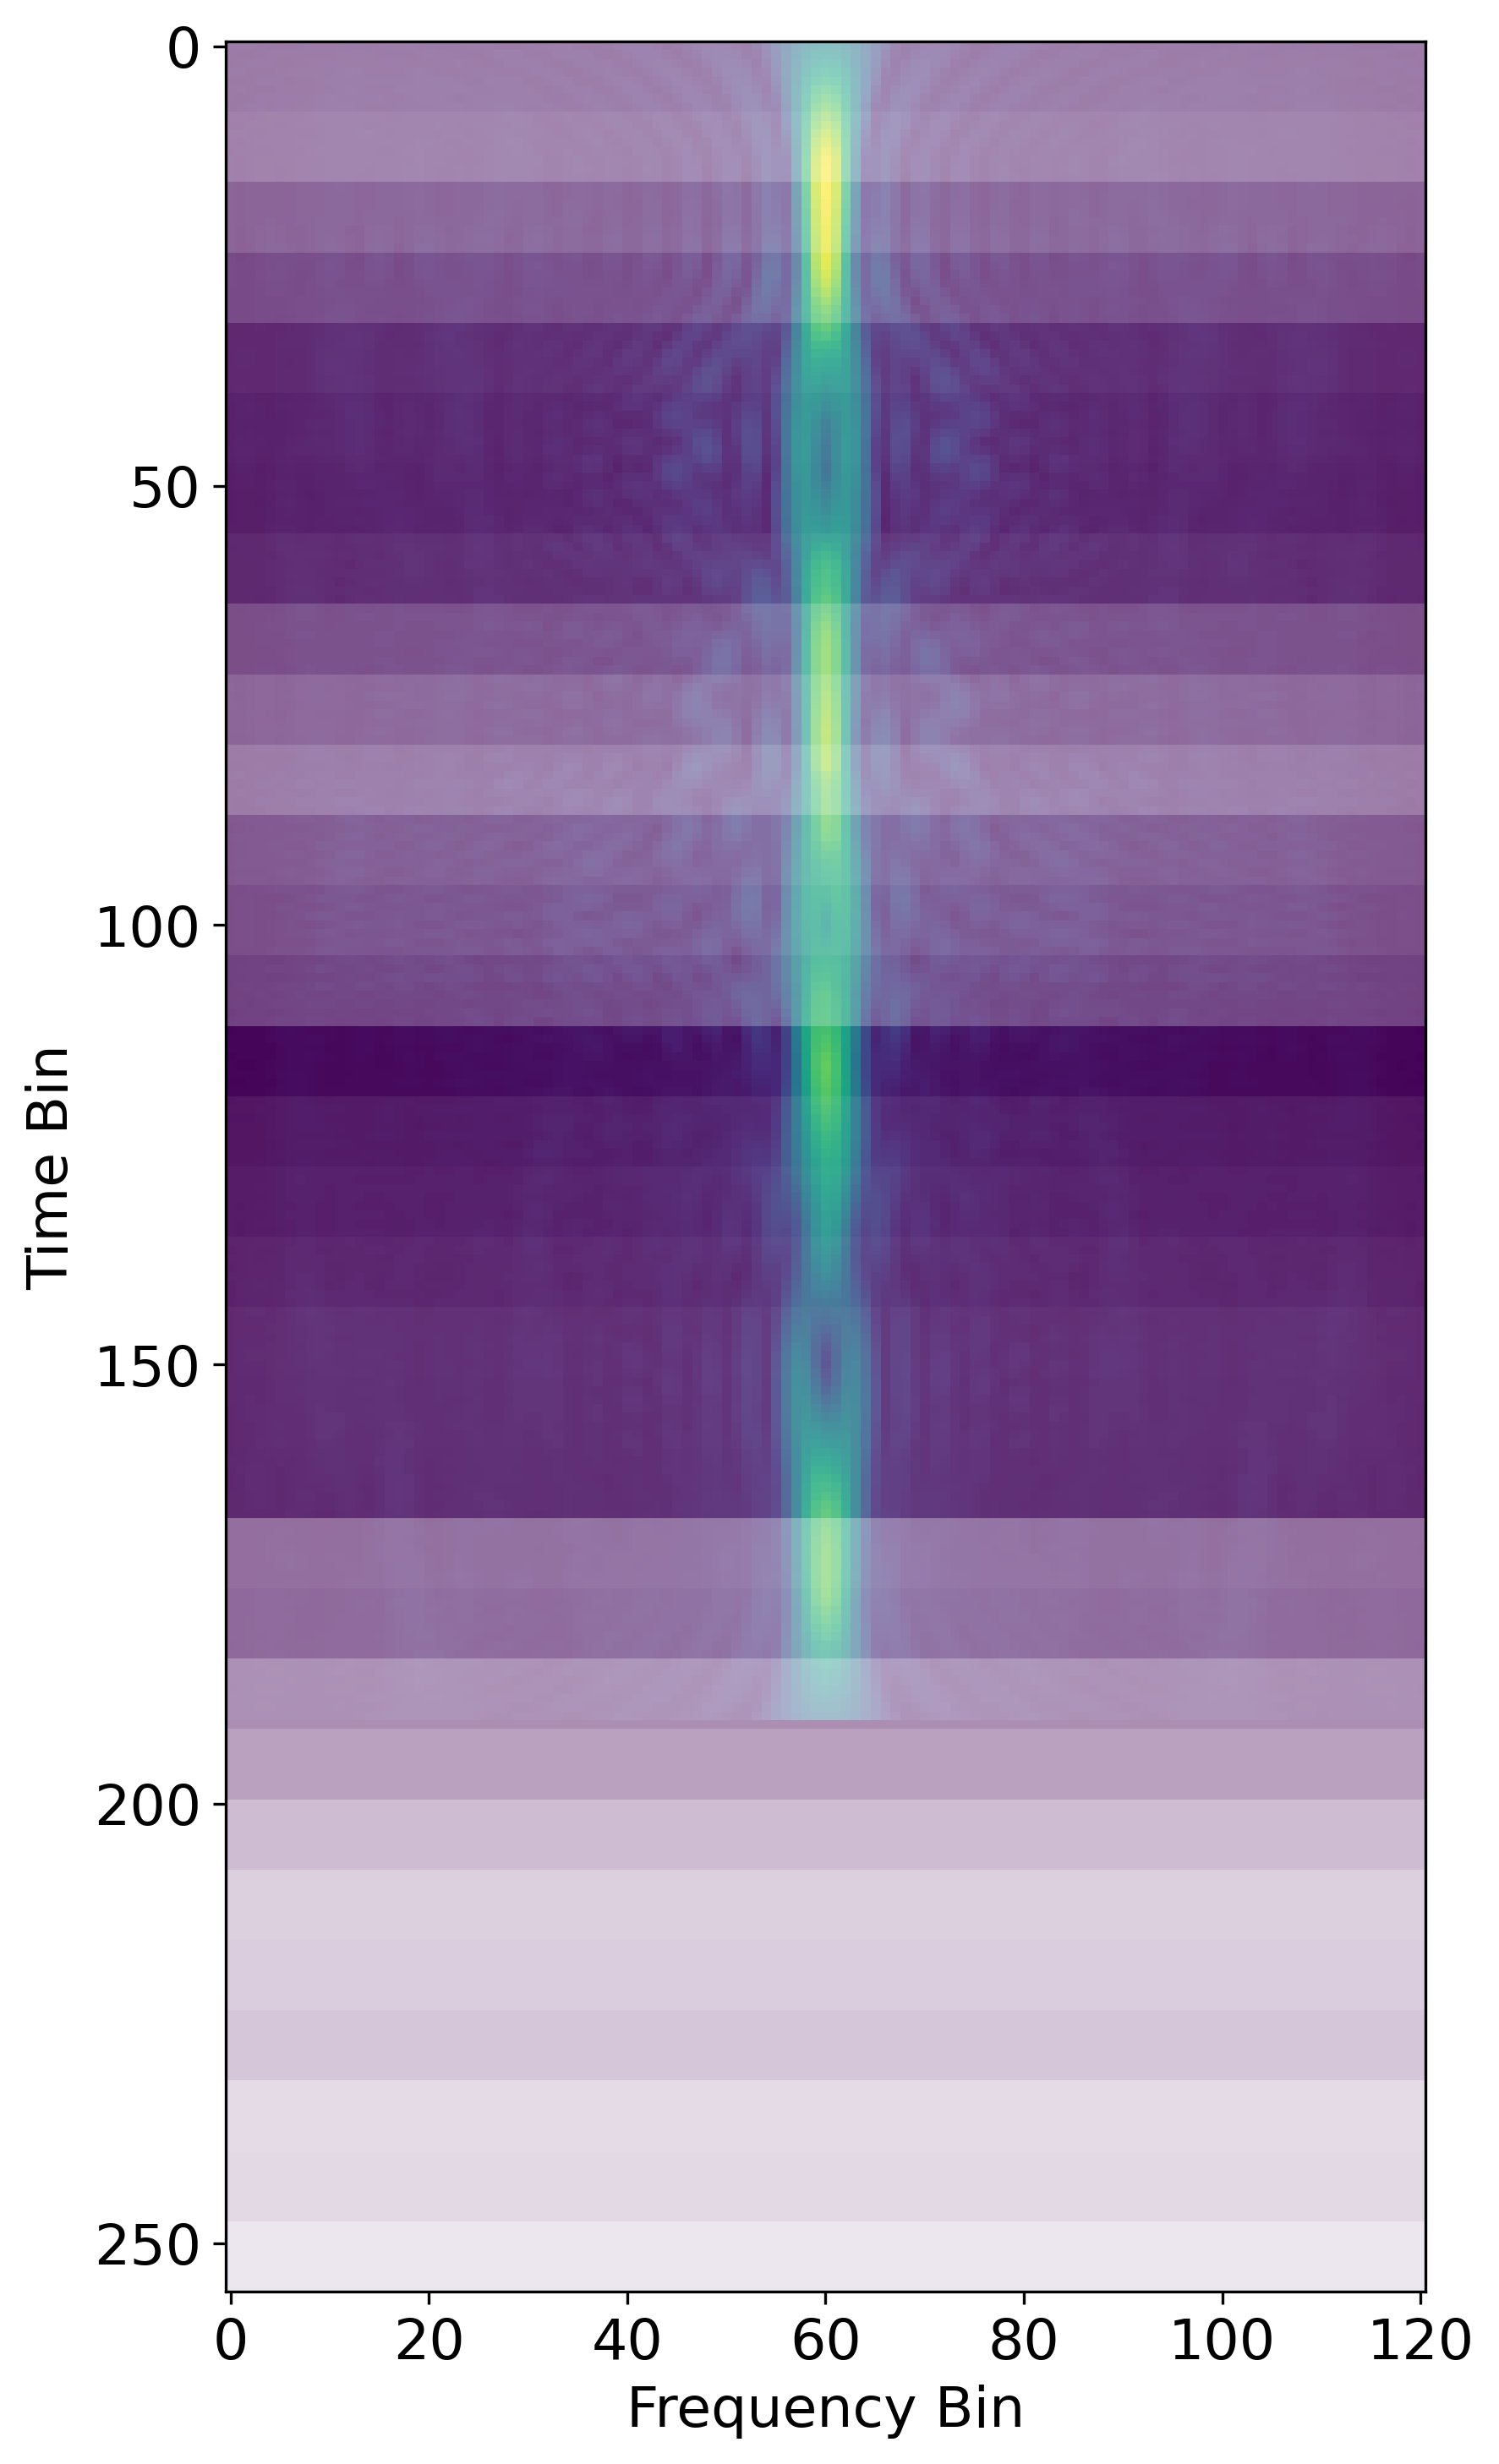

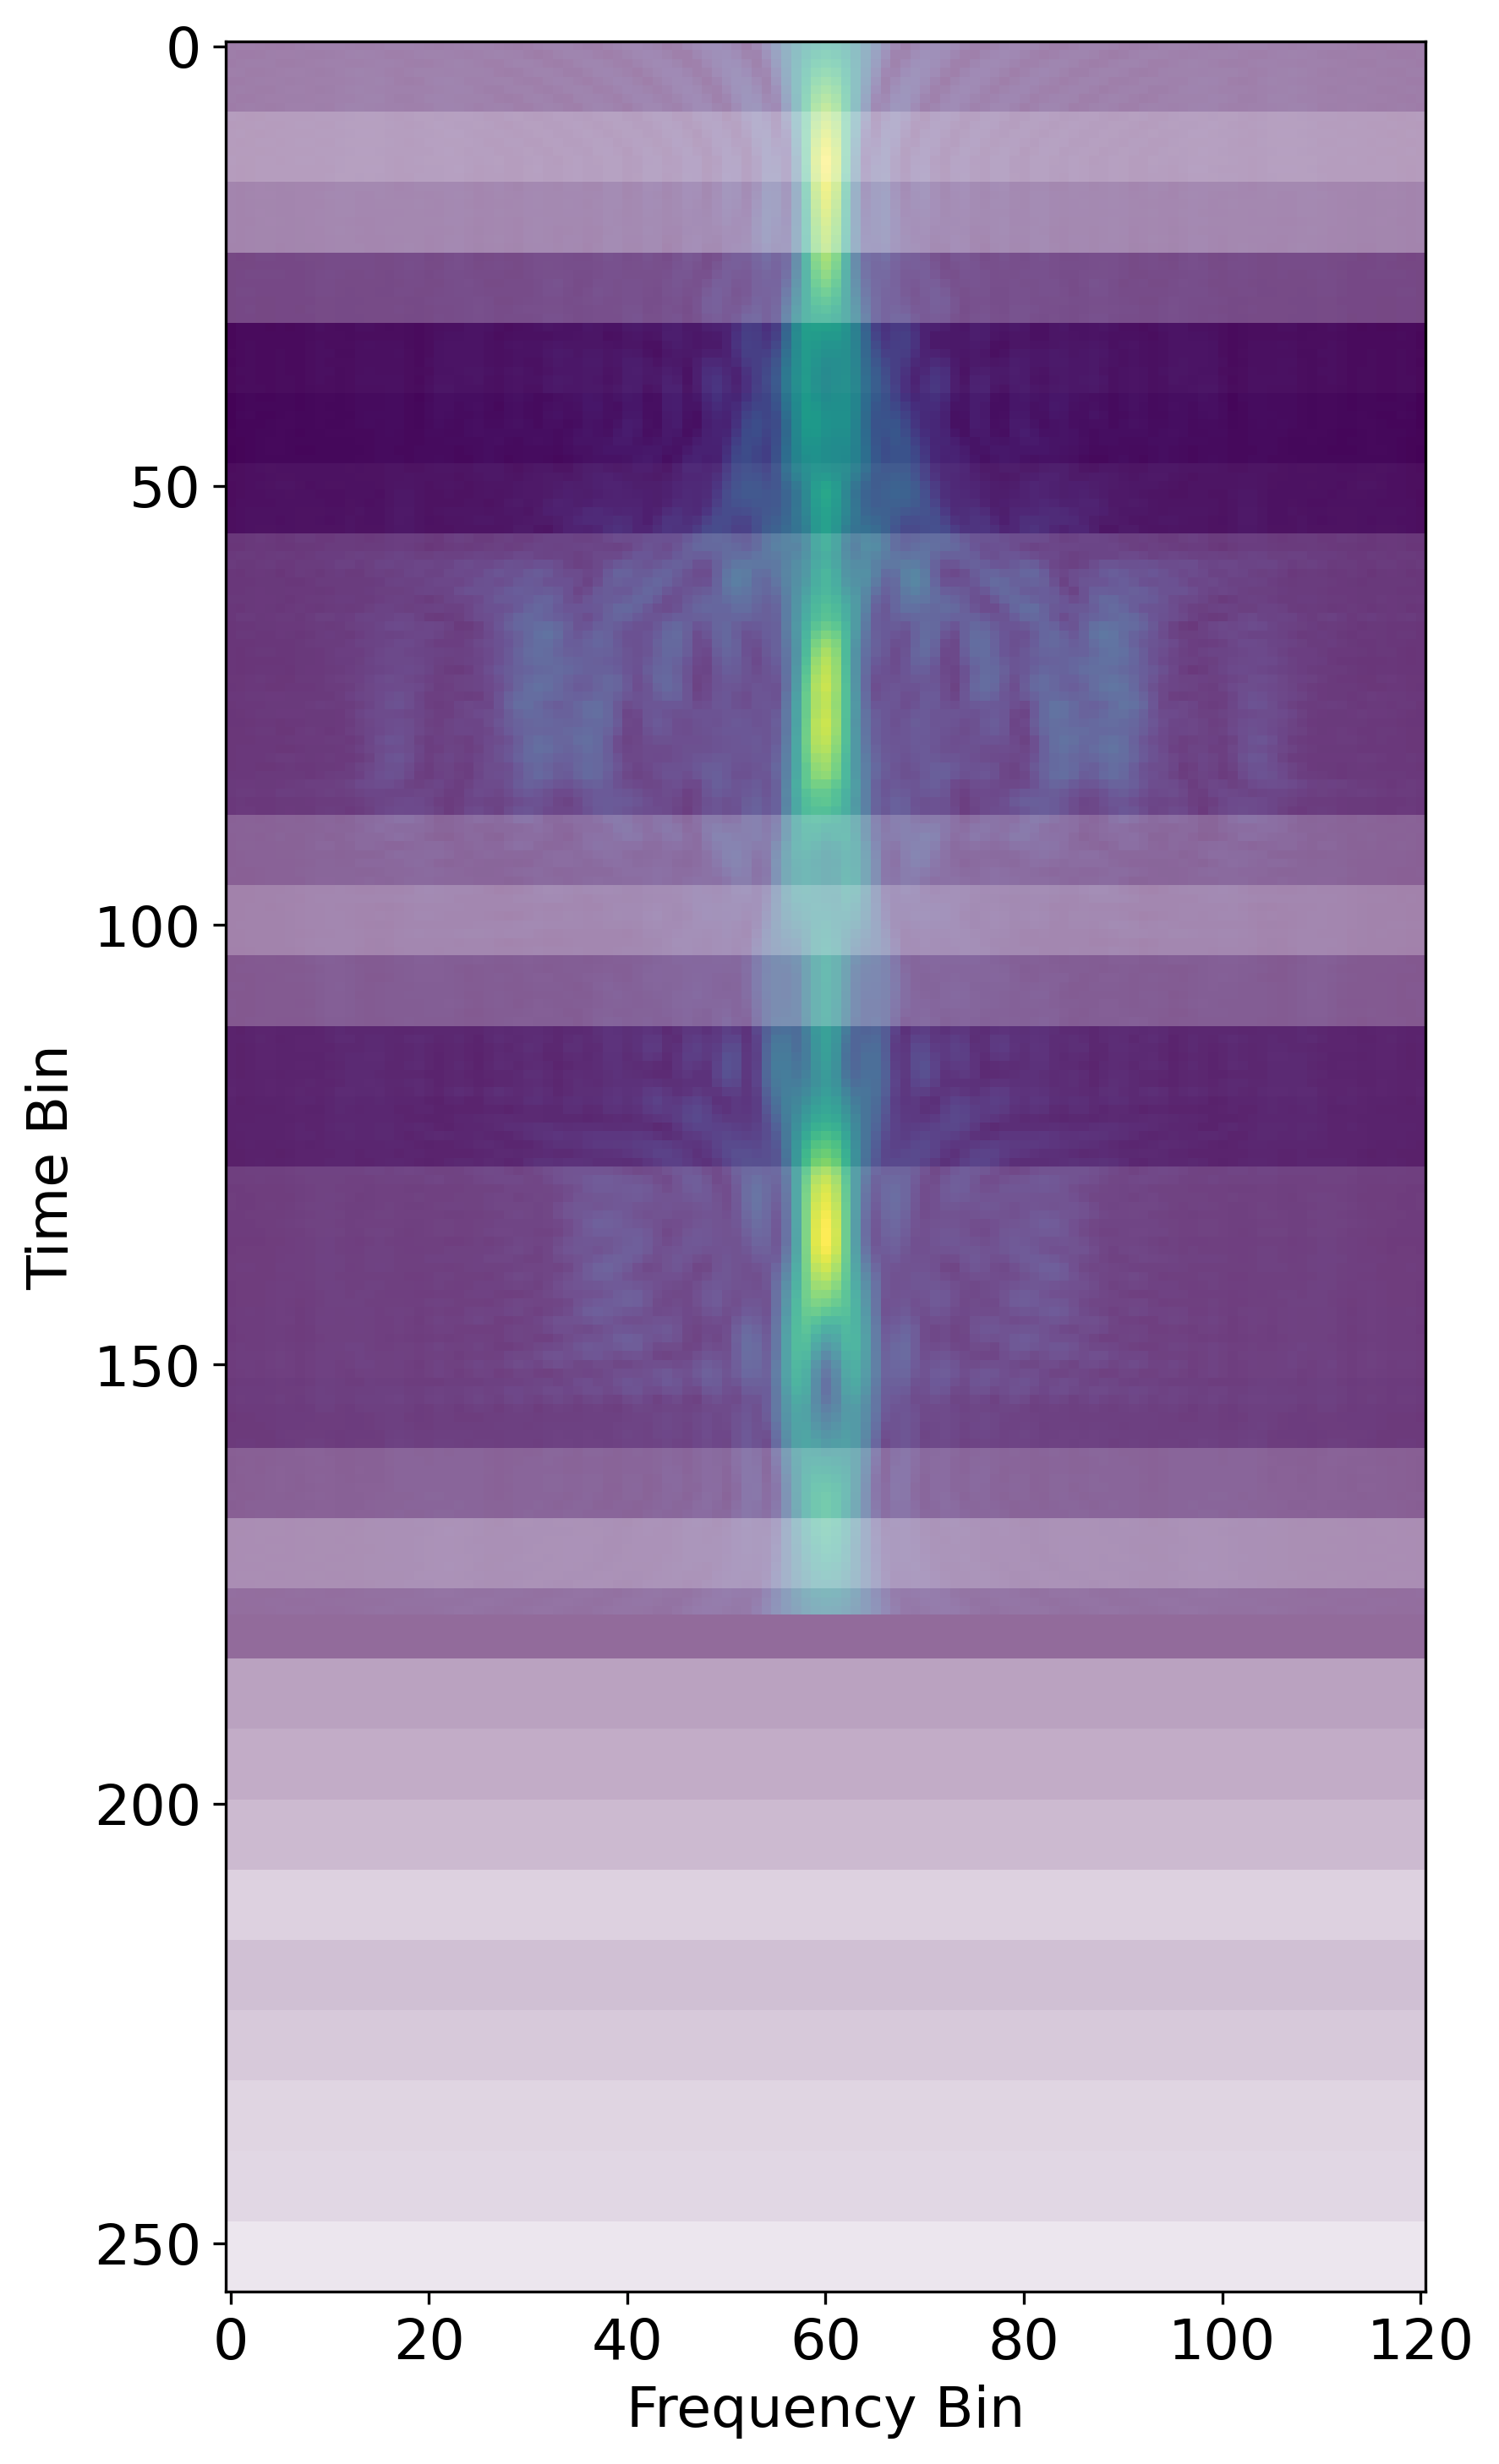

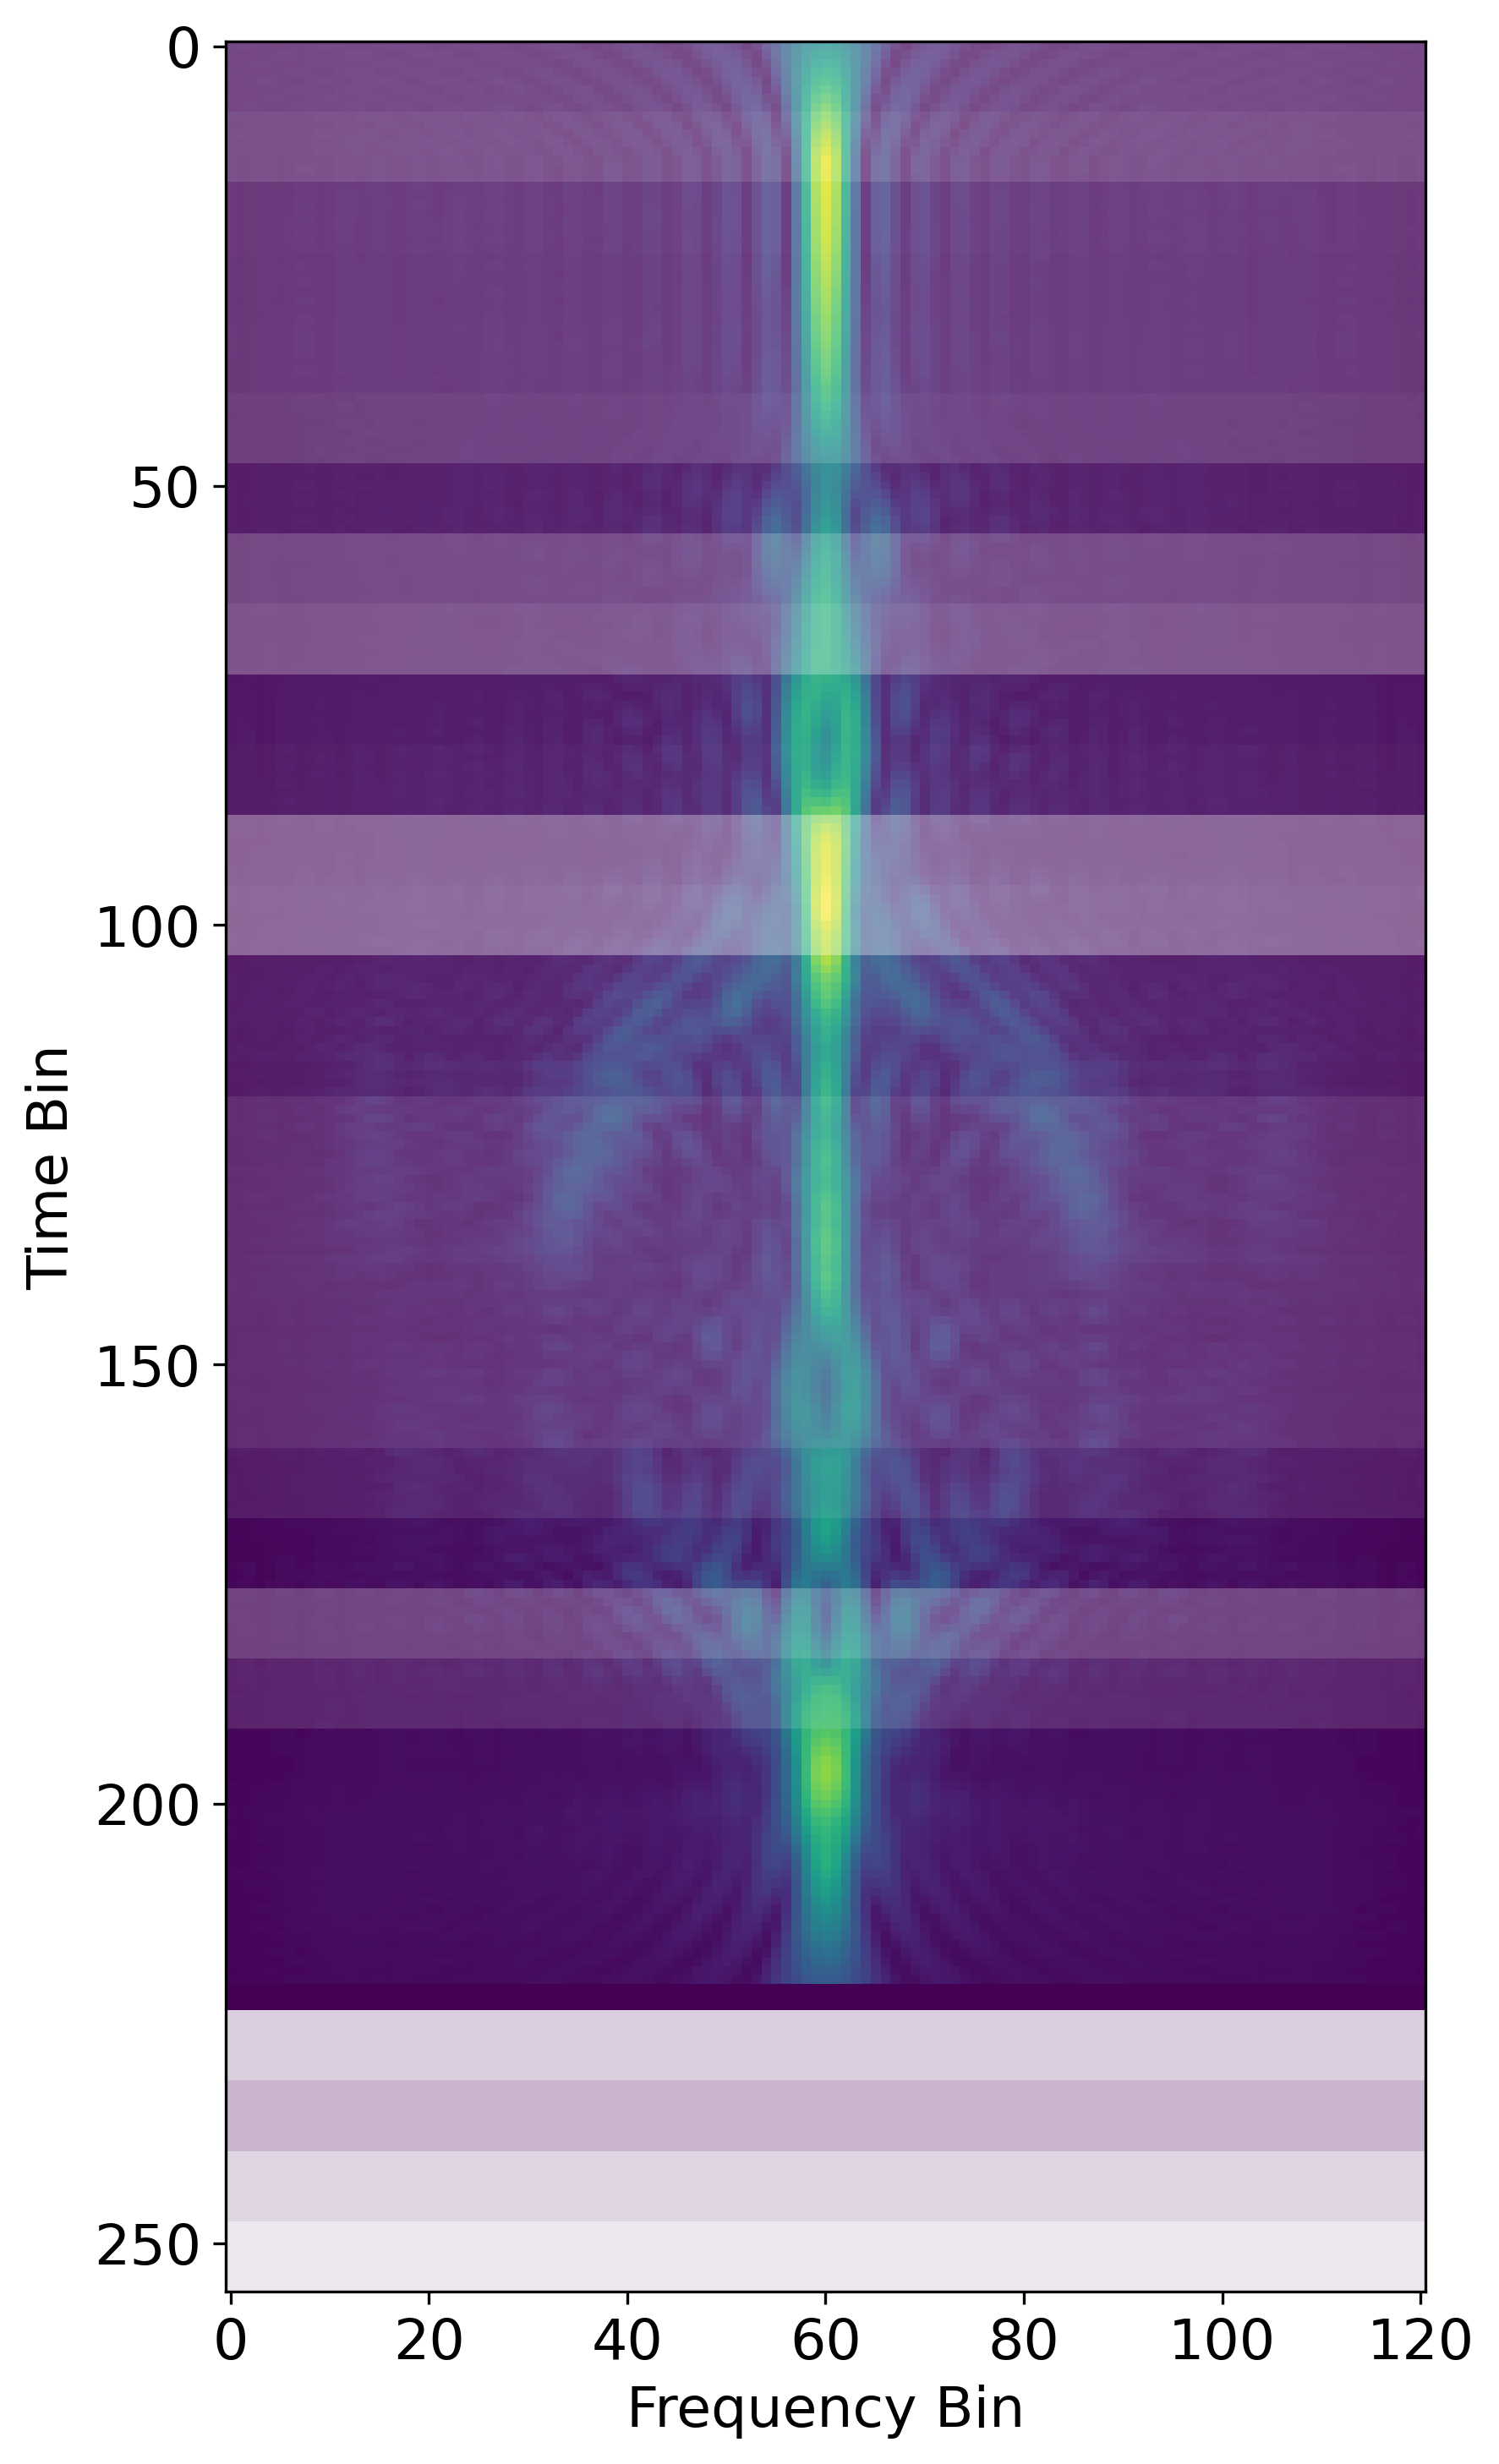

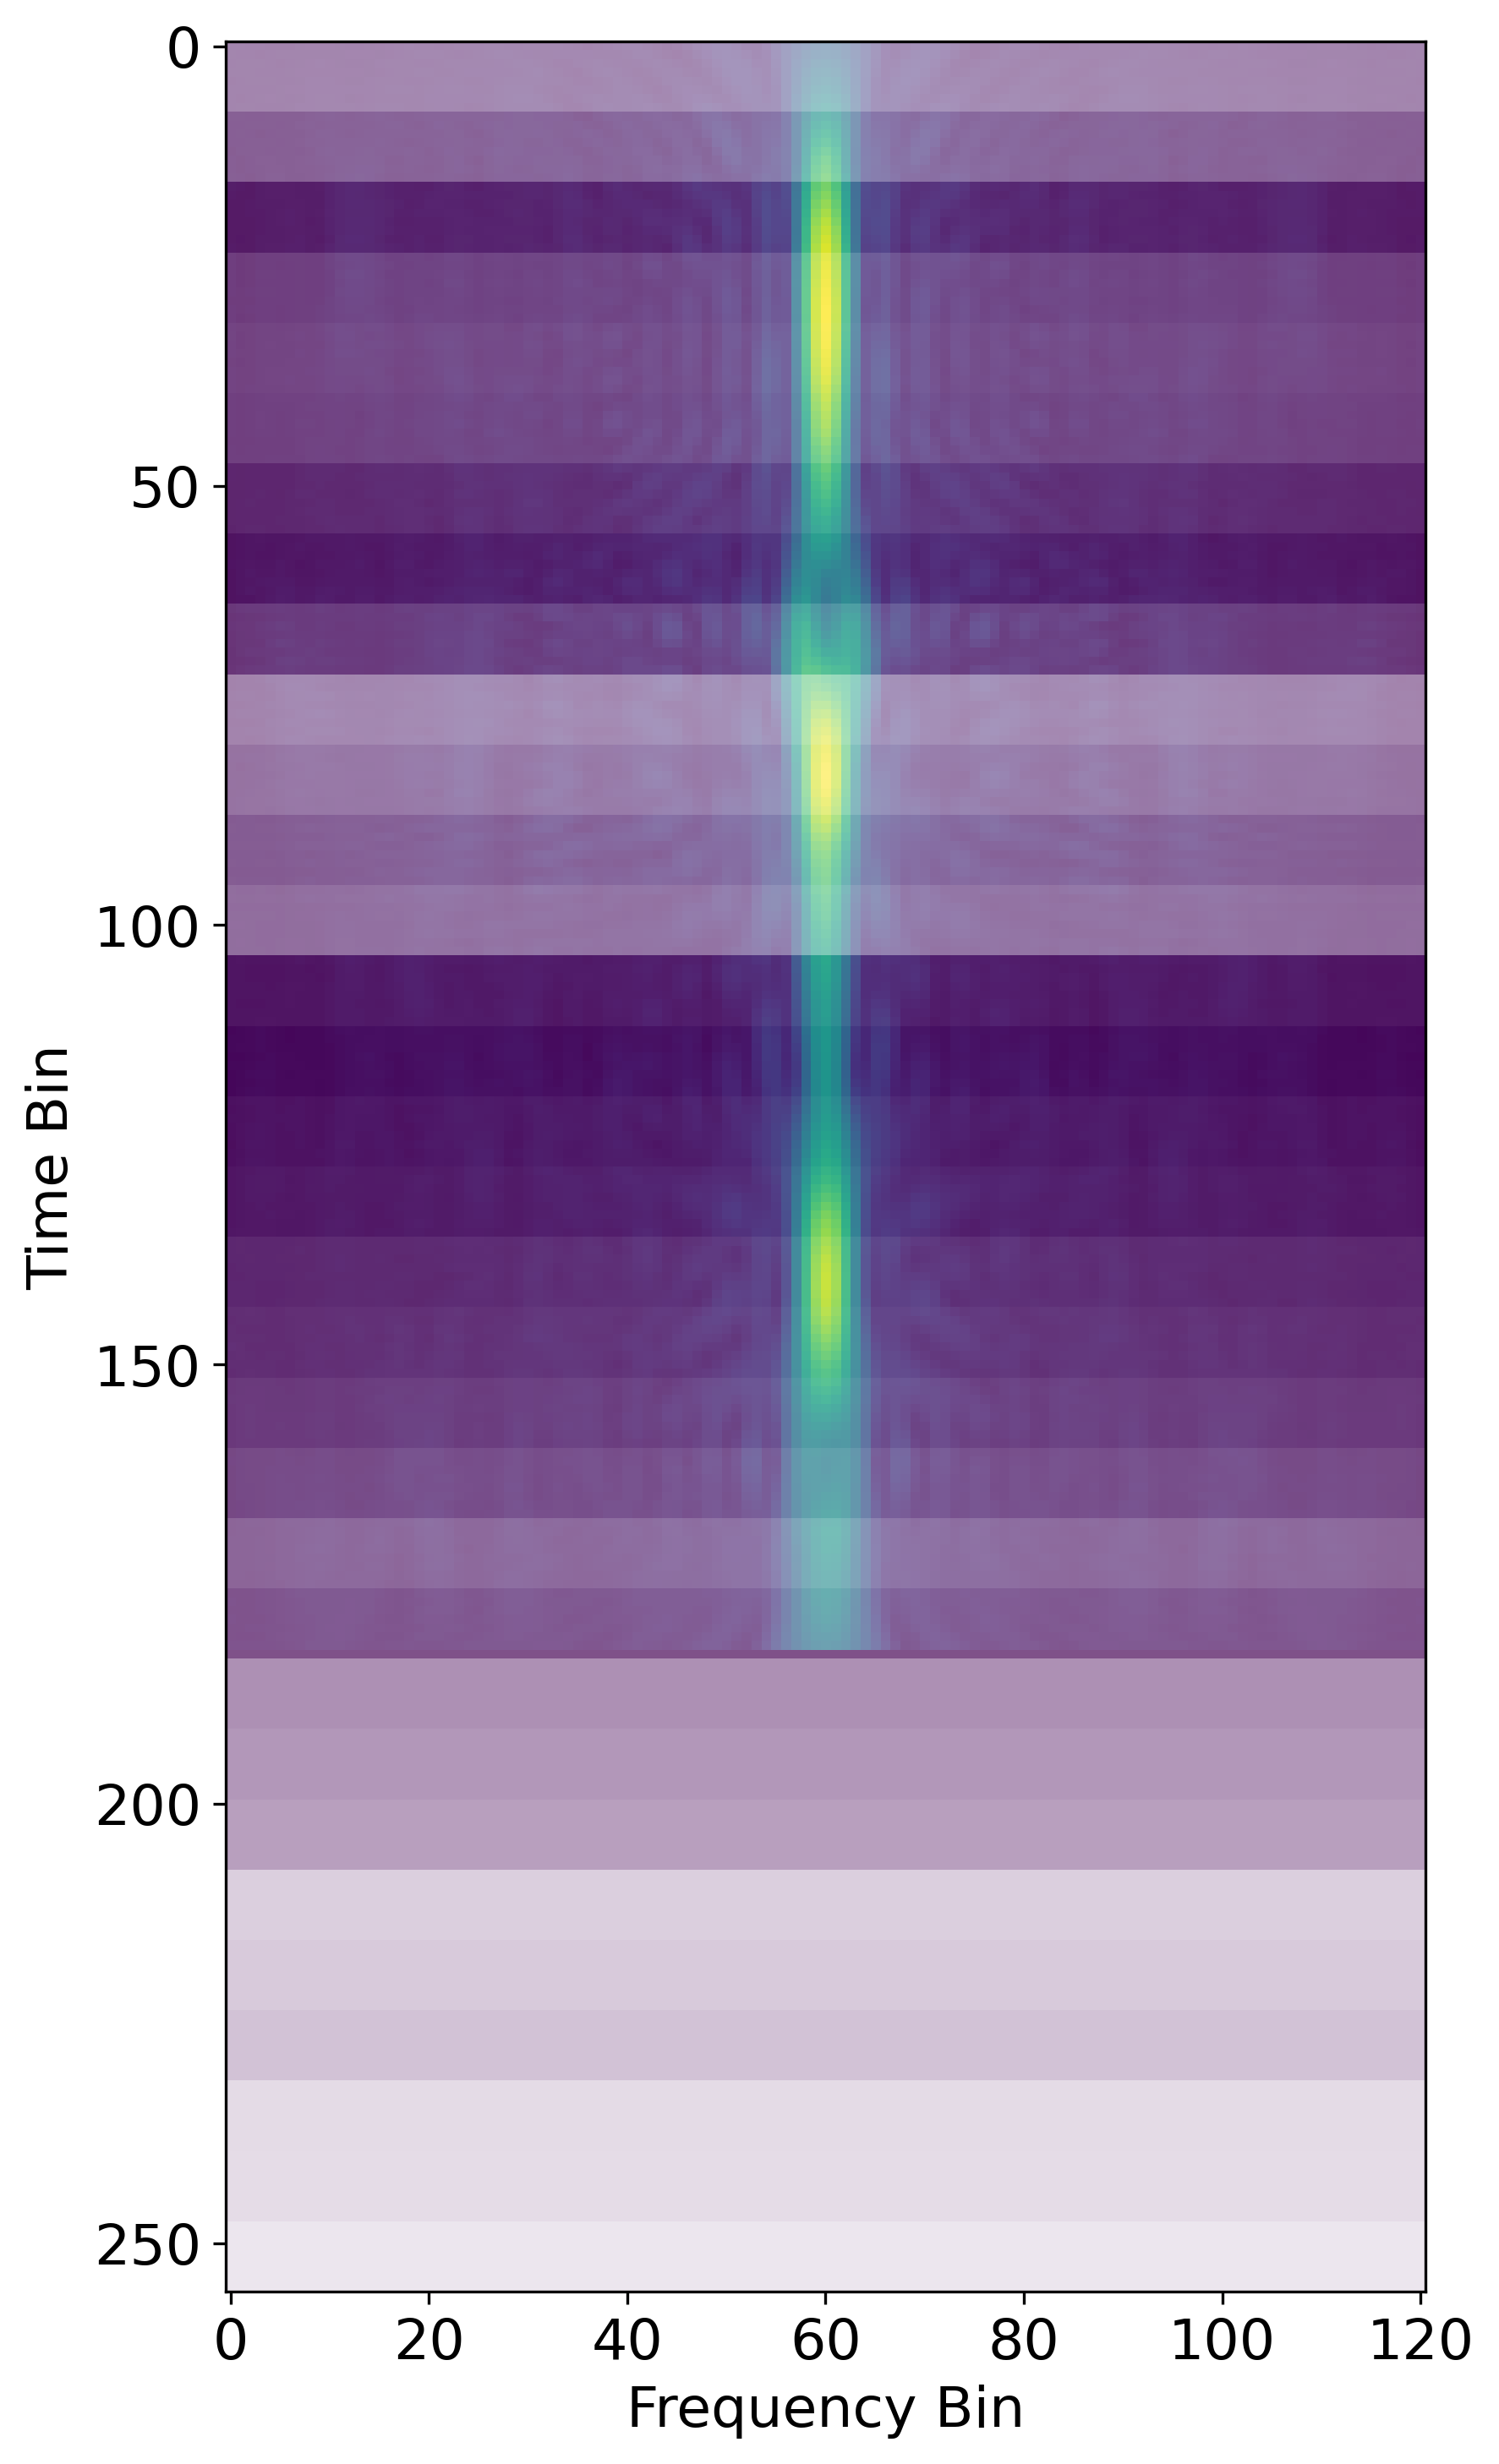

In [30]:
for count, i in enumerate(index_list_class_5):
    patch_map = attn_patch_score[i].reshape(grid_h, grid_w)
    input_map = inputs[i]
    cls_input_amp = np.mean(np.abs(input_map), axis=0)  # average over samples and links
    
    label = y[i]
    label_to_gesture_name[int(label)]

    
    H, W = cls_input_amp.shape
    h = patch_map.shape[0]
    input_heatmap = cls_input_amp
    attention_map = patch_map
    
    title = label_to_gesture_name[int(label)] + " " + str(i)

    # 2. Rescale attention map to match input shape (H, W)
    scale_factor = H // h
    attn_expanded = np.repeat(attention_map, scale_factor, axis=0)
    # If H is not perfectly divisible by h, pad or crop to match exactly H
    if attn_expanded.shape[0] < H:
        padding = np.zeros((H - attn_expanded.shape[0], 1))
        attn_expanded = np.vstack([attn_expanded, padding])
    attn_full = np.tile(attn_expanded, (1, W))

    # 3. Apply Proper Normalization
    # Normalize the heatmap values to [0, 1] for the colormap
    norm = plt.Normalize(vmin=input_heatmap.min(), vmax=input_heatmap.max())
    cmap = plt.get_cmap('viridis')
    heatmap_rgb = cmap(norm(input_heatmap)) # This returns a (H, W, 4) array

    # 4. Apply Attention to Alpha Channel
    # Normalize attention to [0.1, 1.0] so background is still faintly visible
    attn_min, attn_max = attn_full.min(), attn_full.max()
    attn_alpha = 0.1 + (attn_full - attn_min) * (0.9 / (attn_max - attn_min))

    # Set the 4th channel (Alpha) to our attention values
    heatmap_rgb[:, :, 3] = attn_alpha 

    # 5. Visualization
    # set the fontsize 
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(figsize=(6, 10), dpi=300)
    ax.imshow(heatmap_rgb, aspect='auto')
    # ax.set_title(title, fontsize=12)
    ax.set_xlabel("Frequency Bin")
    ax.set_ylabel("Time Bin")

    plt.tight_layout()
    plt.show()
    # if count > 10:
    #     break
